# Tract-Level Combined Diabetes-Obesity Burden in Greater Houston: Clustering, Vulnerability, and Low-Income Status

**Yash Nirmal Ganatra, Michael E. DeBakey High School for Health Professions, Houston, Texas, USA**


**Project Description**

This notebook reproduces a tract-level ecological analysis of combined diabetes and obesity burden in the 10-county Houston-Pasadena-The Woodlands, TX Metropolitan Statistical Area. The workflow integrates publicly available CDC PLACES, CDC/ATSDR Social Vulnerability Index, USDA Food Access Research Atlas, U.S. Census crosswalk, and census tract boundary files.

The continuous combined diabetes-obesity score is the primary analysis field. The notebook also defines high-burden overlap tracts to examine whether high diabetes and high obesity estimates appear in the same census tracts more often than expected under independence. Neighborhood indicators are evaluated with the continuous combined score, and spatial analysis is performed on the continuous combined score.


**Study Analysis Design**

The analysis asks whether estimated diabetes and obesity burden co-occur across census tracts, whether the continuous combined diabetes-obesity score is spatially clustered, and how that score relates to tract-level Social Vulnerability Index, low-income status, low-access status, and the combined Low-Income, Low-Access indicator. Because this is an ecological, cross-sectional analysis using modeled tract-level estimates, the outputs are interpreted as tract-level patterns rather than individual-level or causal evidence.

The workflow proceeds in this order:

- prepare and harmonize PLACES, SVI, USDA Food Access Research Atlas, crosswalk, and tract boundary data;
- create the continuous combined diabetes-obesity score;
- define high-burden overlap tracts and compare observed overlap with chance expectations;
- examine SVI and USDA low-income, low-access, and LILA indicators using the continuous combined score;
- evaluate global and local spatial clustering of the continuous combined score and check spatial-weight sensitivity;
- export manuscript-ready figures, tables, source data, and final analysis datasets.

Within the USDA food-access variables, low-income status and low-access status are examined as separate components. The combined LILA indicator is interpreted as a combined income-and-access measure rather than a food-access-only measure.


**Google Drive Mount**

The following cell connects Google Drive to the Colab notebook. It asks for permission to access the Google account and then mounts Drive at `/content/drive`. After this step, files stored in Google Drive can be read directly by the notebook, and output files created by the notebook can be saved back to Drive. This is needed so the analysis can use input datasets from Drive and keep generated results, figures, and tables in a permanent location instead of only inside the temporary Colab session. If Drive is already mounted, Colab may simply confirm that it is already connected.


In [1]:
# Google Drive Mount
# Input: Google account access and the Drive mount location.
# Output: Google Drive connected in Colab so files can be read and saved.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Load Main Libraries**

The following cell loads the main Python libraries needed for the full analysis. These libraries provide tools for reading and organizing data tables, working with census tract map files, running statistical analyses, defining spatial relationships, fitting multivariable models, adjusting P values for multiple comparisons, and creating figures.

This cell does not analyze any data by itself. Instead, it prepares the notebook by importing the tools that will be used in later cells.

`pandas` and `numpy` are used for working with tables, columns, numbers, and calculations. `geopandas` is used to work with geographic data, such as census tract boundaries. `scipy` is used for statistical calculations, Spearman rank correlations, nearest-neighbor calculations, and distance-based spatial checks.

The spatial analysis tools from `libpysal` and `esda` are used to define neighboring census tracts and measure spatial clustering. Queen contiguity identifies tracts that touch by an edge or a corner. Moran’s I is used to test whether similar continuous combined diabetes-obesity scores cluster together across space. Getis-Ord Gi* is used to identify local areas where higher combined scores are concentrated near other higher scores.

`statsmodels` is used to fit the multivariable linear models, calculate county-clustered standard errors, and adjust local-cluster P values using the Benjamini-Hochberg False Discovery Rate procedure. The plotting libraries from `matplotlib` are used to create maps, charts, legends, labels, and other figure elements for the manuscript.

In [2]:
# Load Main Libraries
# Input: Installed Python packages for tables, maps, statistics, spatial analysis, modeling, and plotting.
# Output: Imported tools used throughout the tract-level analysis.

# Import basic math functions and file path tools
import math
from pathlib import Path

# Import tools for working with tables and numerical data
import pandas as pd
import numpy as np

# Import tools for working with map-based tract data
import geopandas as gpd

# Import general statistical testing tools
from scipy import stats

# Import Spearman rank correlation used in the study
from scipy.stats import spearmanr

# Import tools for nearest-neighbor and distance-band spatial sensitivity checks
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components

# Import tools to define neighboring census tracts
from libpysal.weights import Queen, Rook, KNN, DistanceBand

# Import tool to calculate nearby-area values using spatial weights
from libpysal.weights import lag_spatial

# Import tool for overall spatial clustering analysis
from esda.moran import Moran

# Import tool for local cluster and low cluster analysis
from esda.getisord import G_Local

# Import tools for multivariable tract-level models
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Import tool to calculate q values when many tests are run
from statsmodels.stats.multitest import multipletests

# Import plotting tools for maps, charts, legends, and labels
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

print("Main libraries loaded.")

Main libraries loaded.


**Define Official MSA County Scope**

The study area is the 10-county Houston-Pasadena-The Woodlands, TX Metropolitan Statistical Area. The county list is defined once here and used later for tract filtering, county labels, blocked permutation tests, models with county controls, maps, and export summaries. San Jacinto County is included in the MSA county scope.

In [3]:
# Define Official MSA County Scope
# Input: Official county membership for the Houston-Pasadena-The Woodlands, TX MSA.
# Output: Standard county FIPS list and county-name map used throughout the notebook.

# Official study-area label used in printed checks and output summaries
STUDY_AREA_LABEL = "Houston-Pasadena-The Woodlands, TX Metropolitan Statistical Area"
STUDY_AREA_SHORT_LABEL = "Houston-Pasadena-The Woodlands MSA"

# County FIPS-to-name map for the official 10-county Houston-Pasadena-The Woodlands MSA
# Texas county FIPS prefixes use state code 48 plus the three-digit county code.
STUDY_AREA_COUNTY_NAME_MAP = {
    "48015": "Austin",
    "48039": "Brazoria",
    "48071": "Chambers",
    "48157": "Fort Bend",
    "48167": "Galveston",
    "48201": "Harris",
    "48291": "Liberty",
    "48339": "Montgomery",
    "48407": "San Jacinto",
    "48473": "Waller"
}

# Standard ordered list of county FIPS prefixes used for filtering
STUDY_AREA_COUNTY_PREFIXES = list(STUDY_AREA_COUNTY_NAME_MAP.keys())

# Display the county scope for confirmation
study_area_scope = pd.DataFrame({
    "county_fips": STUDY_AREA_COUNTY_PREFIXES,
    "county_name": [STUDY_AREA_COUNTY_NAME_MAP[f] for f in STUDY_AREA_COUNTY_PREFIXES]
})

print(STUDY_AREA_LABEL)
print("Counties included:", len(study_area_scope))
display(study_area_scope)

Houston-Pasadena-The Woodlands, TX Metropolitan Statistical Area
Counties included: 10


,county_fips,county_name
0,48015,Austin
1,48039,Brazoria
2,48071,Chambers
3,48157,Fort Bend
4,48167,Galveston
5,48201,Harris
6,48291,Liberty
7,48339,Montgomery
8,48407,San Jacinto
9,48473,Waller


**Load Study Datasets and Census Tract Map**

The following cell loads the project input files from the same Google Drive project folder used throughout the notebook. The PLACES input file is `places_tract_tx_filtered.csv`, the SVI input file is `svi_2022_us_tract_filtered.csv`, and the USDA Food Access file is `usda_food_access_atlas_2019_filtered.xlsx`.

The USDA workbook is loaded from its main data worksheet so the notebook reads the tract-level Food Access Research Atlas table rather than the workbook's read-me sheet. All input files are read as text at first to preserve census tract identifiers exactly.

In [4]:
# Load Study Datasets and Census Tract Map
# Input: PLACES health data, CDC Social Vulnerability Index data, USDA food access data,
# census tract crosswalk table, and 2010 Texas census tract polygons.
# Output: Data tables and tract boundary map loaded into memory for later merging and analysis.

from pathlib import Path
import pandas as pd
import geopandas as gpd

# Define the main project folder where all input files are stored.
base = "/content/drive/MyDrive/Census_Tract_Analysis_Project"
BASE_DIR = Path(base)

# Select the first matching input file from a list of accepted file names.
# The first file name in each list reflects the current analysis inputs.
def first_existing_input_file(folder, candidate_names):
    folder = Path(folder)
    checked_paths = [folder / name for name in candidate_names]
    for path in checked_paths:
        if path.exists():
            return path
    checked_text = "\n".join(str(path) for path in checked_paths)
    raise FileNotFoundError(
        "None of the expected input files were found. Checked:\n" + checked_text
    )

# PLACES health indicators, filtered to Texas tracts used for the study.
places_path = first_existing_input_file(
    BASE_DIR,
    [
        "places_tract_tx_filtered.csv"
    ]
)

# CDC/ATSDR SVI table. The filename with (1) is checked first because that is the current input file.
svi_path = first_existing_input_file(
    BASE_DIR,
    [
        "svi_2022_us_tract_filtered(1).csv",
        "svi_2022_us_tract_filtered.csv"
    ]
)

# USDA Food Access Research Atlas workbook. The filename with (1) is checked first because that is the current input file.
food_path = first_existing_input_file(
    BASE_DIR,
    [
        "usda_food_access_atlas_2019_filtered(1).xlsx",
        "usda_food_access_atlas_2019_filtered.xlsx"
    ]
)

# Census tract crosswalk and boundary files.
xwalk_path = first_existing_input_file(
    BASE_DIR,
    [
        "tab20_tract20_tract10_natl.txt"
    ]
)

tracts2010_path = first_existing_input_file(
    BASE_DIR,
    [
        "cb_2010_tx_tract_500k/gz_2010_48_140_00_500k.shp"
    ]
)

# Load input tables as text where tract identifiers must be preserved.
places = pd.read_csv(
    places_path,
    dtype=str,
    low_memory=False
)

svi = pd.read_csv(
    svi_path,
    dtype=str,
    low_memory=False
)

food = pd.read_excel(
    food_path,
    sheet_name="Food Access Research Atlas",
    dtype=str
)

xwalk = pd.read_csv(
    xwalk_path,
    sep="|",
    dtype=str,
    low_memory=False
)

tracts2010 = gpd.read_file(tracts2010_path)

# Quick row counts to confirm files loaded correctly.
print("Input files loaded")
print(f"PLACES file: {places_path}")
print(f"SVI file: {svi_path}")
print(f"USDA Food Access file: {food_path}")
print(f"Crosswalk file: {xwalk_path}")
print(f"2010 tract shapefile: {tracts2010_path}")
print()
print("PLACES rows:", len(places))
print("SVI rows:", len(svi))
print("Food rows:", len(food))
print("Crosswalk rows:", len(xwalk))
print("Tract polygons:", len(tracts2010))
print("PLACES columns:", list(places.columns))

Input files loaded
PLACES file: /content/drive/MyDrive/Census_Tract_Analysis_Project/places_tract_tx_filtered.csv
SVI file: /content/drive/MyDrive/Census_Tract_Analysis_Project/svi_2022_us_tract_filtered.csv
USDA Food Access file: /content/drive/MyDrive/Census_Tract_Analysis_Project/usda_food_access_atlas_2019_filtered.xlsx
Crosswalk file: /content/drive/MyDrive/Census_Tract_Analysis_Project/tab20_tract20_tract10_natl.txt
2010 tract shapefile: /content/drive/MyDrive/Census_Tract_Analysis_Project/cb_2010_tx_tract_500k/gz_2010_48_140_00_500k.shp

PLACES rows: 3210
SVI rows: 1612
Food rows: 1072
Crosswalk rows: 126450
Tract polygons: 5259
PLACES columns: ['year', 'stateabbr', 'statedesc', 'countyname', 'countyfips', 'locationname', 'datasource', 'category', 'measure', 'data_value_unit', 'data_value_type', 'data_value', 'data_value_footnote_symbol', 'data_value_footnote', 'low_confidence_limit', 'high_confidence_limit', 'totalpopulation', 'totalpop18plus', 'geolocation', 'locationid', 'cat

**Verify County Coverage in Loaded Input Files**

The following cell checks whether the loaded PLACES, SVI, and USDA Food Access files contain records for all 10 counties in the defined MSA study area. County FIPS prefixes are extracted from the census tract identifiers in each dataset and compared with the required county list defined near the beginning of the notebook.

The cell also reports county prefixes outside the study area for awareness because those records are excluded during later filtering. If any required MSA county is missing from an input file, the cell stops the notebook with a clear message before data preparation and analysis continue.

In [5]:
# Verify County Coverage in Loaded Input Files
# Input: Loaded PLACES, SVI, and USDA Food Access tables.
# Output: Coverage audit confirming that all 10 MSA counties are present.

# Helper function to find a column without assuming exact capitalization.
def find_column(df, candidate_names, dataset_label):
    normalized = {str(c).strip().lower(): c for c in df.columns}
    for candidate in candidate_names:
        key = candidate.strip().lower()
        if key in normalized:
            return normalized[key]
    raise KeyError(
        f"{dataset_label} is missing the expected identifier column. "
        f"Tried: {candidate_names}. Available columns: {list(df.columns)}"
    )


# Helper function to extract 11-digit census tract GEOIDs from a column.
def extract_tract_geoid(series):
    return series.astype(str).str.extract(r"(\d{11})")[0]


# Helper function to summarize missing required county prefixes and any extra prefixes in a loaded file.
# Extra prefixes are reported for awareness because later cells filter the analysis to the MSA county list.
def summarize_county_coverage(label, observed_prefixes):
    observed_prefixes = sorted(set([str(x).zfill(5) for x in observed_prefixes if pd.notna(x)]))
    observed_set = set(observed_prefixes)
    required_set = set(STUDY_AREA_COUNTY_PREFIXES)

    missing = sorted(required_set - observed_set)
    extra = sorted(observed_set - required_set)

    print(f"{label} MSA counties present:", len(observed_set & required_set), "of", len(required_set))
    if missing:
        print("Missing required MSA counties:", [(f, STUDY_AREA_COUNTY_NAME_MAP[f]) for f in missing])
    if extra:
        print(f"{label} also contains {len(extra)} county prefix(es) outside the MSA filter; these will be excluded later.")

    return {
        "dataset": label,
        "observed_prefixes": observed_prefixes,
        "missing_required": missing,
        "extra_prefixes": extra
    }


# Extract county prefixes from each input file using its tract identifier field.
# PLACES exports may use either lower-case or title-case field names.
places_id_col = find_column(
    places,
    ["locationname", "LocationName", "locationid", "LocationID"],
    "PLACES"
)
places_geoid_check = extract_tract_geoid(places[places_id_col])
places_prefixes = places_geoid_check.dropna().str[:5].unique()

svi_fips_col = find_column(
    svi,
    ["FIPS", "fips"],
    "SVI"
)
svi_prefixes = svi[svi_fips_col].astype(str).str.extract(r"(\d{11})")[0].dropna().str[:5].unique()

food_tract_col = find_column(
    food,
    ["CensusTract", "censustract"],
    "USDA Food Access"
)
food_prefixes = food[food_tract_col].astype(str).str.extract(r"(\d{11})")[0].dropna().str[:5].unique()

# Build coverage summaries.
coverage_results = [
    summarize_county_coverage("PLACES", places_prefixes),
    summarize_county_coverage("SVI", svi_prefixes),
    summarize_county_coverage("USDA Food Access", food_prefixes)
]

# Create an audit table for export or troubleshooting.
county_coverage_audit = pd.DataFrame([
    {
        "dataset": r["dataset"],
        "missing_required_counties": "; ".join([f"{f} {STUDY_AREA_COUNTY_NAME_MAP[f]}" for f in r["missing_required"]]),
        "extra_county_prefixes_in_loaded_file": "; ".join(r["extra_prefixes"]),
        "required_counties_present": len(set(r["observed_prefixes"]) & set(STUDY_AREA_COUNTY_PREFIXES)),
        "required_counties_total": len(STUDY_AREA_COUNTY_PREFIXES)
    }
    for r in coverage_results
])

# Stop if any required MSA county is missing.
coverage_errors = []
for r in coverage_results:
    if r["missing_required"]:
        coverage_errors.append(
            f"{r['dataset']} is missing: "
            + ", ".join([f"{f} {STUDY_AREA_COUNTY_NAME_MAP[f]}" for f in r["missing_required"]])
        )

if coverage_errors:
    raise ValueError(
        "One or more input files are missing required MSA counties. "
        "Use 10-county input files before continuing. "
        + " | ".join(coverage_errors)
    )

county_coverage_audit

PLACES MSA counties present: 10 of 10
SVI MSA counties present: 10 of 10
USDA Food Access MSA counties present: 10 of 10


,dataset,missing_required_counties,extra_county_prefixes_in_loaded_file,required_counties_present,required_counties_total
0,PLACES,,,10,10
1,SVI,,,10,10
2,USDA Food Access,,,10,10


**Prepare PLACES Health Indicators by Census Tract**

The following cell cleans and reshapes the CDC PLACES health indicator table so it can be used in the tract-level analysis. It reads the tract identifier using the PLACES field available in the input file, converts the health percentage field to numeric format, and keeps the diabetes and obesity measures required for the combined burden score.

If the PLACES file also contains a physical inactivity measure, the cell keeps it as an available context variable. The study does not require that measure for the main combined diabetes-obesity score. The table is then reshaped so each census tract appears once with separate columns for each used health indicator.

In [6]:
# Prepare PLACES Health Indicators by Census Tract
# Input: PLACES table containing health measures and tract identifiers.
# Output: One clean table with one row per census tract and the health indicators used downstream.

# Work on a copy so the original loaded table remains available for troubleshooting.
places_work = places.copy()

# Identify key PLACES columns without assuming exact capitalization.
places_id_col = find_column(
    places_work,
    ["locationname", "LocationName", "locationid", "LocationID"],
    "PLACES"
)
places_measure_col = find_column(
    places_work,
    ["measure", "Measure"],
    "PLACES"
)
places_value_col = find_column(
    places_work,
    ["data_value", "Data_Value"],
    "PLACES"
)

# Extract the 11-digit census tract GEOID from the available PLACES identifier field.
places_work["geoid_tract20"] = extract_tract_geoid(places_work[places_id_col])

# Convert the health value column to numeric so it can be analyzed.
places_work["data_value_numeric"] = pd.to_numeric(
    places_work[places_value_col],
    errors="coerce"
)

# Keep the required diabetes and obesity measures.
# Physical inactivity is kept only if present in the input file.
measure_to_column = {
    "Diagnosed diabetes among adults": "diabetes_pct",
    "Obesity among adults": "obesity_pct",
    "No leisure-time physical activity among adults": "inactivity_pct"
}

required_measures = [
    "Diagnosed diabetes among adults",
    "Obesity among adults"
]

available_measure_names = set(places_work[places_measure_col].dropna().astype(str))
missing_required_measures = [m for m in required_measures if m not in available_measure_names]

if missing_required_measures:
    raise KeyError(
        "The PLACES file is missing required health measures: "
        f"{missing_required_measures}. Available measures include: "
        f"{sorted(list(available_measure_names))[:20]}"
    )

measures_to_keep = [
    m for m in measure_to_column
    if m in available_measure_names
]

places_work = places_work[
    places_work[places_measure_col].isin(measures_to_keep)
].copy()

# Remove rows without a usable tract identifier or numeric health value.
places_work = places_work.dropna(
    subset=["geoid_tract20", "data_value_numeric"]
).copy()

# Reshape the table so each tract has a single row and each measure becomes a column.
places_pivot = places_work.pivot_table(
    index="geoid_tract20",
    columns=places_measure_col,
    values="data_value_numeric",
    aggfunc="first"
).reset_index()

# Rename columns to short, clear variable names.
places_pivot = places_pivot.rename(columns=measure_to_column)

# Confirm that the required fields were created.
required_places_output_cols = ["geoid_tract20", "diabetes_pct", "obesity_pct"]
missing_places_output_cols = [
    c for c in required_places_output_cols
    if c not in places_pivot.columns
]

if missing_places_output_cols:
    raise KeyError(
        "PLACES preparation did not create the required output columns: "
        f"{missing_places_output_cols}"
    )

print("PLACES measures used:", measures_to_keep)
print("PLACES tracts prepared:", len(places_pivot))

# Display the cleaned table.
places_pivot.head()

PLACES measures used: ['Diagnosed diabetes among adults', 'Obesity among adults']
PLACES tracts prepared: 1605


measure,geoid_tract20,diabetes_pct,obesity_pct
0,48015760100,17.4,41.4
1,48015760201,18.3,42.5
2,48015760202,13.1,36.5
3,48015760301,14.8,36.9
4,48015760302,15.1,39.2


**Prepare Social Vulnerability Index by Census Tract**

The following cell prepares the Social Vulnerability Index (SVI) data for tract-level analysis. It keeps only the tract FIPS code and the overall SVI percentile ranking from the CDC SVI table. The tract FIPS code is converted into a standard 11-digit census tract GEOID so it can be matched correctly with the other census tract datasets used in the study. The SVI ranking column is then converted to a numeric value, and the CDC missing-value code of `-999` is replaced with a true missing value. The final cleaned table contains one row per census tract with two fields: the standardized tract GEOID and the overall social vulnerability score. The last line displays the cleaned table to confirm that the data were prepared correctly.


In [7]:
# Prepare Social Vulnerability Index by Census Tract
# Input: CDC SVI table containing tract FIPS codes and overall vulnerability ranking.
# Output: Clean table with standardized tract GEOID and numeric vulnerability score.

# Keep only the tract identifier and overall SVI ranking column
svi_clean = svi[["FIPS", "RPL_THEMES"]].copy()

# Convert the tract FIPS code to a standard 11-digit census tract GEOID
svi_clean["geoid_tract20"] = svi_clean["FIPS"].astype(str).str.zfill(11)

# Convert the overall vulnerability ranking to numeric values
svi_clean["rpl_themes"] = pd.to_numeric(svi_clean["RPL_THEMES"], errors="coerce")

# Replace the SVI missing-value flag with a proper missing value
svi_clean["rpl_themes"] = svi_clean["rpl_themes"].replace(-999, np.nan)

# Keep only the final fields used in the study
svi_clean = svi_clean[["geoid_tract20", "rpl_themes"]]

# Display the cleaned SVI table
svi_clean.head()

,geoid_tract20,rpl_themes
0,48015760100,0.6934
1,48015760201,0.6098
2,48015760202,0.3211
3,48015760301,0.2883
4,48015760302,0.8164


**Prepare USDA Food Access Indicators by Census Tract**

The following cell prepares USDA Food Access Research Atlas fields for the food-access analysis. It keeps the combined Low-Income, Low-Access indicator, the low-income component, the low-access component using the 1-mile urban / 10-mile rural threshold, and the urban/rural flag when available. Keeping the components separate is needed because the combined LILA field includes both income and geographic access information.


In [8]:
# Prepare USDA Food Access Indicator by Census Tract
# Input: USDA Food Access Atlas table containing census tract identifiers and food access variables.
# Output: Clean table with standardized tract GEOID, LILA, low-income, low-access, and urban/rural indicators.

# Keep USDA columns needed for the food access analysis.
# The code checks for each column so the notebook gives a clear message if a required field is missing.
required_food_cols = [
    "CensusTract",
    "County",
    "LILATracts_1And10",
    "LowIncomeTracts",
    "LA1and10"
]

available_food_cols = [
    "Urban"
]

missing_required_food_cols = [c for c in required_food_cols if c not in food.columns]
if missing_required_food_cols:
    raise KeyError(
        "The USDA Food Access file is missing required columns: "
        f"{missing_required_food_cols}"
    )

available_food_cols = required_food_cols + [c for c in available_food_cols if c in food.columns]

food_clean = food[available_food_cols].copy()

# Convert CensusTract field to a standard 11-digit tract GEOID
food_clean["geoid_tract10"] = food_clean["CensusTract"].astype(str).str.zfill(11)

# Keep the original USDA county label for checks and possible exports
food_clean["usda_county"] = food_clean["County"].astype(str)

# Convert the combined Low-Income, Low-Access indicator to numeric 0/1
food_clean["lila_1and10"] = pd.to_numeric(
    food_clean["LILATracts_1And10"],
    errors="coerce"
)

# Convert the low-income-only component to numeric 0/1
food_clean["low_income_tract"] = pd.to_numeric(
    food_clean["LowIncomeTracts"],
    errors="coerce"
)

# Convert the low-access-only 1-mile urban / 10-mile rural component to numeric 0/1
food_clean["low_access_1and10"] = pd.to_numeric(
    food_clean["LA1and10"],
    errors="coerce"
)

# Convert the urban/rural flag if it is available.
# The blocked overlap permutation will use this together with county when available.
if "Urban" in food_clean.columns:
    food_clean["urban_tract"] = pd.to_numeric(food_clean["Urban"], errors="coerce")
else:
    food_clean["urban_tract"] = np.nan

# Keep only the standardized variables used downstream
food_clean = food_clean[
    [
        "geoid_tract10",
        "usda_county",
        "lila_1and10",
        "low_income_tract",
        "low_access_1and10",
        "urban_tract"
    ]
]

# Confirm that the combined LILA field equals low income plus low access where both components are present.
lila_component_check = food_clean.dropna(
    subset=["lila_1and10", "low_income_tract", "low_access_1and10"]
).copy()

lila_component_check["expected_lila_from_components"] = (
    (lila_component_check["low_income_tract"] == 1) &
    (lila_component_check["low_access_1and10"] == 1)
).astype(int)

component_mismatch_n = int(
    (
        lila_component_check["lila_1and10"].astype(int) !=
        lila_component_check["expected_lila_from_components"].astype(int)
    ).sum()
)

print("Food access fields prepared.")
print("Rows:", len(food_clean))
print("LILA/component mismatch count:", component_mismatch_n)

# Display the cleaned food access table
food_clean.head()

Food access fields prepared.
Rows: 1072
LILA/component mismatch count: 0


,geoid_tract10,usda_county,lila_1and10,low_income_tract,low_access_1and10,urban_tract
0,48015760100,Austin County,0,0,0,0
1,48015760200,Austin County,0,0,0,0
2,48015760300,Austin County,0,0,0,0
3,48015760400,Austin County,0,0,1,0
4,48015760501,Austin County,0,0,0,0


**Build Census Tract Crosswalk With Area Weights**

The following cell prepares the census tract crosswalk used to convert 2020 census tract data to 2010 census tract geography. This is needed because the study datasets may use different census tract years, so they must be placed on the same tract system before analysis.

The cell first keeps only the columns needed for the conversion: the 2020 tract ID, the 2010 tract ID, the total land area of the 2020 tract, and the land area where the 2020 tract overlaps with a 2010 tract. It then converts both tract IDs into standard 11-digit GEOID format so they can be matched correctly with other datasets.

Next, the land area fields are converted to numeric values. This allows the code to calculate an area weight for each tract match. The weight is calculated as the overlapping land area divided by the total 2020 tract land area. In simple terms, this weight shows what share of a 2020 tract falls inside a particular 2010 tract.

Finally, the cell keeps only the cleaned 2020 tract ID, the matched 2010 tract ID, and the calculated weight. The resulting table is then displayed with `head()` to confirm that the crosswalk was created correctly.


In [9]:
# Build Census Tract Crosswalk with Area Weights
# Input: Crosswalk table linking 2020 census tracts to 2010 census tracts with land area fields.
# Output: Clean table showing how each 2020 tract maps to 2010 tracts, with an area-based weight.

# Keep only the crosswalk columns needed for tract matching and area weighting
xwalk_clean = xwalk[[
    "GEOID_TRACT_20",
    "GEOID_TRACT_10",
    "AREALAND_TRACT_20",
    "AREALAND_PART"
]].copy()

# Convert both tract ID fields to standard 11-digit GEOID text format
xwalk_clean["geoid_tract20"] = xwalk_clean["GEOID_TRACT_20"].astype(str).str.zfill(11)
xwalk_clean["geoid_tract10"] = xwalk_clean["GEOID_TRACT_10"].astype(str).str.zfill(11)

# Convert land area columns to numbers so the area weights can be calculated
xwalk_clean["AREALAND_TRACT_20"] = pd.to_numeric(xwalk_clean["AREALAND_TRACT_20"], errors="coerce")
xwalk_clean["AREALAND_PART"] = pd.to_numeric(xwalk_clean["AREALAND_PART"], errors="coerce")

# Calculate the fraction of each 2020 tract that falls within each matched 2010 tract
xwalk_clean["weight"] = (
    xwalk_clean["AREALAND_PART"] /
    xwalk_clean["AREALAND_TRACT_20"]
)

# Keep only the cleaned tract IDs and the weight needed for later dataset conversion
xwalk_clean = xwalk_clean[[
    "geoid_tract20",
    "geoid_tract10",
    "weight"
]]

# Display the cleaned crosswalk table
xwalk_clean.head()

,geoid_tract20,geoid_tract10,weight
0,01001020100,01001020100,0.999506
1,01001020100,01001020200,0.000494
2,01001020200,01001020200,1.000000
3,01001020300,01001020300,1.000000
4,01001020400,01001020400,1.000000


**Convert PLACES Health Data from 2020 Tracts to 2010 Tracts**

The following cell converts the PLACES health indicators from 2020 census tract geography to 2010 census tract geography so they can be matched with the USDA Food Access Atlas data and the 2010 tract map. It first joins the PLACES data to the tract crosswalk using the 2020 tract ID. Rows without a valid area weight are removed because they cannot be reliably assigned to a 2010 tract.

The cell then multiplies each available PLACES health percentage by the crosswalk weight and sums the weighted values within each 2010 tract. The final values are area-weighted averages for diabetes and obesity, with physical inactivity included only if the input file contains it.

In [10]:
# Convert PLACES Health Data from 2020 Tracts to 2010 Tracts
# Input: PLACES health indicators by 2020 tract and tract crosswalk with area weights.
# Output: One clean table with available health indicators recalculated for 2010 census tracts.

# Attach the tract crosswalk so each 2020 tract can be mapped to a 2010 tract.
places_xwalk = places_pivot.merge(
    xwalk_clean,
    on="geoid_tract20",
    how="left"
)

# Keep only rows with valid area weights.
places_xwalk = places_xwalk.dropna(subset=["weight"]).copy()

# Identify the PLACES health columns available for area-weighted conversion.
health_cols = [
    c for c in ["diabetes_pct", "obesity_pct", "inactivity_pct"]
    if c in places_xwalk.columns
]

required_health_cols = ["diabetes_pct", "obesity_pct"]
missing_required_health_cols = [c for c in required_health_cols if c not in health_cols]

if missing_required_health_cols:
    raise KeyError(
        "The area-weighted PLACES conversion requires diabetes and obesity columns. "
        f"Missing: {missing_required_health_cols}"
    )

# Multiply each health percentage by the tract weight.
for col in health_cols:
    places_xwalk[f"{col}_num"] = places_xwalk[col] * places_xwalk["weight"]

# Add weighted health values and total weight within each 2010 tract.
agg_dict = {
    f"{col}_num": (f"{col}_num", "sum")
    for col in health_cols
}
agg_dict["weight_sum"] = ("weight", "sum")

places2010 = (
    places_xwalk
    .groupby("geoid_tract10")
    .agg(**agg_dict)
    .reset_index()
)

# Divide weighted sums by the total assigned weight to calculate area-weighted averages.
for col in health_cols:
    places2010[col] = places2010[f"{col}_num"] / places2010["weight_sum"]

# Keep only the final 2010 tract ID and health columns.
places2010 = places2010[
    ["geoid_tract10"] + health_cols
].copy()

print("PLACES health indicators converted to 2010 tracts:", health_cols)
places2010.head()

PLACES health indicators converted to 2010 tracts: ['diabetes_pct', 'obesity_pct']


,geoid_tract10,diabetes_pct,obesity_pct
0,48015760100,17.40,41.40
1,48015760200,15.70,39.50
2,48015760300,14.95,38.05
3,48015760400,12.70,32.70
4,48015760501,12.90,33.60


**Convert Social Vulnerability Index from 2020 Tracts to 2010 Tracts**

The following cell converts the Social Vulnerability Index (SVI) data from 2020 census tracts to 2010 census tracts so it can be matched with the other study datasets. It first joins the cleaned 2020 SVI table with the tract crosswalk. The crosswalk shows how each 2020 tract overlaps with one or more 2010 tracts and gives an area weight for each overlap.

The cell removes rows that do not have both an SVI value and an area weight because those rows cannot be used in the weighted calculation. It then multiplies each 2020 tract SVI score by its area weight to calculate that tract’s weighted contribution to the matching 2010 tract.

Next, the cell groups the data by 2010 tract. For each 2010 tract, it sums the weighted SVI contributions and also sums the total weights. The final recalculated SVI score is created by dividing the weighted sum by the total weight. This gives one area-weighted SVI percentile score for each 2010 census tract.

The final dataset keeps only the 2010 tract identifier and the recalculated SVI score, then displays the first few rows to confirm that the conversion worked.


In [11]:
# Convert Social Vulnerability Index from 2020 Tracts to 2010 Tracts
# Input: Clean SVI scores by 2020 tract and tract crosswalk with area weights.
# Output: SVI scores recalculated for 2010 census tracts using weighted averages.

# Join each 2020 tract SVI score to the crosswalk that links it to 2010 tracts
svi_xwalk = svi_clean.merge(
    xwalk_clean,
    on="geoid_tract20",
    how="left"
)

# Keep only rows with both an SVI score and a valid area weight
svi_xwalk = svi_xwalk.dropna(subset=["rpl_themes", "weight"]).copy()

# Multiply each 2020 tract SVI score by its area weight
svi_xwalk["svi_num"] = svi_xwalk["rpl_themes"] * svi_xwalk["weight"]

# Sum the weighted SVI values and total weights for each 2010 tract
svi2010 = (
    svi_xwalk
    .groupby("geoid_tract10")
    .agg(
        svi_num=("svi_num", "sum"),
        svi_den=("weight", "sum")
    )
    .reset_index()
)

# Divide weighted SVI total by total weight to get the 2010 tract SVI score
svi2010["rpl_themes"] = svi2010["svi_num"] / svi2010["svi_den"]

# Keep only the final 2010 tract identifier and recalculated SVI score
svi2010 = svi2010[["geoid_tract10", "rpl_themes"]]

# Display the converted SVI table
svi2010.head()

,geoid_tract10,rpl_themes
0,48015760100,0.69340
1,48015760200,0.46545
2,48015760300,0.55235
3,48015760400,0.41960
4,48015760501,0.34640


**Combine Health, Vulnerability, and Food Access Data**

The following cell creates the non-spatial analysis table by combining the tract-level health data, Social Vulnerability Index data, and food access data using the 2010 census tract ID. Because the merges use an inner join, only census tracts that are present in all three datasets are kept.

The tract boundary map is attached in a later cell after the official 10-county MSA tract layer is prepared. This keeps the data merge step separate from the map preparation step and makes the notebook flow easier to check.


In [12]:
# Combine Health, Vulnerability, and Food Access Data
# Input: Health indicators, Social Vulnerability Index, and food access indicators harmonized to 2010 tracts.
# Output: Non-spatial analysis table with one row per matched tract.

# Merge health indicators with social vulnerability and food access tables
analysis = (
    places2010
    .merge(svi2010, on="geoid_tract10", how="inner")
    .merge(food_clean, on="geoid_tract10", how="inner")
)

# Add county fields for checks before the map geometry is attached
analysis["county_fips"] = analysis["geoid_tract10"].astype(str).str[:5]
analysis["county_name"] = analysis["county_fips"].map(STUDY_AREA_COUNTY_NAME_MAP)

# Keep only the official 10 MSA counties in the analysis table
analysis = analysis[analysis["county_fips"].isin(STUDY_AREA_COUNTY_PREFIXES)].copy()

# Stop if any analysis row has an unmapped county name
if analysis["county_name"].isna().any():
    missing_codes = sorted(analysis.loc[analysis["county_name"].isna(), "county_fips"].unique())
    raise ValueError(f"Analysis table contains unmapped county FIPS codes: {missing_codes}")


print("Analysis table tracts:", len(analysis))
print("Analysis table counties:", analysis["county_name"].nunique())
display(analysis["county_name"].value_counts().sort_index().rename_axis("county_name").reset_index(name="tracts"))

# Display the combined analysis table
analysis.head()

Analysis table tracts: 1069
Analysis table counties: 10


,county_name,tracts
0,Austin,6
1,Brazoria,50
2,Chambers,5
3,Fort Bend,76
4,Galveston,66
5,Harris,784
6,Liberty,14
7,Montgomery,59
8,San Jacinto,4
9,Waller,5


,geoid_tract10,diabetes_pct,obesity_pct,rpl_themes,usda_county,lila_1and10,low_income_tract,low_access_1and10,urban_tract,county_fips,county_name
0,48015760100,17.40,41.40,0.69340,Austin County,0,0,0,0,48015,Austin
1,48015760200,15.70,39.50,0.46545,Austin County,0,0,0,0,48015,Austin
2,48015760300,14.95,38.05,0.55235,Austin County,0,0,0,0,48015,Austin
3,48015760400,12.70,32.70,0.41960,Austin County,0,0,1,0,48015,Austin
4,48015760501,12.90,33.60,0.34640,Austin County,0,0,0,0,48015,Austin


**Build Standard Census Tract Identifier**

The following cell creates a standard 11-digit census tract identifier for each 2010 census tract polygon. This identifier is needed so the tract shapefile can be correctly matched with the analysis tables later in the notebook.

The code combines three separate shapefile fields: the 2-digit state code, the 3-digit county code, and the 6-digit tract code. Each part is first converted to text and padded with leading zeros when needed so that all GEOIDs follow the same fixed-length format. This is important because census codes such as state, county, or tract numbers may lose leading zeros if they are stored as numbers instead of text.

The new combined field is named `geoid_tract10`. It represents the full 2010 census tract GEOID and will be used as the main geographic matching key in later merge, mapping, and analysis steps. The final line displays the original state, county, and tract code fields along with the newly created GEOID to confirm that the identifier was built correctly.


In [13]:
# Build Standard Census Tract Identifier
# Input: 2010 tract shapefile fields for state, county, and tract codes.
# Output: Single 11-digit GEOID used to match tract polygons with analysis tables.

# Combine state, county, and tract codes into one standard 11-digit census tract GEOID
tracts2010["geoid_tract10"] = (
    tracts2010["STATE"].astype(str).str.zfill(2) +
    tracts2010["COUNTY"].astype(str).str.zfill(3) +
    tracts2010["TRACT"].astype(str).str.zfill(6)
)

# Display the original code fields and the combined GEOID
tracts2010[["STATE", "COUNTY", "TRACT", "geoid_tract10"]].head()

,STATE,COUNTY,TRACT,geoid_tract10
0,48,029,110100,48029110100
1,48,029,110300,48029110300
2,48,029,110500,48029110500
3,48,029,120300,48029120300
4,48,029,120702,48029120702


**Filter 2010 Census Tracts to the Official MSA Counties**

The following cell limits the full 2010 census tract boundary file to the 10 counties in the official Houston-Pasadena-The Woodlands MSA. The county list is pulled from the standard county-scope variables defined near the top of the notebook so that the same county scope is used consistently throughout the analysis.

The output is named `tracts_study`, a map layer containing only census tracts in the official MSA counties.

In [14]:
# Filter 2010 Census Tracts to the Official MSA Counties
# Input: 2010 census tract polygons with standardized tract GEOID.
# Output: One tract polygon layer limited to the 10 official Houston-Pasadena-The Woodlands MSA counties.

# Use the official MSA county FIPS codes defined near the top of the notebook
county_prefixes = STUDY_AREA_COUNTY_PREFIXES

# Keep only census tracts whose GEOID starts with one of the selected county FIPS codes
tracts_study = tracts2010[
    tracts2010["geoid_tract10"].astype(str).str[:5].isin(county_prefixes)
].copy()

# Add readable county names for checks and mapping
tracts_study["county_fips"] = tracts_study["geoid_tract10"].astype(str).str[:5]
tracts_study["county_name"] = tracts_study["county_fips"].map(STUDY_AREA_COUNTY_NAME_MAP)

# Stop if any tract has an unmapped county code
if tracts_study["county_name"].isna().any():
    missing_codes = sorted(tracts_study.loc[tracts_study["county_name"].isna(), "county_fips"].unique())
    raise ValueError(f"County name mapping is missing these county FIPS codes: {missing_codes}")

# Print tract counts by county for a transparent study-area audit
print("Official MSA tract polygons:", len(tracts_study))
display(tracts_study["county_name"].value_counts().sort_index().rename_axis("county_name").reset_index(name="tract_polygons"))

Official MSA tract polygons: 1075


,county_name,tract_polygons
0,Austin,6
1,Brazoria,51
2,Chambers,6
3,Fort Bend,76
4,Galveston,67
5,Harris,786
6,Liberty,14
7,Montgomery,59
8,San Jacinto,4
9,Waller,6


**Attach Analysis Variables to the Census Tract Map**

The following cell creates the final map-ready dataset by attaching the analysis variables to the official 10-county MSA census tract boundaries. The merge uses the 2010 tract GEOID as the matching key.

The output is `gdf`, the main geospatial dataset used for the continuous combined score, multivariable models, overlap enrichment, and spatial analysis. The cell prints final tract counts overall and by county so the study-area scope can be checked before any statistics or maps are produced.


In [15]:
# Attach Analysis Variables to Census Tract Map
# Input: Official MSA tract polygons and the combined analysis table.
# Output: Geospatial dataset where each tract includes geometry and all study variables.

# Rebuild the official MSA tract layer if it has not already been created
if "tracts_study" not in globals():

    # Create the 2010 census tract GEOID if it is not already present
    if "geoid_tract10" not in tracts2010.columns:
        tracts2010["geoid_tract10"] = (
            tracts2010["STATE"].astype(str).str.zfill(2) +
            tracts2010["COUNTY"].astype(str).str.zfill(3) +
            tracts2010["TRACT"].astype(str).str.zfill(6)
        )

    # Use the official MSA county FIPS codes defined near the top of the notebook
    county_prefixes = STUDY_AREA_COUNTY_PREFIXES

    # Keep only census tracts located in the official MSA counties
    tracts_study = tracts2010[
        tracts2010["geoid_tract10"].astype(str).str[:5].isin(county_prefixes)
    ].copy()

# Attach the analysis variables to the matching tract polygons using the 2010 tract GEOID
gdf = tracts_study.merge(
    analysis,
    on="geoid_tract10",
    how="inner",
    suffixes=("_shape", "")
)

# Ensure county fields are clean and consistently named
gdf["county_fips"] = gdf["geoid_tract10"].astype(str).str[:5]
gdf["county_name"] = gdf["county_fips"].map(STUDY_AREA_COUNTY_NAME_MAP)

# Stop if any mapped tract has an unmapped county code
if gdf["county_name"].isna().any():
    missing_codes = sorted(gdf.loc[gdf["county_name"].isna(), "county_fips"].unique())
    raise ValueError(f"Mapped analysis dataset contains unmapped county FIPS codes: {missing_codes}")

# Confirm the number of mapped tracts and counties included in the final dataset
print("Mapped analysis tracts:", len(gdf))
print("Mapped analysis counties:", gdf["county_name"].nunique())
display(gdf["county_name"].value_counts().sort_index().rename_axis("county_name").reset_index(name="mapped_tracts"))

# Display the final map-ready dataset with tract geometry and study variables
gdf.head()

Mapped analysis tracts: 1069
Mapped analysis counties: 10


,county_name,mapped_tracts
0,Austin,6
1,Brazoria,50
2,Chambers,5
3,Fort Bend,76
4,Galveston,66
5,Harris,784
6,Liberty,14
7,Montgomery,59
8,San Jacinto,4
9,Waller,5


,GEO_ID,STATE,COUNTY,TRACT,NAME,LSAD,CENSUSAREA,geometry,geoid_tract10,county_fips_shape,...,diabetes_pct,obesity_pct,rpl_themes,usda_county,lila_1and10,low_income_tract,low_access_1and10,urban_tract,county_fips,county_name
0,1400000US48039664300,48,039,664300,6643,Tract,3.145,"POLYGON ((-95.35848 28.9537, -95.35985 28.9540...",48039664300,48039,...,15.700000,42.200000,0.9712,Brazoria County,1,1,1,1,48039,Brazoria
1,1400000US48039660100,48,039,660100,6601,Tract,1.623,"POLYGON ((-95.23941 29.54778, -95.24355 29.547...",48039660100,48039,...,11.500000,33.100000,0.1069,Brazoria County,0,0,0,1,48039,Brazoria
2,1400000US48039660701,48,039,660701,6607.01,Tract,3.998,"POLYGON ((-95.3309 29.55202, -95.33075 29.5442...",48039660701,48039,...,10.533333,32.466667,0.2470,Brazoria County,0,0,1,1,48039,Brazoria
3,1400000US48039661100,48,039,661100,6611,Tract,5.442,"POLYGON ((-95.24444 29.43443, -95.24529 29.454...",48039661100,48039,...,14.100000,40.300000,0.6859,Brazoria County,0,1,0,0,48039,Brazoria
4,1400000US48039661700,48,039,661700,6617,Tract,169.636,"POLYGON ((-95.05738 29.20065, -95.06522 29.196...",48039661700,48039,...,12.500000,36.300000,0.5179,Brazoria County,0,0,0,0,48039,Brazoria


**Create Continuous Combined Diabetes-Obesity Burden Score**

The following cell creates the continuous combined diabetes-obesity score used as the primary burden measure in the analysis. Diabetes and obesity prevalence estimates are converted to numeric values and standardized separately using z-scores. The two z-scores are then averaged with equal weighting.

The average z-score is linearly rescaled to a 0-to-1 range, with higher values representing higher modeled combined diabetes-obesity burden. The rescaling preserves the relative ordering of the census tracts.

The cell also creates diabetes, obesity, and combined-score rank percentiles for descriptive analysis and figure generation. Verification checks confirm that the 0-to-1 rescaling preserves tract rankings and does not change rank-based relationships with other variables.

In [16]:
# Create Continuous Combined Diabetes-Obesity Burden Score
# Input: Diabetes and obesity prevalence estimates for each census tract.
# Output: Continuous combined diabetes-obesity score used as the primary burden measure.
#
# The study uses the continuous combined score as the primary analysis field.
# The high-burden overlap classification is created later for enrichment and mapping checks.

# Import packages needed for numeric calculations, table handling, and correlation testing
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr

# ---------------------------------------------------------------------
# Clean numeric input variables
# ---------------------------------------------------------------------

# Convert diabetes and obesity prevalence columns to numeric values
diabetes_values = pd.to_numeric(gdf["diabetes_pct"], errors="coerce")
obesity_values = pd.to_numeric(gdf["obesity_pct"], errors="coerce")

# Stop the analysis if any diabetes or obesity values are missing after conversion
if diabetes_values.isna().any() or obesity_values.isna().any():
    raise ValueError(
        "Diabetes or obesity values contain NaN values. "
        "Recheck prior filtering before creating combined burden scores."
    )

# ---------------------------------------------------------------------
# Equal-weight z-score components
# ---------------------------------------------------------------------

# Standardize diabetes prevalence so values are measured relative to the study-area average
gdf["z_diabetes"] = stats.zscore(diabetes_values, nan_policy="omit")

# Standardize obesity prevalence so values are measured relative to the study-area average
gdf["z_obesity"] = stats.zscore(obesity_values, nan_policy="omit")

# Average the standardized diabetes and obesity values to create the combined score
gdf["composite_z_original"] = (gdf["z_diabetes"] + gdf["z_obesity"]) / 2

# ---------------------------------------------------------------------
# Main continuous combined score
#
# This is the equal-weight z-score composite rescaled to 0-1.
# A larger value means higher combined estimated diabetes-obesity burden.
# The rescaling preserves all tract rankings and does not change correlations based on ranks.
# ---------------------------------------------------------------------

# Find the lowest and highest values of the unscaled combined score
composite_min = gdf["composite_z_original"].min()
composite_max = gdf["composite_z_original"].max()

# Calculate the spread between the lowest and highest unscaled scores
composite_range = composite_max - composite_min

# Stop the analysis if all tracts have the same combined score
if composite_range == 0:
    raise ValueError("Combined score has zero range. Cannot rescale to 0-1.")

# Rescale the unscaled combined score to a 0-to-1 range
gdf["composite"] = (
    (gdf["composite_z_original"] - composite_min) / composite_range
)

# Create a 0-to-100 version of the score for optional export and verification checks
gdf["composite_0_100"] = 100 * gdf["composite"]

# ---------------------------------------------------------------------
# Rank variables used to describe the diabetes-obesity relationship
# ---------------------------------------------------------------------

# Rank each condition as a percentile within the study area
gdf["diabetes_rank_percentile"] = diabetes_values.rank(method="average", pct=True) * 100
gdf["obesity_rank_percentile"] = obesity_values.rank(method="average", pct=True) * 100
gdf["composite_rank_percentile"] = gdf["composite"].rank(method="average", pct=True) * 100

# Build a table for the diabetes-obesity rank relationship plot and export workbook
diabetes_obesity_rank_data_df = gdf[
    [
        "diabetes_pct",
        "obesity_pct",
        "diabetes_rank_percentile",
        "obesity_rank_percentile",
        "composite_z_original",
        "composite",
        "composite_0_100",
        "composite_rank_percentile"
    ]
].copy()

# ---------------------------------------------------------------------
# Verification that rescaling did not alter ordering or interpretation
# ---------------------------------------------------------------------

# Rank tracts using the unscaled combined score
rank_original = gdf["composite_z_original"].rank(method="average")

# Rank tracts using the rescaled combined score
rank_rescaled = gdf["composite"].rank(method="average")

# Count how many tract ranks changed after rescaling
rank_changed_n = int((rank_original != rank_rescaled).sum())

# Confirm that the unscaled and rescaled combined scores are perfectly aligned
pearson_between_scores = gdf[["composite_z_original", "composite"]].corr().iloc[0, 1]

# Calculate Spearman correlation between diabetes and obesity estimates
rho_diabetes_obesity, rho_diabetes_obesity_p = spearmanr(
    gdf["diabetes_pct"],
    gdf["obesity_pct"],
    nan_policy="omit"
)

# Calculate Spearman correlation between the unscaled combined score and SVI
rho_original_svi, rho_original_svi_p = spearmanr(
    gdf["composite_z_original"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Calculate Spearman correlation between the rescaled combined score and SVI
rho_rescaled_svi, rho_rescaled_svi_p = spearmanr(
    gdf["composite"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Measure whether the Spearman correlation changed after rescaling
rho_diff = abs(rho_original_svi - rho_rescaled_svi)

# Store a one-row summary of the continuous combined score
continuous_burden_summary_df = pd.DataFrame(
    [
        {
            "measure": "Analyzed census tracts",
            "value": int(len(gdf))
        },
        {
            "measure": "Composite field used for primary analysis",
            "value": "composite"
        },
        {
            "measure": "Composite definition",
            "value": "Average of diabetes and obesity z-scores, rescaled to 0-1"
        },
        {
            "measure": "Composite minimum",
            "value": float(gdf["composite"].min())
        },
        {
            "measure": "Composite median",
            "value": float(gdf["composite"].median())
        },
        {
            "measure": "Composite maximum",
            "value": float(gdf["composite"].max())
        },
        {
            "measure": "Composite 0-100 minimum",
            "value": float(gdf["composite_0_100"].min())
        },
        {
            "measure": "Composite 0-100 median",
            "value": float(gdf["composite_0_100"].median())
        },
        {
            "measure": "Composite 0-100 maximum",
            "value": float(gdf["composite_0_100"].max())
        },
        {
            "measure": "Spearman rho, diabetes vs obesity",
            "value": float(rho_diabetes_obesity)
        },
        {
            "measure": "Spearman p-value, diabetes vs obesity",
            "value": float(rho_diabetes_obesity_p)
        },
        {
            "measure": "Rank changes after 0-1 rescaling",
            "value": int(rank_changed_n)
        },
        {
            "measure": "Pearson correlation, original vs rescaled composite",
            "value": float(pearson_between_scores)
        }
    ]
)

# Print the main combined score verification results
print("Continuous combined diabetes-obesity burden score")
print("Original combined field:", "composite_z_original")
print("Primary manuscript combined field:", "composite")
print("Composite is the equal-weight diabetes-obesity z-score average rescaled to 0-1.")
print()
print(f"Original combined score min: {composite_min:.6f}")
print(f"Original combined score max: {composite_max:.6f}")
print(f"Rescaled combined score min: {gdf['composite'].min():.6f}")
print(f"Rescaled combined score max: {gdf['composite'].max():.6f}")
print(f"Rank changes after rescaling: {rank_changed_n}")
print(f"Pearson correlation between original and rescaled score: {pearson_between_scores:.12f}")
print()
print("Diabetes-obesity rank relationship")
print(f"Spearman rho, diabetes vs obesity: {rho_diabetes_obesity:.6f}, p = {rho_diabetes_obesity_p:.4g}")
print()
print("Spearman correlation with SVI audit")
print(f"Original z-score composite rho: {rho_original_svi:.12f}, p = {rho_original_svi_p:.4g}")
print(f"Rescaled composite rho: {rho_rescaled_svi:.12f}, p = {rho_rescaled_svi_p:.4g}")
print(f"Absolute rho difference: {rho_diff:.12e}")

# Stop the analysis if the 0-to-1 rescaling changed tract rank order
if rank_changed_n != 0:
    raise ValueError("Rescaling changed rank order. Do not proceed.")

# Stop the analysis if the Spearman correlation changed after rescaling
if rho_diff > 1e-12:
    raise ValueError("Spearman correlation changed after rescaling. Do not proceed.")

# Stop the analysis if the rescaled composite is not a perfect positive linear transformation
if not np.isclose(pearson_between_scores, 1.0, atol=1e-12):
    raise ValueError("Rescaled composite is not a perfect positive linear transformation.")

print()
print("Combined score verification passed.")
print()
print("Continuous burden summary")
display(continuous_burden_summary_df)

print()
print("Display of primary continuous burden fields")
display(
    gdf[
        [
            "diabetes_pct",
            "obesity_pct",
            "z_diabetes",
            "z_obesity",
            "composite_z_original",
            "composite",
            "composite_0_100",
            "diabetes_rank_percentile",
            "obesity_rank_percentile",
            "composite_rank_percentile"
        ]
    ].head()
)

Continuous combined diabetes-obesity burden score
Original combined field: composite_z_original
Primary manuscript combined field: composite
Composite is the equal-weight diabetes-obesity z-score average rescaled to 0-1.

Original combined score min: -2.083212
Original combined score max: 4.242498
Rescaled combined score min: 0.000000
Rescaled combined score max: 1.000000
Rank changes after rescaling: 0
Pearson correlation between original and rescaled score: 1.000000000000

Diabetes-obesity rank relationship
Spearman rho, diabetes vs obesity: 0.857440, p = 3.788e-310

Spearman correlation with SVI audit
Original z-score composite rho: 0.881686958583, p = 0
Rescaled composite rho: 0.881686958583, p = 0
Absolute rho difference: 0.000000000000e+00

Combined score verification passed.

Continuous burden summary


,measure,value
0,Analyzed census tracts,1069
1,Composite field used for primary analysis,composite
2,Composite definition,"Average of diabetes and obesity z-scores, resc..."
3,Composite minimum,0.0
4,Composite median,0.318239
5,Composite maximum,1.0
6,Composite 0-100 minimum,0.0
7,Composite 0-100 median,31.823872
8,Composite 0-100 maximum,100.0
9,"Spearman rho, diabetes vs obesity",0.85744



Display of primary continuous burden fields


,diabetes_pct,obesity_pct,z_diabetes,z_obesity,composite_z_original,composite,composite_0_100,diabetes_rank_percentile,obesity_rank_percentile,composite_rank_percentile
0,15.700000,42.200000,0.488529,0.824118,0.656324,0.433080,43.307958,69.410664,78.203929,74.275023
1,11.500000,33.100000,-0.546584,-0.618529,-0.582557,0.237231,23.723108,33.723106,29.934518,32.039289
2,10.533333,32.466667,-0.784825,-0.718933,-0.751879,0.210464,21.046377,24.181478,26.894294,25.444341
3,14.100000,40.300000,0.094200,0.522906,0.308553,0.378102,37.810226,58.793265,68.007484,63.236670
4,12.500000,36.300000,-0.300129,-0.111225,-0.205677,0.296810,29.681020,42.937325,46.538821,45.275959


**Check Geometry Completeness and Validity**

The following cell checks whether the final geospatial dataset has usable tract boundary shapes. It first counts how many census tracts have missing geometry, meaning no map shape is available for those records. It then counts how many tract geometries are invalid, meaning the shape exists but has a structural problem that could affect mapping or spatial analysis. These checks confirm whether the map layer is complete and reliable before creating maps or running spatial statistics.


In [17]:
# Check Geometry Completeness and Validity
# Input: Final geospatial dataset containing tract geometries.
# Output: Counts of missing and invalid geometries to confirm the map layer is usable.

# Count tracts that do not have a geometry shape
print("Missing geometry:", gdf["geometry"].isna().sum())

# Count tracts with geometry shapes that are not valid for mapping or spatial analysis
print("Invalid geometry:", (~gdf.is_valid).sum())

Missing geometry: 0
Invalid geometry: 0


**Global Spatial Autocorrelation Test Using Moran’s I**

The following cell tests whether census tracts with similar continuous combined diabetes-obesity scores are geographically clustered across the study area rather than randomly distributed.

First, the cell creates a Queen contiguity spatial weights object from the census tract polygons. Under Queen contiguity, two tracts are considered neighbors if they share either a boundary or a corner. The weights are then row-standardized so that the neighbor weights for each tract sum to 1.

Next, the cell extracts the continuous combined score stored in the `composite` field and converts it to a numeric array. It checks for missing values before running the analysis. If any combined scores are missing, the cell stops with an error so that the spatial analysis is not performed on incomplete data.

The cell calculates Global Moran’s I using 999 random permutations. A positive Moran’s I indicates that tracts with higher scores tend to be located near other higher-score tracts and that tracts with lower scores tend to be located near other lower-score tracts. The permutation P value evaluates whether the observed spatial pattern is stronger than would be expected under random rearrangement, and the z-score summarizes the position of the observed result relative to the permutation distribution.

The cell also verifies that linearly rescaling the average diabetes-obesity z-score to the 0-to-1 `composite` field does not change the Moran’s I result. It compares the spatial statistic calculated from the unscaled average z-score with the statistic calculated from the rescaled score and stops with an error if the values differ beyond a small numerical tolerance.

Finally, the cell prints the Moran’s I statistic, permutation P value, z-score, and number of census tracts included in the spatial weights object. It also displays the rescaling-verification results.

In [18]:
# Global Spatial Autocorrelation Test (Moran's I)
# Input: Unified composite diabetes-obesity score and tract polygon geometry.
# Output: Moran's I statistic, permutation p-value, z-score, spatial weight diagnostics,
# and verification that rescaling did not alter Moran's I.

from libpysal.weights import Queen
from esda.moran import Moran
from scipy.sparse.csgraph import connected_components
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Helper: build Queen weights and summarize spatial weights
# ---------------------------------------------------------------------

def build_queen_weights(df, transform="R"):
    try:
        w_obj = Queen.from_dataframe(df, use_index=False)
    except TypeError:
        w_obj = Queen.from_dataframe(df)

    w_obj.transform = transform
    return w_obj


def summarize_weights(w_obj, weight_name):
    neighbor_counts = np.array([len(v) for v in w_obj.neighbors.values()])

    # Count connected components from the sparse weights matrix.
    # This is robust across libpysal versions.
    n_components, component_labels = connected_components(
        w_obj.sparse,
        directed=False,
        return_labels=True
    )

    return pd.DataFrame(
        [
            {
                "weight_name": weight_name,
                "n_observations": int(w_obj.n),
                "n_islands": int(len(w_obj.islands)),
                "island_ids": "; ".join([str(x) for x in w_obj.islands]) if len(w_obj.islands) > 0 else "",
                "n_components": int(n_components),
                "min_neighbors": int(neighbor_counts.min()) if len(neighbor_counts) > 0 else np.nan,
                "mean_neighbors": float(neighbor_counts.mean()) if len(neighbor_counts) > 0 else np.nan,
                "max_neighbors": int(neighbor_counts.max()) if len(neighbor_counts) > 0 else np.nan,
                "transform": w_obj.transform
            }
        ]
    )

# ---------------------------------------------------------------------
# Build Queen contiguity weights
# ---------------------------------------------------------------------

# Create a tract-neighbor structure where tracts are neighbors if they touch at an edge or corner
w = build_queen_weights(gdf, transform="R")

# Store spatial weight diagnostics for methods reporting and export
spatial_weight_diagnostics_df = summarize_weights(w, "Queen contiguity")

# ---------------------------------------------------------------------
# Primary Moran's I using unified composite
# ---------------------------------------------------------------------

# Convert the composite score to a numeric array for the Moran's I test
y_moran = pd.to_numeric(gdf["composite"], errors="coerce").to_numpy(dtype=float)

# Stop the analysis if any composite scores are missing
if np.isnan(y_moran).any():
    raise ValueError("Composite score contains NaN values. Recheck prior filtering.")

# Set the random seed so the permutation test gives the same result each time
np.random.seed(12345)

# Run Global Moran's I to test whether similar composite scores are spatially clustered
mi = Moran(y_moran, w, permutations=999)

# ---------------------------------------------------------------------
# Verify Moran's I using the unscaled average z-score composite
# The results should match because composite is a positive linear rescaling of composite_z_original.
# ---------------------------------------------------------------------

# Convert the unscaled average z-score composite to a numeric array for verification
y_moran_original = pd.to_numeric(
    gdf["composite_z_original"],
    errors="coerce"
).to_numpy(dtype=float)

# Use the same random seed so both calculations use the same permutation setup
np.random.seed(12345)

# Run Moran's I on the unscaled average z-score composite
mi_original = Moran(y_moran_original, w, permutations=999)

# Calculate the absolute differences between the two Moran's I results
moran_i_diff = abs(mi.I - mi_original.I)
moran_z_diff = abs(mi.z_sim - mi_original.z_sim)
moran_p_diff = abs(mi.p_sim - mi_original.p_sim)

# Put the rescaled and unscaled Moran's I results and their differences into one table
moran_rescaling_audit_df = pd.DataFrame(
    [
        {
            "field": "composite_z_original",
            "moran_i": mi_original.I,
            "p_sim": mi_original.p_sim,
            "z_sim": mi_original.z_sim
        },
        {
            "field": "composite",
            "moran_i": mi.I,
            "p_sim": mi.p_sim,
            "z_sim": mi.z_sim
        },
        {
            "field": "absolute_difference",
            "moran_i": moran_i_diff,
            "p_sim": moran_p_diff,
            "z_sim": moran_z_diff
        }
    ]
)

# Print the main Moran's I results for the unified composite score
print("Global Moran's I results using unified composite")
print(f"Moran's I: {mi.I:.6f}")
print(f"Permutation p-value: {mi.p_sim:.4g}")
print(f"Z-score: {mi.z_sim:.6f}")
print(f"Number of tracts in weights object: {w.n}")

print()

# Display the spatial weight diagnostics
print("Queen contiguity spatial weight diagnostics")
display(spatial_weight_diagnostics_df)

print()

# Display the verification table comparing the unscaled and rescaled composite scores
print("Moran rescaling audit")
display(moran_rescaling_audit_df)

# Stop the analysis if rescaling changed Moran's I beyond a tiny rounding tolerance
if moran_i_diff > 1e-12:
    raise ValueError("Moran's I changed after positive linear rescaling. Do not proceed.")

# Confirm that the rescaled composite gives the same Moran's I result
print("Moran's I rescaling verification passed.")

Global Moran's I results using unified composite
Moran's I: 0.718950
Permutation p-value: 0.001
Z-score: 42.177417
Number of tracts in weights object: 1069

Queen contiguity spatial weight diagnostics


,weight_name,n_observations,n_islands,island_ids,n_components,min_neighbors,mean_neighbors,max_neighbors,transform
0,Queen contiguity,1069,0,,1,2,6.542563,18,R



Moran rescaling audit


,field,moran_i,p_sim,z_sim
0,composite_z_original,0.71895,0.001,42.177417
1,composite,0.71895,0.001,42.177417
2,absolute_difference,0.00000,0.000,0.000000


Moran's I rescaling verification passed.


**Local Getis-Ord Gi\* Cluster Analysis**

The following cell identifies statistically significant local clustering of the continuous combined diabetes-obesity score. It creates local Gi\* z-scores, permutation p-values, Benjamini-Hochberg q-values, and compact summary outputs for the manuscript table set.

The cell uses Queen contiguity with binary weights for Gi\*. The high-value interpretation is reported because the study focuses on areas where higher continuous combined scores are concentrated near other higher scores.


In [19]:
# Local Getis-Ord Gi* Analysis for Statistically Significant Local Clusters
# Input: Final gdf with the continuous combined diabetes-obesity score.
# Output: Local Gi* z-scores, permutation p-values, Benjamini-Hochberg FDR q-values,
# local cluster and low cluster indicators, and a compact Gi* summary table.

import numpy as np
import pandas as pd
from esda.getisord import G_Local
from libpysal.weights import Queen
from statsmodels.stats.multitest import multipletests

# ---------------------------------------------------------------------
# Validate input columns
# ---------------------------------------------------------------------

# The Gi* analysis uses the continuous combined score, not the 80th-percentile overlap flag
required_gistar_cols = [
    "composite",
    "geometry"
]
missing_gistar_cols = [c for c in required_gistar_cols if c not in gdf.columns]
if missing_gistar_cols:
    raise KeyError(f"Missing columns needed for Gi* analysis: {missing_gistar_cols}")

# Make a clean copy of the continuous score as a NumPy array
y_gistar = pd.to_numeric(gdf["composite"], errors="coerce").to_numpy()

if np.isnan(y_gistar).any():
    raise ValueError("Composite score contains missing values. Recheck the continuous score cell.")

# ---------------------------------------------------------------------
# Helper function for Gi* compatibility across esda versions
# ---------------------------------------------------------------------

def run_gistar(y, w_obj, seed=12345, alternative="greater"):
    """
    Run local Getis-Ord Gi* with compatibility fallback for different esda versions.
    The intended alternative is greater because this analysis interprets local clusters.
    """
    try:
        return G_Local(
            y,
            w_obj,
            transform="B",
            star=True,
            permutations=999,
            seed=seed,
            alternative=alternative,
            n_jobs=1
        )
    except TypeError:
        np.random.seed(seed)
        try:
            return G_Local(
                y,
                w_obj,
                transform="B",
                star=True,
                permutations=999,
                seed=seed
            )
        except TypeError:
            return G_Local(
                y,
                w_obj,
                transform="B",
                star=True,
                permutations=999
            )

# ---------------------------------------------------------------------
# Build Queen contiguity weights for local cluster testing
# ---------------------------------------------------------------------

try:
    w_gistar = Queen.from_dataframe(gdf, use_index=False)
except TypeError:
    w_gistar = Queen.from_dataframe(gdf)

# Gi* uses binary weights so each neighboring tract is counted equally
w_gistar.transform = "B"

# ---------------------------------------------------------------------
# Run local Gi* on the continuous combined score
# ---------------------------------------------------------------------

gi_star = run_gistar(y_gistar, w_gistar, seed=12345, alternative="greater")

# Store the analysis field, Gi* z-scores, and permutation p-values
gdf["gi_star_analysis_field"] = "composite"
gdf["gi_star_z"] = gi_star.Zs
gdf["gi_star_p"] = gi_star.p_sim

# ---------------------------------------------------------------------
# Benjamini-Hochberg FDR q-values
# ---------------------------------------------------------------------

pvals = pd.Series(gdf["gi_star_p"], index=gdf.index)
valid_p = pvals.notna()

q_values = np.full(len(gdf), np.nan)
if valid_p.sum() > 0:
    _, qvals_valid, _, _ = multipletests(
        pvals.loc[valid_p].astype(float),
        alpha=0.05,
        method="fdr_bh"
    )
    q_values[valid_p.to_numpy()] = qvals_valid

gdf["gi_star_p_fdr"] = q_values

# ---------------------------------------------------------------------
# Cluster indicators
# ---------------------------------------------------------------------

# Nominal local clusters: positive z-score and p <= .05
gdf["gi_star_high_cluster_p05"] = (
    (gdf["gi_star_z"] > 0) &
    (gdf["gi_star_p"] <= 0.05)
).astype(int)

# q-value significant local clusters: positive z-score and FDR q <= .05
gdf["gi_star_high_cluster_fdr05"] = (
    (gdf["gi_star_z"] > 0) &
    (gdf["gi_star_p_fdr"] <= 0.05)
).astype(int)

# Nominal local low clusters are kept as diagnostics only
gdf["gi_star_low_cluster_p05"] = (
    (gdf["gi_star_z"] < 0) &
    (gdf["gi_star_p"] <= 0.05)
).astype(int)

# q-value significant local low clusters are kept as diagnostics only
gdf["gi_star_low_cluster_fdr05"] = (
    (gdf["gi_star_z"] < 0) &
    (gdf["gi_star_p_fdr"] <= 0.05)
).astype(int)

# Human-readable cluster class used for maps and exports
gdf["gi_star_cluster_class"] = "Not a statistically significant local cluster"

gdf.loc[
    gdf["gi_star_low_cluster_p05"] == 1,
    "gi_star_cluster_class"
] = "Nominal low cluster, p <= .05"

gdf.loc[
    gdf["gi_star_low_cluster_fdr05"] == 1,
    "gi_star_cluster_class"
] = "FDR q-value low cluster, q <= .05"

gdf.loc[
    gdf["gi_star_high_cluster_p05"] == 1,
    "gi_star_cluster_class"
] = "Nominal local cluster, p <= .05"

gdf.loc[
    gdf["gi_star_high_cluster_fdr05"] == 1,
    "gi_star_cluster_class"
] = "FDR q-value local cluster, q <= .05"

# ---------------------------------------------------------------------
# Summary outputs
# ---------------------------------------------------------------------

nominal_high_n = int(gdf["gi_star_high_cluster_p05"].sum())
fdr_high_n = int(gdf["gi_star_high_cluster_fdr05"].sum())
nominal_low_n = int(gdf["gi_star_low_cluster_p05"].sum())
fdr_low_n = int(gdf["gi_star_low_cluster_fdr05"].sum())

median_cluster_score = gdf.loc[gdf["gi_star_high_cluster_fdr05"] == 1, "composite"].median()
median_other_score = gdf.loc[gdf["gi_star_high_cluster_fdr05"] == 0, "composite"].median()

gi_star_summary_df = pd.DataFrame(
    [
        {"measure": "Gi* weight type", "value": "Queen contiguity, binary weights"},
        {"measure": "Gi* alternative", "value": "one-sided local cluster interpretation"},
        {"measure": "Gi* permutations", "value": 999},
        {"measure": "FDR method", "value": "Benjamini-Hochberg"},
        {"measure": "Nominal Gi* local cluster tracts", "value": nominal_high_n},
        {"measure": "FDR q-value Gi* local cluster tracts", "value": fdr_high_n},
        {"measure": "Nominal Gi* low cluster tracts", "value": nominal_low_n},
        {"measure": "FDR q-value Gi* low cluster tracts", "value": fdr_low_n},
        {"measure": "Median composite score in FDR q-value local clusters", "value": median_cluster_score},
        {"measure": "Median composite score outside FDR q-value local clusters", "value": median_other_score}
    ]
)

gistar_audit_df = pd.DataFrame(
    [
        {"audit_check": "input_score", "value": "continuous combined diabetes-obesity score"},
        {"audit_check": "weight_type", "value": "Queen contiguity"},
        {"audit_check": "weight_transform", "value": "binary"},
        {"audit_check": "permutations", "value": 999},
        {"audit_check": "alternative", "value": "greater / local cluster interpretation"},
        {"audit_check": "fdr_method", "value": "Benjamini-Hochberg"},
        {"audit_check": "nominal_high_cluster_n", "value": nominal_high_n},
        {"audit_check": "fdr_high_cluster_n", "value": fdr_high_n},
        {"audit_check": "nominal_low_cluster_n", "value": nominal_low_n},
        {"audit_check": "fdr_low_cluster_n", "value": fdr_low_n}
    ]
)

print("Local Getis-Ord Gi* analysis")
print("Input score: continuous combined diabetes-obesity score")
print("Weight type: Queen contiguity, binary weights")
print("Permutations:", 999)
print("FDR method: Benjamini-Hochberg")
print("Nominal significant local clusters, p <= .05:", nominal_high_n)
print("FDR q-value significant local clusters, q <= .05:", fdr_high_n)
print("Nominal significant low clusters, p <= .05:", nominal_low_n)
print("FDR q-value significant low clusters, q <= .05:", fdr_low_n)
print()
print("Gi* summary")
display(gi_star_summary_df)
print("Gi* audit")
display(gistar_audit_df)

Local Getis-Ord Gi* analysis
Input score: continuous combined diabetes-obesity score
Weight type: Queen contiguity, binary weights
Permutations: 999
FDR method: Benjamini-Hochberg
Nominal significant local clusters, p <= .05: 232
FDR q-value significant local clusters, q <= .05: 170
Nominal significant low clusters, p <= .05: 291
FDR q-value significant low clusters, q <= .05: 223

Gi* summary


,measure,value
0,Gi* weight type,"Queen contiguity, binary weights"
1,Gi* alternative,one-sided local cluster interpretation
2,Gi* permutations,999
3,FDR method,Benjamini-Hochberg
4,Nominal Gi* local cluster tracts,232
5,FDR q-value Gi* local cluster tracts,170
6,Nominal Gi* low cluster tracts,291
7,FDR q-value Gi* low cluster tracts,223
8,Median composite score in FDR q-value local cl...,0.518756
9,Median composite score outside FDR q-value loc...,0.284832


Gi* audit


,audit_check,value
0,input_score,continuous combined diabetes-obesity score
1,weight_type,Queen contiguity
2,weight_transform,binary
3,permutations,999
4,alternative,greater / local cluster interpretation
5,fdr_method,Benjamini-Hochberg
6,nominal_high_cluster_n,232
7,fdr_high_cluster_n,170
8,nominal_low_cluster_n,291
9,fdr_low_cluster_n,223


**Spatial Weight Sensitivity Analysis**

The following cell checks whether spatial clustering results are stable across different definitions of neighboring tracts. It repeats Moran’s I and Gi* local cluster counts using Queen contiguity, Rook contiguity, k-nearest-neighbor weights, and a distance-band weight that avoids disconnected tracts.


In [20]:
# Spatial Weight Sensitivity Analysis
# Input: Final gdf, composite score, and helper function run_gistar from the Gi* cell.
# Output: Spatial sensitivity table comparing Queen, Rook, KNN, and DistanceBand weights.

from libpysal.weights import Queen, Rook, KNN, DistanceBand
from esda.moran import Moran
from statsmodels.stats.multitest import multipletests
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def _make_weight_from_dataframe(kind, df, k=None, threshold=None, transform="R"):
    if kind == "Queen":
        try:
            w_obj = Queen.from_dataframe(df, use_index=False)
        except TypeError:
            w_obj = Queen.from_dataframe(df)
    elif kind == "Rook":
        try:
            w_obj = Rook.from_dataframe(df, use_index=False)
        except TypeError:
            w_obj = Rook.from_dataframe(df)
    elif kind == "KNN":
        try:
            w_obj = KNN.from_dataframe(df, k=k, use_index=False)
        except TypeError:
            w_obj = KNN.from_dataframe(df, k=k)
    elif kind == "DistanceBand":
        try:
            w_obj = DistanceBand.from_dataframe(
                df,
                threshold=threshold,
                binary=True,
                silence_warnings=True,
                use_index=False
            )
        except TypeError:
            w_obj = DistanceBand.from_dataframe(
                df,
                threshold=threshold,
                binary=True,
                silence_warnings=True
            )
    else:
        raise ValueError(f"Unsupported weight kind: {kind}")

    w_obj.transform = transform
    return w_obj


def _weight_diag_dict(w_obj, weight_label):
    neighbor_counts = np.array([len(v) for v in w_obj.neighbors.values()])

    n_components, _ = connected_components(
        w_obj.sparse,
        directed=False,
        return_labels=True
    )

    return {
        "weight_type": weight_label,
        "n_observations": int(w_obj.n),
        "n_islands": int(len(w_obj.islands)),
        "n_components": int(n_components),
        "min_neighbors": int(neighbor_counts.min()) if len(neighbor_counts) > 0 else np.nan,
        "mean_neighbors": float(neighbor_counts.mean()) if len(neighbor_counts) > 0 else np.nan,
        "max_neighbors": int(neighbor_counts.max()) if len(neighbor_counts) > 0 else np.nan
    }


def _run_gi_for_sensitivity(y, w_obj, seed=12345):
    # Use binary weights for Gi* so neighbors are counted equally.
    w_bin = w_obj
    w_bin.transform = "B"

    gi = run_gistar(y, w_bin, seed=seed, alternative="greater")

    pvals = pd.Series(gi.p_sim)
    valid_p = pvals.notna()

    p_fdr = np.full(len(pvals), np.nan)
    if valid_p.sum() > 0:
        _, adj_p, _, _ = multipletests(
            pvals.loc[valid_p].astype(float),
            alpha=0.05,
            method="fdr_bh"
        )
        p_fdr[valid_p.to_numpy()] = adj_p

    nominal_high = ((gi.Zs > 0) & (pvals.to_numpy() <= 0.05)).astype(int)
    fdr_high = ((gi.Zs > 0) & (p_fdr <= 0.05)).astype(int)

    return int(nominal_high.sum()), int(fdr_high.sum())

# ---------------------------------------------------------------------
# Prepare projected geometry for distance-band weights
# ---------------------------------------------------------------------

# Project geometry to meters for distance calculations
gdf_projected = gdf.to_crs(epsg=3857)

# Use representative points so all points fall inside tract polygons
rep_points = gdf_projected.geometry.representative_point()
coords = np.column_stack([rep_points.x, rep_points.y])

# Find each tract's nearest-neighbor distance and set a threshold that avoids islands
tree = cKDTree(coords)
distances, indices = tree.query(coords, k=2)
nearest_neighbor_distances = distances[:, 1]
distance_threshold_m = float(np.nanmax(nearest_neighbor_distances) * 1.05)

# ---------------------------------------------------------------------
# Run sensitivity checks
# ---------------------------------------------------------------------

y_sens = pd.to_numeric(gdf["composite"], errors="coerce").to_numpy(dtype=float)
if np.isnan(y_sens).any():
    raise ValueError("Composite score contains NaN values. Recheck prior filtering.")

weight_specs = [
    ("Queen contiguity", "Queen", gdf, None, None),
    ("Rook contiguity", "Rook", gdf, None, None),
    ("KNN, k=4", "KNN", gdf_projected, 4, None),
    ("KNN, k=8", "KNN", gdf_projected, 8, None),
    ("Distance band", "DistanceBand", gdf_projected, None, distance_threshold_m)
]

spatial_sensitivity_rows = []

for weight_label, kind, df_for_weight, k_value, threshold_value in weight_specs:
    # Build row-standardized weights for Moran's I
    w_moran_sens = _make_weight_from_dataframe(
        kind,
        df_for_weight,
        k=k_value,
        threshold=threshold_value,
        transform="R"
    )

    np.random.seed(12345)
    moran_sens = Moran(y_sens, w_moran_sens, permutations=999)

    # Build binary weights for Gi*
    w_gi_sens = _make_weight_from_dataframe(
        kind,
        df_for_weight,
        k=k_value,
        threshold=threshold_value,
        transform="B"
    )

    nominal_gi_n, fdr_gi_n = _run_gi_for_sensitivity(
        y_sens,
        w_gi_sens,
        seed=12345
    )

    row = _weight_diag_dict(w_moran_sens, weight_label)
    row.update(
        {
            "moran_i": float(moran_sens.I),
            "moran_p_sim": float(moran_sens.p_sim),
            "moran_z_sim": float(moran_sens.z_sim),
            "gi_nominal_high_cluster_n": nominal_gi_n,
            "gi_fdr_high_cluster_n": fdr_gi_n,
            "distance_threshold_m": threshold_value if threshold_value is not None else np.nan,
            "k": k_value if k_value is not None else np.nan
        }
    )

    spatial_sensitivity_rows.append(row)

# Convert the sensitivity results to a table for display and export
spatial_sensitivity_df = pd.DataFrame(spatial_sensitivity_rows)

print("Spatial weight sensitivity analysis")
print(f"Distance-band threshold used to avoid islands: {distance_threshold_m:.2f} meters")
display(spatial_sensitivity_df)

Spatial weight sensitivity analysis
Distance-band threshold used to avoid islands: 26567.21 meters


,weight_type,n_observations,n_islands,n_components,min_neighbors,mean_neighbors,max_neighbors,moran_i,moran_p_sim,moran_z_sim,gi_nominal_high_cluster_n,gi_fdr_high_cluster_n,distance_threshold_m,k
0,Queen contiguity,1069,0,1,2,6.542563,18,0.718950,0.001,42.177417,232,170,NaN,NaN
1,Rook contiguity,1069,0,1,2,5.264733,13,0.737300,0.001,38.480457,214,122,NaN,NaN
2,"KNN, k=4",1069,0,1,4,4.000000,4,0.761121,0.001,38.785687,207,107,NaN,4.0
3,"KNN, k=8",1069,0,1,8,8.000000,8,0.711505,0.001,50.468851,292,227,NaN,8.0
4,Distance band,1069,0,1,1,286.211413,533,0.073243,0.001,14.990044,491,477,26567.206181,NaN


**Neighborhood Indicator Models and Food-Access Components**

The following cell summarizes the continuous combined diabetes-obesity score by USDA low-income, low-access, and Low-Income, Low-Access status and fits two tract-level multivariable linear models using the continuous combined score as the outcome.

Model A includes SVI percentile, LILA status, county controls, and a neighbor-average spatial-lag covariate. Model B includes SVI percentile, low-income status, low-access status, county controls, and the neighbor-average spatial-lag covariate. Both models use standard errors clustered by county.

The neighbor-average spatial-lag covariate is calculated as the average continuous combined score among neighboring tracts using row-standardized Queen contiguity weights.

Low-income status and low-access status are examined separately because the combined LILA classification includes both economic and geographic access components. The LILA indicator is therefore interpreted as a combined income-and-access measure rather than as a food-access-only measure.

In [21]:
# Neighborhood Indicator Models and Food-Access Components
# Input: Final gdf with composite score, SVI, low-income, low-access, LILA, county, and spatial weights.
# Output: Food-access component summary and multivariable model term table using the continuous combined score.

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
from libpysal.weights import Queen, lag_spatial

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def _get_geoid_for_models(df):
    if "geoid_tract10" in df.columns:
        return "geoid_tract10"
    candidates = [c for c in df.columns if "geoid" in c.lower()]
    if candidates:
        return candidates[0]
    raise KeyError("Could not identify tract GEOID column.")


def _county_name_from_geoid(geoid_series):
    county_map = STUDY_AREA_COUNTY_NAME_MAP
    return geoid_series.astype(str).str[:5].map(county_map)


def _fit_county_cluster_ols(formula, data, cluster_col="county_name_model"):
    base_model = smf.ols(formula, data=data).fit()
    robust_model = base_model.get_robustcov_results(
        cov_type="cluster",
        groups=data[cluster_col]
    )
    return robust_model


def _model_to_table(result, model_name):
    names = result.model.exog_names

    return pd.DataFrame(
        {
            "model": model_name,
            "term": names,
            "coefficient": result.params,
            "standard_error": result.bse,
            "t_value": result.tvalues,
            "p_value": result.pvalues,
            "conf_low": result.conf_int()[:, 0],
            "conf_high": result.conf_int()[:, 1],
            "n": int(result.nobs),
            "r_squared": float(result.rsquared),
            "r_squared_df_corrected": float(result.rsquared_adj)
        }
    )


def _indicator_distribution_rows(df, indicator_col, indicator_label):
    indicator = pd.to_numeric(df[indicator_col], errors="coerce").fillna(0).astype(int)
    score = pd.to_numeric(df["composite"], errors="coerce")

    rows = []
    group_values = {}

    for group_value, group_label in [(0, "No"), (1, "Yes")]:
        vals = score[indicator == group_value].dropna()
        group_values[group_value] = vals
        rows.append(
            {
                "usda_indicator": indicator_label,
                "indicator_column": indicator_col,
                "group": group_label,
                "n": int(len(vals)),
                "median_combined_score": float(vals.median()) if len(vals) else np.nan,
                "q1_combined_score": float(vals.quantile(0.25)) if len(vals) else np.nan,
                "q3_combined_score": float(vals.quantile(0.75)) if len(vals) else np.nan,
                "iqr_combined_score": (
                    float(vals.quantile(0.75) - vals.quantile(0.25)) if len(vals) else np.nan
                )
            }
        )

    yes = group_values[1]
    no = group_values[0]
    diff = float(yes.median() - no.median()) if len(yes) and len(no) else np.nan

    for row in rows:
        row["difference_in_medians_yes_minus_no"] = diff

    return rows

# ---------------------------------------------------------------------
# Prepare model data
# ---------------------------------------------------------------------

geoid_col_model = _get_geoid_for_models(gdf)

# Add county names for county controls and county-clustered standard errors.
gdf["county_name_model"] = _county_name_from_geoid(gdf[geoid_col_model])

# Convert required variables to numeric.
required_model_cols = [
    "composite",
    "rpl_themes",
    "low_income_tract",
    "low_access_1and10",
    "lila_1and10"
]

for col in required_model_cols:
    if col not in gdf.columns:
        raise KeyError(
            f"Missing column required for neighborhood indicator models: {col}. "
            "Run the USDA food access preparation and merge cells first."
        )
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

# Create a neighbor-average spatial-lag covariate from the continuous combined score.
if "lag_composite" not in gdf.columns:
    if "w" in globals():
        w_model = w
    else:
        try:
            w_model = Queen.from_dataframe(gdf, use_index=False)
        except TypeError:
            w_model = Queen.from_dataframe(gdf)
        w_model.transform = "R"

    gdf["lag_composite"] = lag_spatial(w_model, gdf["composite"])

# Build the model dataset.
model_df = gdf[
    [
        geoid_col_model,
        "county_name_model",
        "composite",
        "rpl_themes",
        "low_income_tract",
        "low_access_1and10",
        "lila_1and10",
        "lag_composite"
    ]
].dropna().copy()

# Convert indicator variables to 0/1 integers.
for col in ["low_income_tract", "low_access_1and10", "lila_1and10"]:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce").fillna(0).astype(int)

# ---------------------------------------------------------------------
# USDA indicator summaries using the continuous combined score
# ---------------------------------------------------------------------

food_access_components_df = pd.DataFrame(
    _indicator_distribution_rows(model_df, "low_income_tract", "Low-income status") +
    _indicator_distribution_rows(model_df, "low_access_1and10", "Low-access status, 1-mile urban / 10-mile rural") +
    _indicator_distribution_rows(model_df, "lila_1and10", "LILA status")
)

# ---------------------------------------------------------------------
# Multivariable tract-level models
# ---------------------------------------------------------------------

model_formulas = {
    "Model A: SVI + LILA + county controls + neighbor-average spatial-lag covariate":
        "composite ~ rpl_themes + lila_1and10 + lag_composite + C(county_name_model)",

    "Model B: SVI + low income + low access + county controls + neighbor-average spatial-lag covariate":
        "composite ~ rpl_themes + low_income_tract + low_access_1and10 + lag_composite + C(county_name_model)"
}

multivariable_model_results = {}
multivariable_model_tables = []

for model_name, formula in model_formulas.items():
    result = _fit_county_cluster_ols(formula, model_df, cluster_col="county_name_model")
    multivariable_model_results[model_name] = result
    multivariable_model_tables.append(_model_to_table(result, model_name))

multivariable_model_terms_df = pd.concat(multivariable_model_tables, ignore_index=True)

# Keep the main non-county terms in a short manuscript-facing table.
terms_to_highlight = [
    "rpl_themes",
    "low_income_tract",
    "low_access_1and10",
    "lila_1and10",
    "lag_composite"
]

multivariable_model_key_terms_df = multivariable_model_terms_df[
    multivariable_model_terms_df["term"].isin(terms_to_highlight)
].copy()

# Add clear labels for the highlighted terms.
term_label_map = {
    "rpl_themes": "Overall SVI percentile",
    "low_income_tract": "Low-income status",
    "low_access_1and10": "Low-access status, 1-mile urban / 10-mile rural",
    "lila_1and10": "LILA status",
    "lag_composite": "Neighbor-average spatial-lag covariate"
}

multivariable_model_key_terms_df["term_label"] = multivariable_model_key_terms_df["term"].map(term_label_map)

# Add a simple direction label for interpretation.
multivariable_model_key_terms_df["direction"] = np.where(
    multivariable_model_key_terms_df["coefficient"] > 0,
    "positive",
    np.where(multivariable_model_key_terms_df["coefficient"] < 0, "negative", "zero")
)

# Separate low-access rows for quick interpretation.
low_access_model_rows_df = multivariable_model_key_terms_df[
    multivariable_model_key_terms_df["term"] == "low_access_1and10"
].copy()

# Print and display results.
print("Neighborhood indicator model dataset")
print("Rows used:", len(model_df))
print("County controls included in both models.")
print("Standard errors clustered by county.")
print()

print("USDA low-income, low-access, and LILA summary using the continuous combined score")
display(food_access_components_df)

print("Multivariable model key terms")
display(multivariable_model_key_terms_df)

if len(low_access_model_rows_df) > 0:
    print("Low-access status model rows")
    display(low_access_model_rows_df[["model", "term_label", "coefficient", "p_value", "conf_low", "conf_high", "direction"]])

Neighborhood indicator model dataset
Rows used: 1069
County controls included in both models.
Standard errors clustered by county.

USDA low-income, low-access, and LILA summary using the continuous combined score


,usda_indicator,indicator_column,group,n,median_combined_score,q1_combined_score,q3_combined_score,iqr_combined_score,difference_in_medians_yes_minus_no
0,Low-income status,low_income_tract,No,566,0.218690,0.158252,0.291551,0.133299,0.222045
1,Low-income status,low_income_tract,Yes,503,0.440735,0.362749,0.514941,0.152191,0.222045
2,"Low-access status, 1-mile urban / 10-mile rural",low_access_1and10,No,655,0.348460,0.215561,0.454129,0.238568,-0.069391
3,"Low-access status, 1-mile urban / 10-mile rural",low_access_1and10,Yes,414,0.279069,0.200039,0.394057,0.194018,-0.069391
4,LILA status,lila_1and10,No,914,0.292955,0.192646,0.416633,0.223988,0.131901
5,LILA status,lila_1and10,Yes,155,0.424855,0.364100,0.508917,0.144817,0.131901


Multivariable model key terms


,model,term,coefficient,standard_error,t_value,p_value,conf_low,conf_high,n,r_squared,r_squared_df_corrected,term_label,direction
10,Model A: SVI + LILA + county controls + neighb...,rpl_themes,0.245288,0.009007,27.233508,5.881755e-10,0.224913,0.265663,1069,0.839302,0.837476,Overall SVI percentile,positive
11,Model A: SVI + LILA + county controls + neighb...,lila_1and10,0.015439,0.001624,9.507762,5.437879e-06,0.011765,0.019112,1069,0.839302,0.837476,LILA status,positive
12,Model A: SVI + LILA + county controls + neighb...,lag_composite,0.593057,0.009210,64.394819,2.650700e-13,0.572223,0.613891,1069,0.839302,0.837476,Neighbor-average spatial-lag covariate,positive
23,Model B: SVI + low income + low access + count...,rpl_themes,0.233138,0.011250,20.723404,6.635409e-09,0.207689,0.258588,1069,0.840418,0.838452,Overall SVI percentile,positive
24,Model B: SVI + low income + low access + count...,low_income_tract,0.018472,0.004570,4.041886,2.920311e-03,0.008134,0.028810,1069,0.840418,0.838452,Low-income status,positive
25,Model B: SVI + low income + low access + count...,low_access_1and10,0.009239,0.002163,4.270583,2.078528e-03,0.004345,0.014134,1069,0.840418,0.838452,"Low-access status, 1-mile urban / 10-mile rural",positive
26,Model B: SVI + low income + low access + count...,lag_composite,0.582126,0.007403,78.638612,4.401132e-14,0.565380,0.598872,1069,0.840418,0.838452,Neighbor-average spatial-lag covariate,positive


Low-access status model rows


,model,term_label,coefficient,p_value,conf_low,conf_high,direction
25,Model B: SVI + low income + low access + count...,"Low-access status, 1-mile urban / 10-mile rural",0.009239,0.002079,0.004345,0.014134,positive


**Define High-Burden Overlap Tracts**

The following cell defines the high-burden overlap classifications used for the secondary overlap analysis. It calculates the 80th-percentile cutoff separately for estimated diabetes prevalence and estimated obesity prevalence across the analyzed census tracts.

Tracts at or above the diabetes cutoff are classified as high diabetes burden tracts, and tracts at or above the obesity cutoff are classified as high obesity burden tracts. Tracts meeting both criteria are classified as high-burden overlap tracts.

The continuous combined diabetes-obesity score remains the primary burden measure. These binary classifications are used specifically for the overlap-enrichment analysis, blocked permutation test, and high-burden overlap map. The cell prints the two percentile cutoffs and the number of tracts in each classification.

In [22]:
# Define High-Burden Overlap Tracts
# Input: Tract dataset containing diabetes and obesity prevalence estimates.
# Output: Three 0/1 flags showing high diabetes burden, high obesity burden, and overlap of both.
#
# The continuous combined diabetes-obesity score is the main burden measure.
# These 80th-percentile flags define high-burden overlap tracts for mapping and overlap-enrichment analysis.

# Calculate the diabetes value that marks the top 20% of tracts
diab_cut = pd.to_numeric(gdf["diabetes_pct"], errors="coerce").quantile(0.80)

# Calculate the obesity value that marks the top 20% of tracts
obes_cut = pd.to_numeric(gdf["obesity_pct"], errors="coerce").quantile(0.80)

# Flag tracts where diabetes prevalence is at or above the 80th-percentile cutoff
gdf["high_diabetes_burden"] = (
    pd.to_numeric(gdf["diabetes_pct"], errors="coerce") >= diab_cut
).astype(int)

# Flag tracts where obesity prevalence is at or above the 80th-percentile cutoff
gdf["high_obesity_burden"] = (
    pd.to_numeric(gdf["obesity_pct"], errors="coerce") >= obes_cut
).astype(int)

# Flag tracts that have both high diabetes burden and high obesity burden
gdf["high_burden_overlap"] = (
    (gdf["high_diabetes_burden"] == 1) &
    (gdf["high_obesity_burden"] == 1)
).astype(int)

# Create additional high-burden indicator fields used by later analysis cells
# Use high-burden overlap terminology throughout the analysis.
gdf["diabetes_hot"] = gdf["high_diabetes_burden"]
gdf["obesity_hot"] = gdf["high_obesity_burden"]
gdf["co_hotspot"] = gdf["high_burden_overlap"]

# Print the diabetes cutoff used to define high-burden tracts
print("Diabetes 80th-percentile cutoff:", round(diab_cut, 4))

# Print the obesity cutoff used to define high-burden tracts
print("Obesity 80th-percentile cutoff:", round(obes_cut, 4))

# Print the number of tracts classified as high diabetes burden
print("High diabetes burden tracts:", int(gdf["high_diabetes_burden"].sum()))

# Print the number of tracts classified as high obesity burden
print("High obesity burden tracts:", int(gdf["high_obesity_burden"].sum()))

# Print the number of tracts classified as high burden for both diabetes and obesity
print("High-burden overlap tracts:", int(gdf["high_burden_overlap"].sum()))

Diabetes 80th-percentile cutoff: 17.22
Obesity 80th-percentile cutoff: 42.5
High diabetes burden tracts: 214
High obesity burden tracts: 217
High-burden overlap tracts: 163


**Overlap Enrichment and Blocked Permutation Test**

The following cell evaluates whether high diabetes and high obesity estimates occur together in the same census tracts more often than expected under independence. It calculates the observed number of high-burden overlap tracts, the expected overlap under independence, the enrichment ratio, and the Jaccard overlap. It also calculates the Spearman rank correlation between estimated diabetes and obesity prevalence.

Statistical significance is evaluated using a blocked permutation test. The high-diabetes classifications are held fixed, while the high-obesity classifications are randomly shuffled within county and urban/rural groups when the urban/rural indicator is available. If that indicator is unavailable, the classifications are shuffled within counties. This structure preserves major geographic groupings during randomization.

The test uses 10,000 permutations with random seed 12345. The one-sided permutation P value is calculated as the proportion of shuffled overlap counts that are at least as large as the observed overlap, using a standard +1 correction. The cell stores the full permutation distribution and creates a summary table containing the principal overlap, correlation, and permutation results.

In [23]:
# Overlap Enrichment and Blocked Permutation Test
# Input: High diabetes and high obesity burden flags, county information, and urban/rural flag when available.
# Output: Overlap enrichment summary, blocked permutation P value, and permutation distribution.

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ---------------------------------------------------------------------
# Helper: identify the tract GEOID column
# ---------------------------------------------------------------------

def get_geoid_column_for_overlap(df):
    if "geoid_tract10" in df.columns:
        return "geoid_tract10"

    candidates = [c for c in df.columns if "geoid" in c.lower()]
    if candidates:
        return candidates[0]

    raise KeyError("Could not identify a tract GEOID column.")

# Identify the tract GEOID column
geoid_col_overlap = get_geoid_column_for_overlap(gdf)

# Add county FIPS and county name for blocked permutations and manuscript summaries
county_name_map_overlap = STUDY_AREA_COUNTY_NAME_MAP

gdf["county_fips"] = gdf[geoid_col_overlap].astype(str).str[:5]
gdf["county_name"] = gdf["county_fips"].map(county_name_map_overlap)

# Stop the analysis if any county could not be identified
if gdf["county_name"].isna().any():
    missing_counties = sorted(gdf.loc[gdf["county_name"].isna(), "county_fips"].unique())
    raise ValueError(f"County names missing for FIPS codes: {missing_counties}")

# ---------------------------------------------------------------------
# Observed overlap and expected overlap under independence
# ---------------------------------------------------------------------

n_tracts = int(len(gdf))
high_diabetes_n = int(gdf["high_diabetes_burden"].sum())
high_obesity_n = int(gdf["high_obesity_burden"].sum())
observed_overlap_n = int(gdf["high_burden_overlap"].sum())

expected_overlap_n = high_diabetes_n * high_obesity_n / n_tracts
enrichment_ratio = observed_overlap_n / expected_overlap_n if expected_overlap_n > 0 else np.nan

union_overlap_n = high_diabetes_n + high_obesity_n - observed_overlap_n
jaccard_overlap = observed_overlap_n / union_overlap_n if union_overlap_n > 0 else np.nan

rho_diabetes_obesity, rho_diabetes_obesity_p = spearmanr(
    gdf["diabetes_pct"],
    gdf["obesity_pct"],
    nan_policy="omit"
)

# ---------------------------------------------------------------------
# Blocked permutation test
# ---------------------------------------------------------------------

# Use county plus urban/rural status if the USDA urban flag is available.
# Otherwise, use county only.
perm_df = gdf[
    [
        geoid_col_overlap,
        "county_fips",
        "county_name",
        "high_diabetes_burden",
        "high_obesity_burden"
    ] + (["urban_tract"] if "urban_tract" in gdf.columns else [])
].copy()

if "urban_tract" in perm_df.columns and perm_df["urban_tract"].notna().any():
    perm_df["urban_tract_block"] = (
        pd.to_numeric(perm_df["urban_tract"], errors="coerce")
        .fillna(-1)
        .astype(int)
        .astype(str)
    )
    block_cols = ["county_fips", "urban_tract_block"]
    block_description = "county plus urban/rural status"
else:
    block_cols = ["county_fips"]
    block_description = "county"

# Build a list of row-index arrays, one for each permutation block
block_index_arrays = [
    block.index.to_numpy()
    for _, block in perm_df.groupby(block_cols, dropna=False)
]

# Convert the fixed diabetes flags and obesity flags to arrays
diabetes_flags = perm_df["high_diabetes_burden"].to_numpy(dtype=int)
obesity_flags = perm_df["high_obesity_burden"].to_numpy(dtype=int)

# Run the blocked permutation
rng = np.random.default_rng(12345)
n_permutations = 10000
permuted_overlap_counts = np.empty(n_permutations, dtype=int)

for i in range(n_permutations):
    shuffled_obesity = obesity_flags.copy()

    # Shuffle obesity flags within each county or county-plus-urban/rural block
    for idx in block_index_arrays:
        shuffled_obesity[idx] = rng.permutation(shuffled_obesity[idx])

    # Count overlap between fixed diabetes flags and shuffled obesity flags
    permuted_overlap_counts[i] = int(np.sum((diabetes_flags == 1) & (shuffled_obesity == 1)))

# Empirical P value with a +1 correction to avoid zero P values
permutation_p_value = (
    (np.sum(permuted_overlap_counts >= observed_overlap_n) + 1) /
    (n_permutations + 1)
)

# Store the permutation distribution for export and diagnostics
overlap_permutation_distribution_df = pd.DataFrame(
    {
        "permutation_number": np.arange(1, n_permutations + 1),
        "permuted_overlap_n": permuted_overlap_counts
    }
)

# Summarize the enrichment analysis
overlap_enrichment_df = pd.DataFrame(
    [
        {
            "measure": "Analyzed census tracts",
            "value": n_tracts
        },
        {
            "measure": "High diabetes tracts",
            "value": high_diabetes_n
        },
        {
            "measure": "High obesity tracts",
            "value": high_obesity_n
        },
        {
            "measure": "Observed high-burden overlap tracts",
            "value": observed_overlap_n
        },
        {
            "measure": "Expected overlap under independence",
            "value": expected_overlap_n
        },
        {
            "measure": "Overlap enrichment ratio",
            "value": enrichment_ratio
        },
        {
            "measure": "Jaccard overlap",
            "value": jaccard_overlap
        },
        {
            "measure": "Spearman rho, diabetes vs obesity",
            "value": rho_diabetes_obesity
        },
        {
            "measure": "Spearman p-value, diabetes vs obesity",
            "value": rho_diabetes_obesity_p
        },
        {
            "measure": "Permutation blocks",
            "value": block_description
        },
        {
            "measure": "Blocked permutations",
            "value": n_permutations
        },
        {
            "measure": "Blocked permutation p-value",
            "value": permutation_p_value
        },
        {
            "measure": "Mean permuted overlap",
            "value": float(np.mean(permuted_overlap_counts))
        },
        {
            "measure": "95th percentile permuted overlap",
            "value": float(np.percentile(permuted_overlap_counts, 95))
        },
        {
            "measure": "Maximum permuted overlap",
            "value": int(np.max(permuted_overlap_counts))
        }
    ]
)

# Print the main results for manuscript checking
print("Overlap enrichment analysis")
print(f"Observed overlap: {observed_overlap_n}")
print(f"Expected overlap under independence: {expected_overlap_n:.2f}")
print(f"Enrichment ratio: {enrichment_ratio:.2f}")
print(f"Jaccard overlap: {jaccard_overlap:.3f}")
print(f"Spearman rho, diabetes vs obesity: {rho_diabetes_obesity:.4f}")
print(f"Blocked permutation P value: {permutation_p_value:.4g}")
print(f"Permutation blocks: {block_description}")
print(f"Permutations: {n_permutations}")

display(overlap_enrichment_df)

Overlap enrichment analysis
Observed overlap: 163
Expected overlap under independence: 43.44
Enrichment ratio: 3.75
Jaccard overlap: 0.608
Spearman rho, diabetes vs obesity: 0.8574
Blocked permutation P value: 9.999e-05
Permutation blocks: county plus urban/rural status
Permutations: 10000


,measure,value
0,Analyzed census tracts,1069
1,High diabetes tracts,214
2,High obesity tracts,217
3,Observed high-burden overlap tracts,163
4,Expected overlap under independence,43.440599
5,Overlap enrichment ratio,3.75225
6,Jaccard overlap,0.608209
7,"Spearman rho, diabetes vs obesity",0.85744
8,"Spearman p-value, diabetes vs obesity",0.0
9,Permutation blocks,county plus urban/rural status


**Create County Boundaries from 2010 Census Tracts**

The following cell creates a county boundary layer from the 2010 census tract polygons already loaded in `tracts_study`. It extracts the county FIPS code from each tract GEOID, assigns readable county names using the official MSA county map defined near the top of the notebook, and dissolves tract polygons into county polygons.

The output is a county boundary layer named `counties`, with county names and label points ready for mapping.


In [24]:
# Create County Boundaries from 2010 Census Tracts
# Input: 2010 tract polygons for the official MSA counties.
# Output: County boundary layer with clean county names and label points.

# Import GeoPandas for working with spatial polygon data
import geopandas as gpd

# Start from a copy of the official MSA tract layer
counties = tracts_study.copy()

# Extract 5-digit county FIPS code from the tract GEOID
counties["countyfp"] = counties["geoid_tract10"].astype(str).str[:5]

# Match each county FIPS code to its county name using the standard study-area map
county_name_map = STUDY_AREA_COUNTY_NAME_MAP

# Add the county name to each tract using the county FIPS code
counties["county_name"] = counties["countyfp"].map(county_name_map)

# Stop the analysis if any tract has a county code that was not mapped
if counties["county_name"].isna().any():
    missing_codes = sorted(counties.loc[counties["county_name"].isna(), "countyfp"].unique())
    raise ValueError(f"County name mapping is missing these county FIPS codes: {missing_codes}")

# Dissolve tract polygons into county polygons
counties = counties.dissolve(by="county_name", as_index=False)

# Create a standard name field for labeling
counties["NAME"] = counties["county_name"]

# Compute label points for county names
counties["label_point"] = counties.geometry.representative_point()

# Display county layer fields
counties[["county_name", "NAME", "geometry"]].head()

,county_name,NAME,geometry
0,Austin,Austin,"POLYGON ((-96.01888 29.62459, -96.02272 29.624..."
1,Brazoria,Brazoria,"POLYGON ((-95.50625 28.82777, -95.50417 28.828..."
2,Chambers,Chambers,"MULTIPOLYGON (((-94.9099 29.49691, -94.91145 2..."
3,Fort Bend,Fort Bend,"POLYGON ((-95.58084 29.36208, -95.58048 29.360..."
4,Galveston,Galveston,"MULTIPOLYGON (((-95.12514 29.0892, -95.1229 29..."


**Study Area Map with County Shading and Tract Boundaries**

The following cell creates the study area map and defines the reusable figure-saving helper used by later plotting cells. Output file names use descriptive stems instead of manuscript figure numbers so the manuscript can reorder figures without changing the saved file names.


Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/study_area_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/study_area_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/study_area_map.pdf


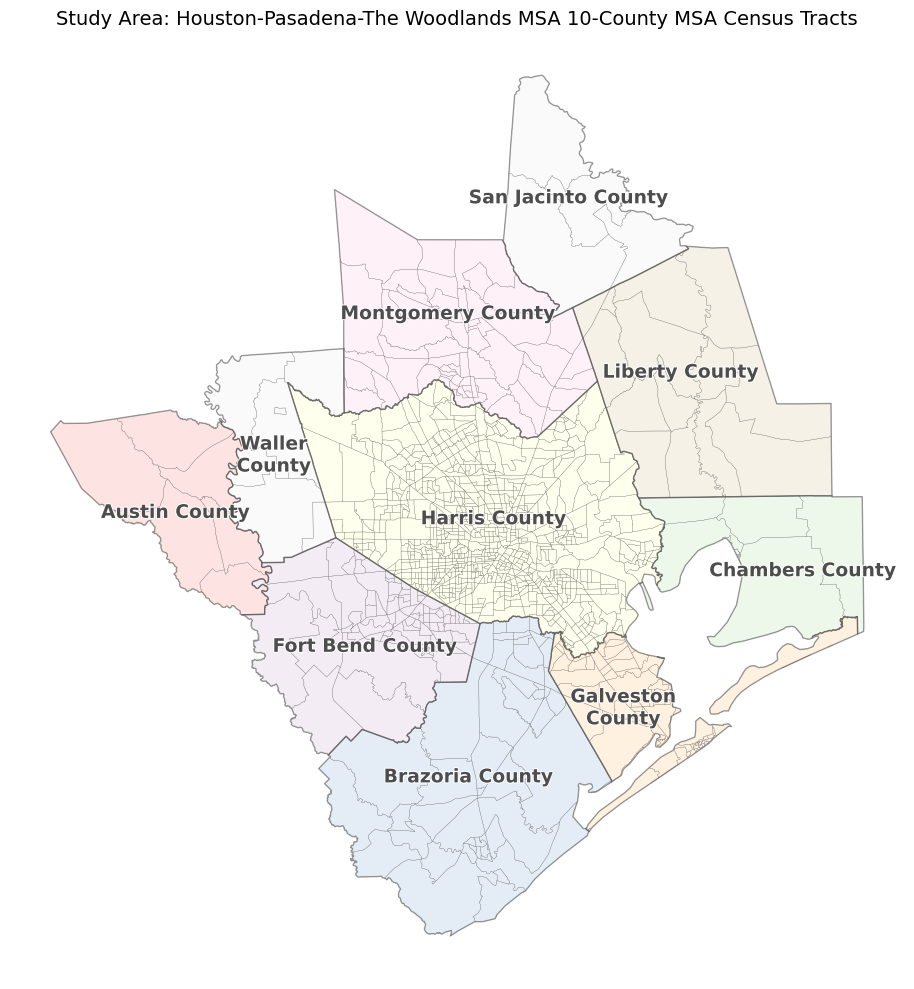

In [25]:
# Study Area Map with County Shading and Tract Boundaries
# Input: County polygons with label positions and census tract polygons for the 10-county MSA.
# Output: Study area map saved as PNG, SVG, and PDF.

from pathlib import Path
import re
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ---------------------------------------------------------------------
# Fallback output-folder and figure-save setup if earlier setup cell was not run
# ---------------------------------------------------------------------

# Define the main project folder if it was not already created in an earlier cell
if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")

# Define the main manuscript-figure folder if it was not already created
if "FIGURE_ROOT_DIR" not in globals():
    FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"

# Define the folder for editable SVG files and vector PDF files
if "FIGURE_SOURCE_DIR" not in globals():
    FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"

# Define the folder for high-resolution PNG image files
if "FIGURE_RASTER_DIR" not in globals():
    FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"

# Define the folder for figure-related data tables
if "FIGURE_TABLE_DIR" not in globals():
    FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"

# Define a helper function to make safe file names if it was not already created
if "clean_file_stem" not in globals():
    def clean_file_stem(stem):
        stem = str(stem).strip().replace(" ", "_")
        stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)
        stem = re.sub(r"_+", "_", stem)
        return stem.strip("_")

# Define a helper function to create required output folders if needed
if "ensure_output_folders" not in globals():
    def ensure_output_folders():
        drive_root = Path("/content/drive/MyDrive")

        # Stop with a clear error if Google Drive is not mounted
        if not drive_root.exists():
            raise FileNotFoundError(
                "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
                "Run the Google Drive mount cell first."
            )

        # Create each required output folder if it does not already exist
        for folder in [
            PROJECT_DIR,
            FIGURE_ROOT_DIR,
            FIGURE_SOURCE_DIR,
            FIGURE_RASTER_DIR,
            FIGURE_TABLE_DIR
        ]:
            folder.mkdir(parents=True, exist_ok=True)

        return True

# Define a helper function to save the same map in PNG, SVG, and PDF formats
if "save_figure_set" not in globals():
    def save_figure_set(fig, stem, dpi=600, bbox_inches="tight"):
        """
        Save one Matplotlib figure as:
        1. High-resolution PNG raster
        2. Native SVG vector
        3. Vector PDF
        """
        # Make sure output folders exist before saving files
        ensure_output_folders()

        # Clean the file stem so it is safe to use in saved file names
        stem = clean_file_stem(stem)

        # Define the full output paths for the three saved file formats
        png_path = FIGURE_RASTER_DIR / f"{stem}.png"
        svg_path = FIGURE_SOURCE_DIR / f"{stem}.svg"
        pdf_path = FIGURE_SOURCE_DIR / f"{stem}.pdf"

        # Save the map as a high-resolution PNG image
        fig.savefig(
            png_path,
            dpi=dpi,
            bbox_inches=bbox_inches,
            facecolor="white"
        )

        # Save the map as an editable SVG vector file
        fig.savefig(
            svg_path,
            format="svg",
            bbox_inches=bbox_inches,
            facecolor="white"
        )

        # Save the map as a vector PDF file
        fig.savefig(
            pdf_path,
            format="pdf",
            bbox_inches=bbox_inches,
            facecolor="white"
        )

        # Print the saved file paths for quick confirmation
        print(f"Saved: {png_path}")
        print(f"Saved: {svg_path}")
        print(f"Saved: {pdf_path}")

        # Return the saved file paths for possible later use
        return {
            "png": png_path,
            "svg": svg_path,
            "pdf": pdf_path
        }

# Confirm output folders exist before plotting/saving
ensure_output_folders()

# ---------------------------------------------------------------------
# Fallback county-label helper if earlier helper cell was not run
# ---------------------------------------------------------------------

# Define a helper function to add county names to the map if it was not already created
if "add_county_labels" not in globals():
    def add_county_labels(ax, county_gdf, fontsize=9):
        """
        Add county labels to a map.

        Uses an existing label_point column if available.
        Otherwise creates representative points from county geometry.
        """
        # Make a copy so the original county data is not changed
        label_gdf = county_gdf.copy()

        # Create label points inside each county if label points are not already available
        if "label_point" not in label_gdf.columns:
            label_gdf["label_point"] = label_gdf.geometry.representative_point()

        # Add one text label for each county
        for _, row in label_gdf.iterrows():
            county_name = str(row["NAME"])

            # Split longer county names onto two lines for better map readability
            if county_name == "Waller":
                label = "Waller\nCounty"
            elif county_name == "Galveston":
                label = "Galveston\nCounty"
            else:
                label = f"{county_name} County"

            # Place the county label at the county label point
            txt = ax.text(
                row["label_point"].x,
                row["label_point"].y,
                label,
                fontsize=fontsize,
                ha="center",
                va="center",
                color="black",
                weight="bold"
            )

            # Add a white outline around the label so it remains readable on the map
            txt.set_path_effects(
                [pe.withStroke(linewidth=1.4, foreground="white")]
            )

# ---------------------------------------------------------------------
# Validate required objects
# ---------------------------------------------------------------------

# Stop if the county boundary data has not been loaded yet
if "counties" not in globals():
    raise NameError("counties is not defined. Run the county-boundaries cell first.")

# Stop if the 10-county MSA tract data has not been prepared yet
if "tracts_study" not in globals():
    raise NameError("tracts_study is not defined. Run the tract filtering/preparation cell first.")

# ---------------------------------------------------------------------
# Plot study area map
# ---------------------------------------------------------------------

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Draw county polygons with light shading and black county borders
counties.plot(
    ax=ax,
    column="NAME",
    cmap="Pastel1",
    edgecolor="black",
    linewidth=1.0,
    alpha=0.35
)

# Draw census tract boundaries within the counties
tracts_study.boundary.plot(
    ax=ax,
    color="#666666",
    linewidth=0.15
)

# Add county labels to the map
add_county_labels(ax, counties, fontsize=13.5)

# Apply consistent county-label size and color
for text in ax.texts:
    text.set_fontsize(13.5)
    text.set_color("#4d4d4d")

# Add the map title
ax.set_title(
    "Study Area: Houston-Pasadena-The Woodlands MSA 10-County MSA Census Tracts",
    fontsize=14
)

# Remove map axes so only the geography is shown
ax.set_axis_off()

# Adjust spacing so the map elements fit cleanly
plt.tight_layout()

# Save the completed map in PNG, SVG, and PDF formats
save_figure_set(fig, "study_area_map")

# Display the completed map
plt.show()

**Diabetes and Obesity Prevalence Maps**

The following cell creates side-by-side maps of estimated diabetes and obesity prevalence. These maps provide context for the continuous combined score map and the overlap-enrichment analysis.


Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/diabetes_obesity_prevalence_maps.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/diabetes_obesity_prevalence_maps.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/diabetes_obesity_prevalence_maps.pdf


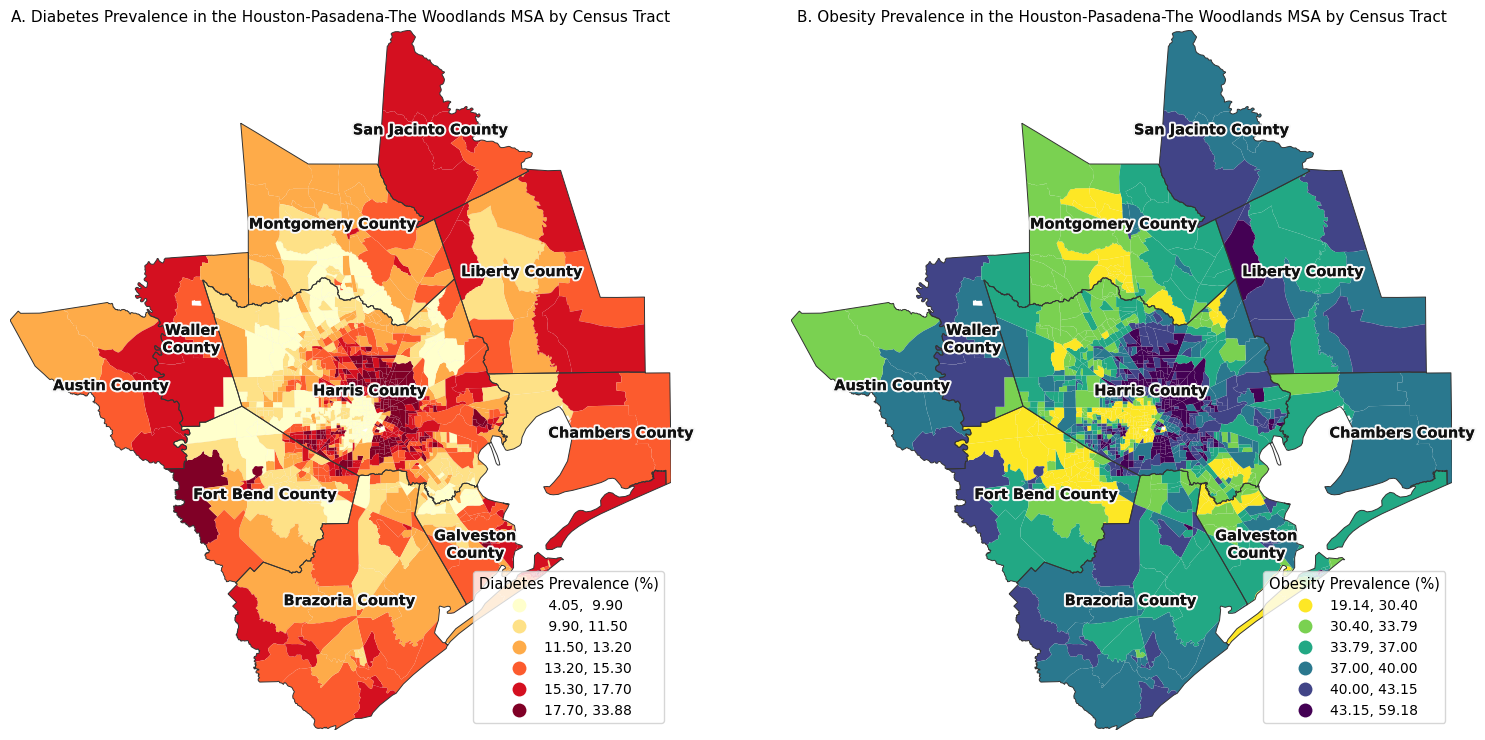

In [26]:
# Combined Diabetes and Obesity Prevalence Maps
# Input: Final geospatial dataset with diabetes and obesity prevalence estimates.
# Output: Combined diabetes and obesity prevalence maps saved as PNG, SVG, and PDF.

# Load plotting tools used to create the maps and improve label readability
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ---------------------------------------------------------------------
# Create side-by-side tract-level maps for diabetes and obesity prevalence.
# The diabetes map uses a yellow-to-red scale.
# The obesity map uses a reversed viridis scale.
# Both maps use quantile classes so each color group contains a similar number of tracts.
# ---------------------------------------------------------------------

# Set county label and legend text sizes for consistent map formatting
county_label_fontsize = 10.5
legend_fontsize = 10
legend_title_fontsize = 10.5
county_label_halo_color = "#f7f7f7"

# Add a light outline around county labels so they remain readable on top of map colors
def improve_county_label_readability(ax):
    for text in ax.texts:
        text.set_fontsize(county_label_fontsize)
        text.set_color("#111111")
        text.set_path_effects(
            [
                pe.withStroke(
                    linewidth=3.0,
                    foreground=county_label_halo_color
                ),
                pe.Normal()
            ]
        )

# Create one row with two map panels
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7.5)
)

# Get the full map boundary so both maps use the same geographic extent
xmin, ymin, xmax, ymax = gdf.total_bounds

# ---------------------------------------------------------------------
# Diabetes prevalence map
# ---------------------------------------------------------------------

# Plot census tracts by diabetes prevalence using six quantile-based color groups
gdf.plot(
    column="diabetes_pct",
    scheme="quantiles",
    k=6,
    cmap="YlOrRd",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=axes[0],
    legend_kwds={
        "title": "Diabetes Prevalence (%)",
        "loc": "lower right",
        "fontsize": legend_fontsize,
        "title_fontsize": legend_title_fontsize
    }
)

# Add county boundary lines on top of the tract map
counties.boundary.plot(
    ax=axes[0],
    color="#333333",
    linewidth=0.7
)

# Add county names and improve their readability
add_county_labels(axes[0], counties, fontsize=county_label_fontsize)
improve_county_label_readability(axes[0])

# Add the map title
axes[0].set_title(
    "A. Diabetes Prevalence in the Houston-Pasadena-The Woodlands MSA by Census Tract",
    fontsize=11
)

# Use the same map limits as the full study area and remove axis markings
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymin, ymax)
axes[0].set_axis_off()

# ---------------------------------------------------------------------
# Obesity prevalence map
# ---------------------------------------------------------------------

# Plot census tracts by obesity prevalence using six quantile-based color groups
gdf.plot(
    column="obesity_pct",
    scheme="quantiles",
    k=6,
    cmap="viridis_r",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=axes[1],
    legend_kwds={
        "title": "Obesity Prevalence (%)",
        "loc": "lower right",
        "fontsize": legend_fontsize,
        "title_fontsize": legend_title_fontsize
    }
)

# Add county boundary lines on top of the tract map
counties.boundary.plot(
    ax=axes[1],
    color="#333333",
    linewidth=0.7
)

# Add county names and improve their readability
add_county_labels(axes[1], counties, fontsize=county_label_fontsize)
improve_county_label_readability(axes[1])

# Add the map title
axes[1].set_title(
    "B. Obesity Prevalence in the Houston-Pasadena-The Woodlands MSA by Census Tract",
    fontsize=11
)

# Use the same map limits as the full study area and remove axis markings
axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(ymin, ymax)
axes[1].set_axis_off()

# Adjust spacing so the two maps fit cleanly together
plt.tight_layout()
plt.subplots_adjust(wspace=0.02)

# Save the completed map in raster and vector formats, then display it
save_figure_set(fig, "diabetes_obesity_prevalence_maps")
plt.show()

**Continuous Combined Diabetes-Obesity Score Map**

The following cell maps the continuous combined diabetes-obesity score across the Greater Houston census tracts. The score is displayed using six quantile-based categories, with each category containing approximately the same number of tracts and higher values representing higher modeled combined burden.

County boundaries and county names are added to provide geographic context. The cell verifies that the continuous combined score is available before creating the map and saves the completed figure in PNG, SVG, and PDF formats.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/continuous_combined_diabetes_obesity_burden_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/continuous_combined_diabetes_obesity_burden_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/continuous_combined_diabetes_obesity_burden_map.pdf


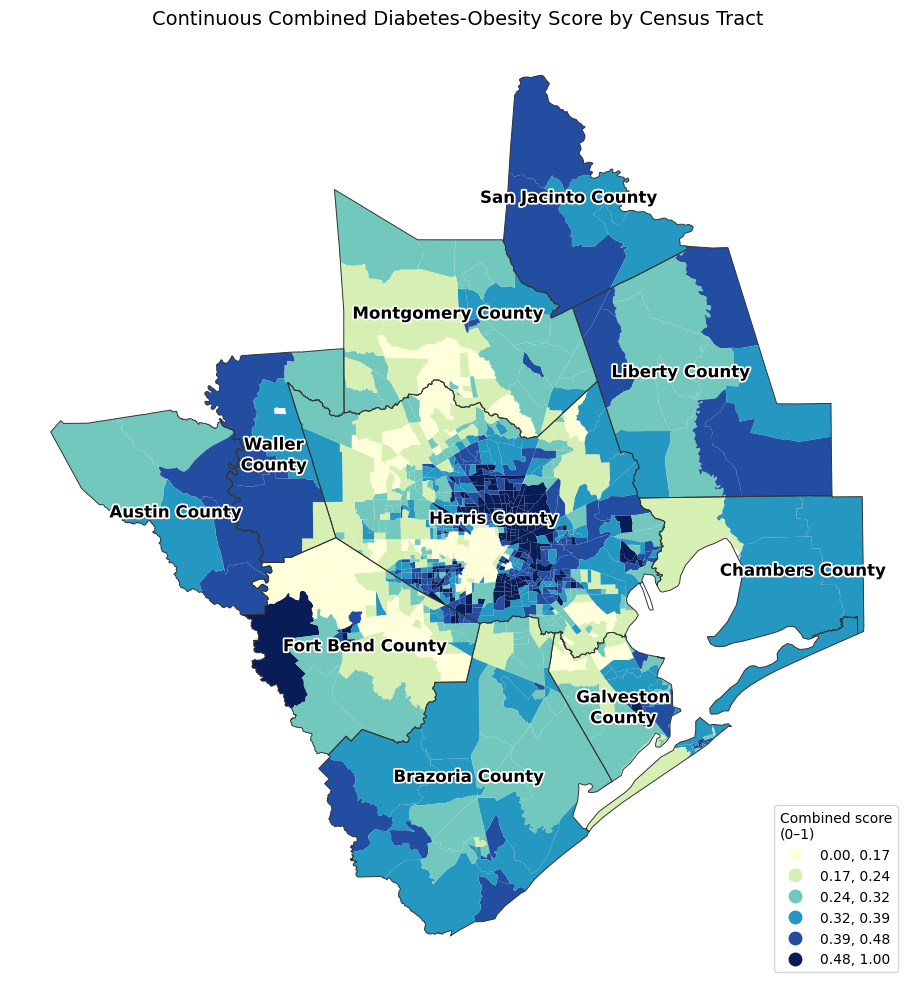

In [27]:
# Continuous Combined Diabetes-Obesity Score Map
# Input: Final geospatial dataset with continuous composite diabetes-obesity score.
# Output: Continuous combined score map saved as PNG, SVG, and PDF.

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Validate required columns
required_cols = ["composite"]
missing_cols = [c for c in required_cols if c not in gdf.columns]
if missing_cols:
    raise KeyError(
        "Missing composite-score column. Run the composite score cell first. "
        f"Missing: {missing_cols}"
    )

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot census tracts using the continuous composite score grouped into six equal-count classes
gdf.plot(
    column="composite",
    scheme="quantiles",
    k=6,
    cmap="YlGnBu",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=ax,
    legend_kwds={
        "title": "Combined score\n(0–1)",
        "loc": "lower right",
        "fontsize": 10,
        "title_fontsize": 10,
        "fmt": "{:.2f}"
    },
    missing_kwds={
        "color": "#f0f0f0",
        "edgecolor": "#d9d9d9",
        "hatch": "///",
        "label": "Missing"
    }
)

# Add county boundary lines
counties.boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.7
)

# Add county names
add_county_labels(ax, counties, fontsize=12)

# Improve county label readability
for text in ax.texts:
    text.set_color("black")
    text.set_fontsize(12)
    text.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

# Add map title
ax.set_title(
    "Continuous Combined Diabetes-Obesity Score by Census Tract",
    fontsize=14
)

# Remove axes for manuscript-style map
ax.set_axis_off()

# Adjust spacing
plt.tight_layout()

# Save the figure using the same output-folder and file-naming structure
save_figure_set(fig, "continuous_combined_diabetes_obesity_burden_map")

# Display the map
plt.show()

**Diabetes and Obesity Relationship Across Census Tracts**

The following cell creates a scatterplot showing the tract-level relationship between estimated diabetes and obesity prevalence rank percentiles. Each point represents one census tract, with its diabetes rank percentile shown on the horizontal axis and its obesity rank percentile shown on the vertical axis.

A 45-degree reference line indicates where the diabetes and obesity rank percentiles would be equal. The cell calculates the Spearman rank correlation between the two prevalence estimates and displays the correlation coefficient on the plot.

The tract-level values used in the figure are also stored in a separate table for export. The completed plot is saved in PNG, SVG, and PDF formats.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/diabetes_obesity_relationship_plot.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/diabetes_obesity_relationship_plot.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/diabetes_obesity_relationship_plot.pdf


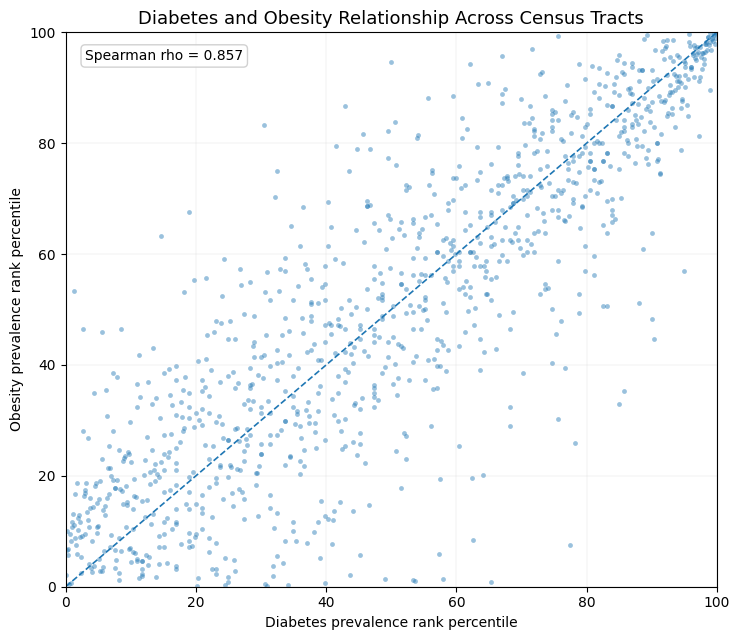

In [28]:

# Diabetes and Obesity Relationship Plot
# Input: Diabetes and obesity rank percentiles from the continuous combined-score cell.
# Output: Scatterplot showing the tract-level relationship between diabetes and obesity rank percentiles.

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

# Validate that the rank variables were created by the continuous combined-score cell
required_rank_cols = [
    "diabetes_rank_percentile",
    "obesity_rank_percentile"
]
missing_rank_cols = [c for c in required_rank_cols if c not in gdf.columns]
if missing_rank_cols:
    raise KeyError(
        "Missing rank columns. Run the continuous combined-score cell first. "
        f"Missing: {missing_rank_cols}"
    )

# Calculate the rank correlation for the plot annotation
rank_rho, rank_p = spearmanr(
    gdf["diabetes_pct"],
    gdf["obesity_pct"],
    nan_policy="omit"
)

# Build a clean export table for this plot
diabetes_obesity_rank_plot_df = gdf[
    [
        "diabetes_pct",
        "obesity_pct",
        "diabetes_rank_percentile",
        "obesity_rank_percentile",
        "composite",
        "composite_0_100"
    ]
].copy()

# Create the scatterplot
fig, ax = plt.subplots(figsize=(7.5, 6.5))

ax.scatter(
    diabetes_obesity_rank_plot_df["diabetes_rank_percentile"],
    diabetes_obesity_rank_plot_df["obesity_rank_percentile"],
    s=12,
    alpha=0.45,
    linewidths=0
)

# Add a 45-degree reference line for equal diabetes and obesity rank percentiles
ax.plot([0, 100], [0, 100], linewidth=1.2, linestyle="--")

# Add plot labels and title
ax.set_title(
    "Diabetes and Obesity Relationship Across Census Tracts",
    fontsize=13
)
ax.set_xlabel("Diabetes prevalence rank percentile")
ax.set_ylabel("Obesity prevalence rank percentile")

# Keep the axes fixed at percentile bounds
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# Add a simple annotation with the rank correlation
ax.text(
    0.03,
    0.97,
    f"Spearman rho = {rank_rho:.3f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9}
)

# Add a light grid for readability
ax.grid(True, linewidth=0.3, alpha=0.4)

# Adjust spacing and save the plot
plt.tight_layout()
save_figure_set(fig, "diabetes_obesity_relationship_plot")
plt.show()

**Observed and Expected High-Burden Overlap Tracts Plot**

The following cell creates a bar plot comparing the observed number of high-burden overlap tracts with the number expected if the high-diabetes and high-obesity classifications were independent.

The values are taken from the overlap-enrichment summary created by the preceding analysis. The cell also creates a compact plot-data table for export, adds the count above each bar, and saves the completed figure in PNG, SVG, and PDF formats.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/observed_expected_high_burden_overlap_tracts_plot.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/observed_expected_high_burden_overlap_tracts_plot.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/observed_expected_high_burden_overlap_tracts_plot.pdf


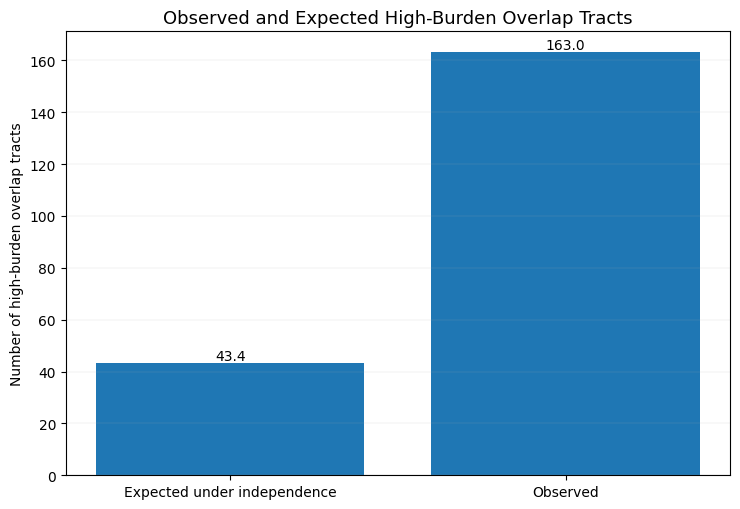

In [29]:
# Observed and Expected High-Burden Overlap Tracts Plot
# Input: Overlap enrichment summary table from the enrichment analysis cell.
# Output: Bar plot comparing observed high-burden overlap tracts with the expected count under independence.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Stop if the enrichment table does not exist yet.
if "overlap_enrichment_df" not in globals():
    raise NameError("overlap_enrichment_df is not available. Run the overlap enrichment cell first.")

# Helper to pull one value from the enrichment table.
def _pull_enrichment_value(measure):
    rows = overlap_enrichment_df.loc[overlap_enrichment_df["measure"] == measure, "value"]
    if len(rows) == 0:
        return np.nan
    return rows.iloc[0]

# Extract the values to plot.
observed_overlap_plot = float(_pull_enrichment_value("Observed high-burden overlap tracts"))
expected_overlap_plot = float(_pull_enrichment_value("Expected overlap under independence"))

# Create a small plot-data table for export.
overlap_enrichment_plot_df = pd.DataFrame(
    [
        {"category": "Expected under independence", "overlap_count": expected_overlap_plot},
        {"category": "Observed", "overlap_count": observed_overlap_plot}
    ]
)

# Create the bar plot.
fig, ax = plt.subplots(figsize=(7.5, 5.2))

ax.bar(
    overlap_enrichment_plot_df["category"],
    overlap_enrichment_plot_df["overlap_count"]
)

# Add value labels above bars.
for x, y in enumerate(overlap_enrichment_plot_df["overlap_count"]):
    ax.text(
        x,
        y,
        f"{y:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add labels and title.
ax.set_title("Observed and Expected High-Burden Overlap Tracts", fontsize=13)
ax.set_ylabel("Number of high-burden overlap tracts")
ax.set_xlabel("")
ax.grid(axis="y", linewidth=0.3, alpha=0.4)

plt.tight_layout()
save_figure_set(fig, "observed_expected_high_burden_overlap_tracts_plot")
plt.show()

**Social Vulnerability Map by Census Tract**

The following cell creates a map of Social Vulnerability Index (SVI) overall percentile values by census tract. It uses the final geospatial dataset, `gdf`, and maps the `rpl_themes` column, where higher values represent higher overall social vulnerability.

The tract values are divided into six quantile groups so that each color category contains approximately the same number of census tracts. The green color scale shows lower-to-higher SVI percentile values, with darker green areas representing higher social vulnerability. Tracts with missing SVI values are shown in light gray with hatching so they can be identified separately from valid low-SVI tracts.

The cell also adds county boundary outlines on top of the tract map to make the regional context clearer. County labels are added using the `add_county_labels()` helper function, and the label color and font size are multivariable for readability.

The map title is added, the map axes are removed, and the layout is tightened so the saved output has clean spacing. Finally, the `save_figure_set()` helper function saves the completed map in PNG, SVG, and PDF formats for use in the manuscript, presentations, or later editing. The plot is then displayed in the notebook.


Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/social_vulnerability_index_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/social_vulnerability_index_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/social_vulnerability_index_map.pdf


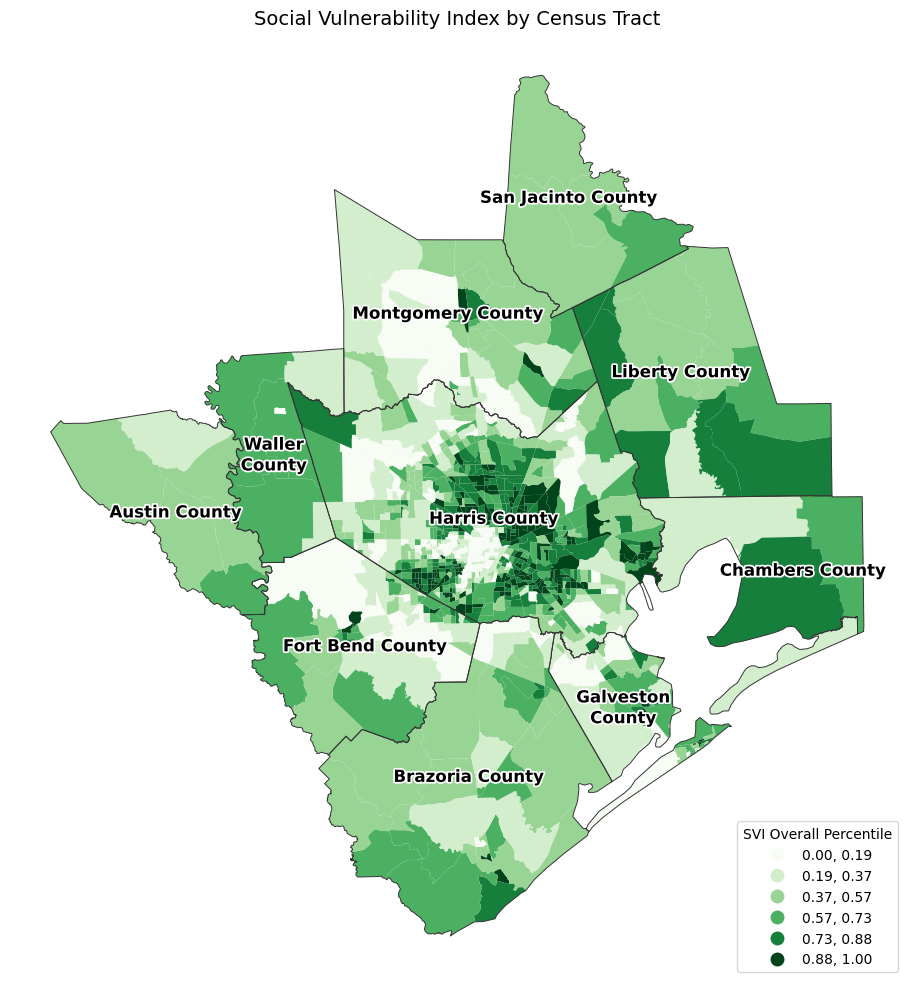

In [30]:
# Social Vulnerability Map by Census Tract
# Input: Final geospatial dataset with SVI overall percentile.
# Output: Tract-level SVI map saved as PNG, SVG, and PDF.

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot census tracts using SVI overall percentile grouped into six equal-count classes
gdf.plot(
    column="rpl_themes",
    scheme="quantiles",
    k=6,
    cmap="Greens",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=ax,
    legend_kwds={
        "title": "SVI Overall Percentile",
        "loc": "lower right",
        "fontsize": 10,
        "title_fontsize": 10
    },
    missing_kwds={
        "color": "#f0f0f0",
        "edgecolor": "#d9d9d9",
        "hatch": "///",
        "label": "Missing"
    }
)

# Add county boundary lines so county outlines are visible on top of the tract map
counties.boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.7
)

# Add county names to the map
add_county_labels(ax, counties, fontsize=12)

# Improve county label readability with black text and white outline
for text in ax.texts:
    text.set_color("#000000")
    text.set_fontsize(12)
    text.set_path_effects([pe.withStroke(linewidth=2.5, foreground="white")])

# Add a clear map title
ax.set_title(
    "Social Vulnerability Index by Census Tract",
    fontsize=14
)

# Remove axes because map coordinates are not needed for this manuscript figure
ax.set_axis_off()

# Adjust spacing so the map, title, and legend fit cleanly
plt.tight_layout()

# Save the map in raster, editable SVG, and vector PDF formats
save_figure_set(fig, "social_vulnerability_index_map")

# Display the completed map in the notebook
plt.show()

**Combined Diabetes-Obesity Score by USDA Low-Income, Low-Access, and LILA Status**

This plot summarizes the continuous combined diabetes-obesity score by USDA low-income status, low-access status, and LILA status. The dots show group medians for tracts without and with each indicator.


Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/usda_low_income_low_access_lila_dotline_plot.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/usda_low_income_low_access_lila_dotline_plot.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/usda_low_income_low_access_lila_dotline_plot.pdf


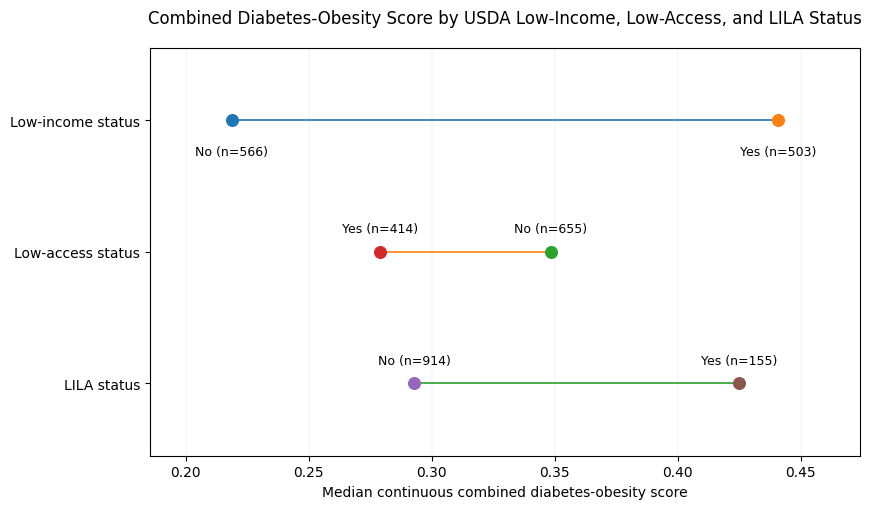

In [31]:
# Combined Diabetes-Obesity Score by USDA Low-Income, Low-Access, and LILA Status
# Input: Final gdf with continuous combined score and USDA low-income, low-access, and LILA indicators.
# Output: Dot-and-line summary plot of median continuous combined score by USDA indicator status.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Confirm the required columns are available.
required_usda_dot_cols = [
    "composite",
    "low_income_tract",
    "low_access_1and10",
    "lila_1and10"
]
missing_usda_dot_cols = [c for c in required_usda_dot_cols if c not in gdf.columns]
if missing_usda_dot_cols:
    raise KeyError(
        "Missing columns needed for the USDA dot-and-line summary plot: "
        f"{missing_usda_dot_cols}"
    )

# Indicator definitions used in the plot.
usda_indicator_plot_specs = [
    ("low_income_tract", "Low-income status"),
    ("low_access_1and10", "Low-access status"),
    ("lila_1and10", "LILA status")
]

# Build the plot summary table from the continuous combined score.
usda_dot_plot_rows = []
for indicator_col, indicator_label in usda_indicator_plot_specs:
    indicator = pd.to_numeric(gdf[indicator_col], errors="coerce").fillna(0).astype(int)
    score = pd.to_numeric(gdf["composite"], errors="coerce")

    for group_value, group_label in [(0, "No"), (1, "Yes")]:
        vals = score[indicator == group_value].dropna()
        usda_dot_plot_rows.append(
            {
                "usda_indicator": indicator_label,
                "indicator_column": indicator_col,
                "group": group_label,
                "indicator_value": group_value,
                "n": int(len(vals)),
                "median_combined_score": float(vals.median()) if len(vals) else np.nan,
                "q1_combined_score": float(vals.quantile(0.25)) if len(vals) else np.nan,
                "q3_combined_score": float(vals.quantile(0.75)) if len(vals) else np.nan
            }
        )

usda_dot_plot_df = pd.DataFrame(usda_dot_plot_rows)

# Define row positions so each indicator appears on one horizontal line.
indicator_order = [label for _, label in usda_indicator_plot_specs]
y_positions = {label: i for i, label in enumerate(indicator_order[::-1])}

# Create the plot.
fig, ax = plt.subplots(figsize=(8.8, 5.2))

label_y_offsets = {
    "Low-income status": -18,
    "Low-access status": 12,
    "LILA status": 12
}

for indicator_label in indicator_order:
    subset = usda_dot_plot_df.loc[usda_dot_plot_df["usda_indicator"] == indicator_label].copy()
    subset = subset.sort_values("indicator_value")
    y = y_positions[indicator_label]

    x_values = subset["median_combined_score"].to_numpy(dtype=float)
    ax.plot(x_values, [y, y], linewidth=1.2, zorder=2)

    for _, row in subset.iterrows():
        ax.scatter(row["median_combined_score"], y, s=70, zorder=3)

        y_offset = label_y_offsets[indicator_label]
        ax.annotate(
            f"{row['group']} (n={int(row['n'])})",
            xy=(row["median_combined_score"], y),
            xytext=(0, y_offset),
            textcoords="offset points",
            ha="center",
            va="bottom" if y_offset > 0 else "top",
            fontsize=9
        )

# Add labels and formatting.
ax.set_yticks([y_positions[label] for label in indicator_order])
ax.set_yticklabels(indicator_order)
ax.set_xlabel("Median continuous combined diabetes-obesity score")
ax.set_title(
    "Combined Diabetes-Obesity Score by USDA Low-Income, Low-Access, and LILA Status",
    pad=18
)
ax.grid(axis="x", linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)

# Add a small horizontal padding around the observed medians.
xmin = usda_dot_plot_df["median_combined_score"].min()
xmax = usda_dot_plot_df["median_combined_score"].max()
pad = max((xmax - xmin) * 0.15, 0.02)
ax.set_xlim(max(0, xmin - pad), min(1, xmax + pad))
ax.set_ylim(-0.55, len(indicator_order) - 0.45)

plt.tight_layout()
save_figure_set(fig, "usda_low_income_low_access_lila_dotline_plot")
plt.show()

**Moran Scatterplot for the Continuous Combined Diabetes-Obesity Score**

The following cell creates a Moran scatterplot to show whether census tracts with similar combined diabetes-obesity scores tend to be located near each other. It first calculates the average combined score of each tract’s neighboring tracts using the row-standardized spatial weights already created for the Moran’s I analysis. This neighbor average is saved as a new column called `lag_composite`.

The plot compares each tract’s own combined diabetes-obesity score on the x-axis with the average score of its neighboring tracts on the y-axis. Each point represents one census tract. Points higher on the plot have neighbors with higher combined scores, while points lower on the plot have neighbors with lower combined scores.

The cell also adds a best-fit line to summarize the overall relationship between each tract’s score and the scores of nearby tracts. An upward-sloping line supports positive spatial clustering, meaning high-score tracts tend to be near other high-score tracts and low-score tracts tend to be near other low-score tracts.

Finally, the cell formats the plot with clear axis labels, a grid, and a title, then saves the completed scatterplot in PNG, SVG, and PDF formats for use in the manuscript and related materials.


Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/moran_scatterplot.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/moran_scatterplot.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/moran_scatterplot.pdf


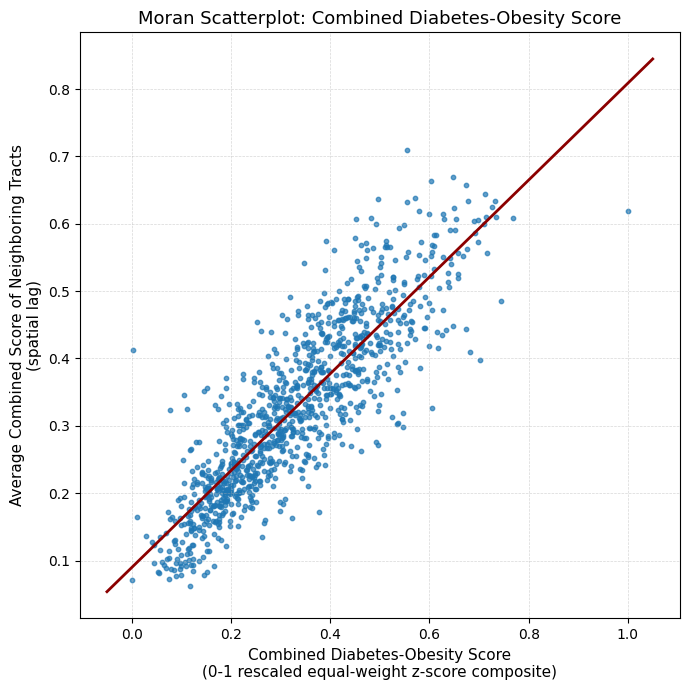

In [32]:
# Moran Scatterplot for Composite Diabetes-Obesity Score
# Input: Unified composite tract score and spatial weights defining neighboring tracts.
# Output: Moran scatterplot saved as PNG, SVG, and PDF.

# Import the tool used to calculate the average value among neighboring tracts
from libpysal.weights import lag_spatial

# Import plotting tools used to create and format the scatterplot
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Import NumPy for fitting the trend line
import numpy as np

# Compute the average composite score of neighboring tracts for each tract
gdf["lag_composite"] = lag_spatial(w, gdf["composite"])

# Create the plotting area
fig, ax = plt.subplots(figsize=(7, 7))

# Plot each tract by its own composite score and the average score of its neighbors
ax.scatter(
    gdf["composite"],
    gdf["lag_composite"],
    s=10,
    alpha=0.7
)

# Store the data ranges for the tract scores and neighboring-tract scores
xmin, xmax = gdf["composite"].min(), gdf["composite"].max()
ymin, ymax = gdf["lag_composite"].min(), gdf["lag_composite"].max()

# Add a light grid to make the scatterplot easier to read
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Fit a straight trend line showing the overall relationship between tracts and their neighbors
m, b_line = np.polyfit(gdf["composite"], gdf["lag_composite"], 1)

# Get the current x-axis range for drawing the trend line across the plot
x_vals = np.array(ax.get_xlim())

# Add the trend line to the scatterplot
ax.plot(x_vals, m * x_vals + b_line, color="darkred", linewidth=2)

# Add the plot title
ax.set_title("Moran Scatterplot: Combined Diabetes-Obesity Score", fontsize=13)

# Label the x-axis as the tract-level combined diabetes-obesity score
ax.set_xlabel(
    "Combined Diabetes-Obesity Score\n"
    "(0-1 rescaled equal-weight z-score composite)",
    fontsize=11
)

# Label the y-axis as the average combined score of neighboring tracts
ax.set_ylabel(
    "Average Combined Score of Neighboring Tracts\n"
    "(spatial lag)",
    fontsize=11
)

# Adjust spacing so labels and titles are not cut off
plt.tight_layout()

# Save the scatterplot in the manuscript figure output folders
save_figure_set(fig, "moran_scatterplot")

# Display the scatterplot in the notebook
plt.show()

**Getis-Ord Gi\* Local Cluster Map**

The following cell maps the local Getis-Ord Gi\* high-cluster results for the continuous combined diabetes-obesity score. Before creating the map, it verifies that the required Gi\* statistics, adjusted P values, cluster classifications, and high-burden overlap indicator are present in the geospatial dataset.

The map distinguishes tracts that remain significant after Benjamini-Hochberg False Discovery Rate adjustment, tracts significant at the nominal P ≤ .05 level, and high-burden overlap tracts that are not Gi\* local clusters. All remaining tracts are shown as the background category.

The cell also verifies that the tracts classified as nominal Gi\* high clusters have a higher median continuous combined score than the other tracts. County boundaries and county names are added for geographic context, and the completed map is saved in PNG, SVG, and PDF formats.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/getis_ord_gi_star_high_clusters_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/getis_ord_gi_star_high_clusters_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/getis_ord_gi_star_high_clusters_map.pdf


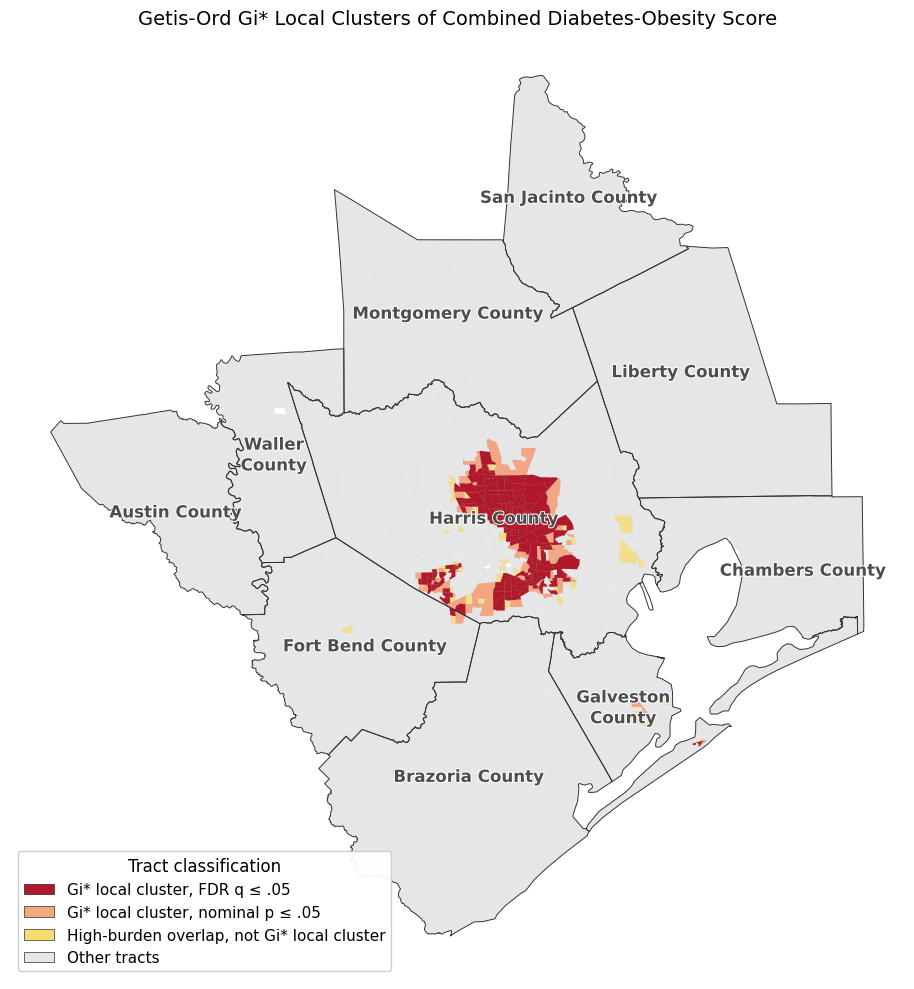

In [33]:
# Getis-Ord Gi* Cluster Map
# Input: gdf with gi_star_high_cluster_p05 and gi_star_high_cluster_fdr05 indicators.
# Output: Map showing statistically significant local clusters using the continuous combined score.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------------
# Validate Gi* columns
# ---------------------------------------------------------------------

# List the columns required to make the Gi* local cluster map
required_cols = [
    "composite",
    "gi_star_z",
    "gi_star_p",
    "gi_star_p_fdr",
    "gi_star_high_cluster_p05",
    "gi_star_high_cluster_fdr05",
    "high_burden_overlap"
]

# Check whether any required columns are missing from the analysis dataset
missing_cols = [c for c in required_cols if c not in gdf.columns]

# Stop the code if the Gi* results have not been created yet
if missing_cols:
    raise KeyError(
        "Missing Gi* columns. Run the Gi* analysis cell first. "
        f"Missing: {missing_cols}"
    )

# Confirm that nominal Gi* local cluster tracts have higher composite scores than other tracts
if int(gdf["gi_star_high_cluster_p05"].sum()) > 0:
    median_high = gdf.loc[gdf["gi_star_high_cluster_p05"] == 1, "composite"].median()
    median_other = gdf.loc[gdf["gi_star_high_cluster_p05"] == 0, "composite"].median()

    # Stop the code if the mapped local clusters do not actually represent higher-burden areas
    if median_high <= median_other:
        raise ValueError(
            "Not plotting: Gi* local clusters do not have higher median composite than other tracts."
        )

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

# Create a square map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all census tracts in light gray as the background layer
gdf.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="#cccccc",
    linewidth=0.02
)

# Select high-burden overlap tracts that are not Gi* local clusters
high_burden_not_gi = gdf.loc[
    (gdf["high_burden_overlap"] == 1) &
    (gdf["gi_star_high_cluster_p05"] == 0)
]

# Add high-burden overlap tracts that did not meet the Gi* local cluster threshold
if not high_burden_not_gi.empty:
    high_burden_not_gi.plot(
        ax=ax,
        color="#f7dc6f",
        edgecolor="#666666",
        linewidth=0.03,
        alpha=0.75
    )

# Select tracts that are Gi* local clusters at the nominal p ≤ .05 level
nominal_high = gdf.loc[gdf["gi_star_high_cluster_p05"] == 1]

# Add nominal Gi* local cluster tracts to the map
if not nominal_high.empty:
    nominal_high.plot(
        ax=ax,
        color="#f4a582",
        edgecolor="#666666",
        linewidth=0.03
    )

# Select tracts that remain Gi* local clusters after FDR correction
fdr_high = gdf.loc[gdf["gi_star_high_cluster_fdr05"] == 1]

# Add the strongest Gi* local cluster tracts on top of the nominal cluster layer
if not fdr_high.empty:
    fdr_high.plot(
        ax=ax,
        color="#b2182b",
        edgecolor="#333333",
        linewidth=0.04
    )

# Add county boundaries to show the study-area context
counties.boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.7
)

# Add county names to the map
add_county_labels(ax, counties, fontsize=12)

# Format county label color and size for readability
for text in ax.texts:
    text.set_color("#4d4d4d")
    text.set_fontsize(12)

# Create legend entries for each tract classification shown on the map
legend_handles = [
    mpatches.Patch(
        facecolor="#b2182b",
        edgecolor="black",
        linewidth=0.4,
        label="Gi* local cluster, FDR q ≤ .05"
    ),
    mpatches.Patch(
        facecolor="#f4a582",
        edgecolor="black",
        linewidth=0.4,
        label="Gi* local cluster, nominal p ≤ .05"
    ),
    mpatches.Patch(
        facecolor="#f7dc6f",
        edgecolor="black",
        linewidth=0.4,
        label="High-burden overlap, not Gi* local cluster"
    ),
    mpatches.Patch(
        facecolor="#e6e6e6",
        edgecolor="black",
        linewidth=0.4,
        label="Other tracts"
    )
]

# Add the legend to explain the tract categories
ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.95,
    title="Tract classification",
    title_fontsize=12,
    fontsize=11
)

# Add a clear map title
ax.set_title(
    "Getis-Ord Gi* Local Clusters of Combined Diabetes-Obesity Score",
    fontsize=14
)

# Remove map axes because latitude and longitude labels are not needed here
ax.set_axis_off()

# Tighten spacing around the map before saving and displaying it
plt.tight_layout()

# Save the map as PNG, SVG, and PDF using the project figure-saving function
save_figure_set(fig, "getis_ord_gi_star_high_clusters_map")

# Display the completed map
plt.show()

**High-Burden Overlap Tracts by Census Tract**

The following cell maps the census tracts classified as high-burden overlap tracts. These are the tracts that meet both the 80th-percentile high-diabetes criterion and the 80th-percentile high-obesity criterion.

High-burden overlap tracts are highlighted against the remaining census tracts. County boundaries and county names are added to show their geographic distribution across the study area. The completed map is saved in PNG, SVG, and PDF formats.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/high_burden_overlap_tracts_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/high_burden_overlap_tracts_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/high_burden_overlap_tracts_map.pdf


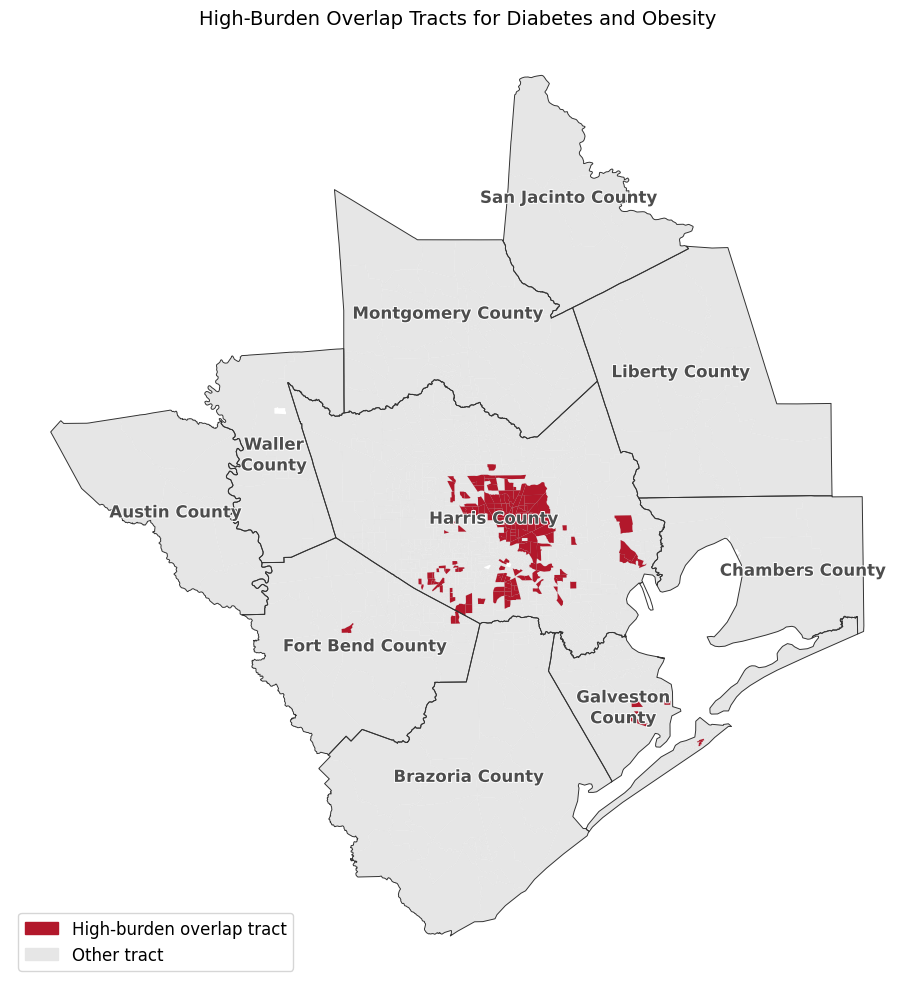

In [34]:
# High-Burden Overlap Map by Census Tract
# Input: Final geospatial dataset with high_burden_overlap indicator.
# Output: Map showing tracts in the highest 20% for both diabetes and obesity estimates.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all census tracts as the light gray background
gdf.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="#cccccc",
    linewidth=0.02
)

# Select only tracts classified as high-burden overlap tracts
overlap_gdf = gdf.loc[gdf["high_burden_overlap"] == 1]

# Plot high-burden overlap tracts in red if any are present
if not overlap_gdf.empty:
    overlap_gdf.plot(
        ax=ax,
        color="#b2182b",
        edgecolor="#666666",
        linewidth=0.03
    )

# Add county boundaries on top of the tract map
counties.boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.7
)

# Add county names to the map
add_county_labels(ax, counties, fontsize=12)

# Format county label color and size for readability
for text in ax.texts:
    text.set_color("#4d4d4d")
    text.set_fontsize(12)

# Create legend labels for high-burden overlap and other tracts
legend_handles = [
    mpatches.Patch(color="#b2182b", label="High-burden overlap tract"),
    mpatches.Patch(color="#e6e6e6", label="Other tract")
]

# Add the legend to the lower-left corner
ax.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=12
)

# Add the map title
ax.set_title(
    "High-Burden Overlap Tracts for Diabetes and Obesity",
    fontsize=14
)

# Remove map axes for a cleaner manuscript-style map
ax.set_axis_off()

# Adjust spacing around the map
plt.tight_layout()

# Save the map as PNG, SVG, and PDF using the project save function
save_figure_set(fig, "high_burden_overlap_tracts_map")

# Display the map in the notebook
plt.show()

**Threshold Sensitivity for High-Burden Overlap Tracts**

The following cell evaluates whether the high-burden overlap findings depend on the selected percentile cutoff. It repeats the overlap analysis using the 75th-, 80th-, and 85th-percentile thresholds for estimated diabetes and obesity prevalence.

For each threshold, the cell calculates the diabetes and obesity cutoffs, the numbers of high-diabetes and high-obesity tracts, the observed overlap, the expected overlap under independence, the enrichment ratio, and the Jaccard overlap.

A blocked permutation test is also performed at each threshold using 10,000 permutations. The obesity classifications are shuffled within county and urban/rural groups when the urban/rural indicator is available and within counties otherwise. The resulting table reports the permutation P value, mean permuted overlap, 95th percentile of the permutation distribution, and maximum permuted overlap for each threshold.

The threshold-specific classification fields are added to the final geospatial dataset so they are included in the exported analysis outputs.

In [35]:
# Threshold Sensitivity for High-Burden Overlap Tracts
# Input: Final analysis dataset with diabetes, obesity, county information, and tract identifiers.
# Output: Compact overlap sensitivity results at 75%, 80%, and 85% thresholds.

import numpy as np
import pandas as pd

# Make a copy of the final analysis dataset so the sensitivity analysis starts from the same data.
sens_df = gdf.copy()

# Define the percentile thresholds to test.
thresholds = [0.75, 0.80, 0.85]

# Use the 2010 tract GEOID column if it is available.
geoid_col_sens = "geoid_tract10" if "geoid_tract10" in sens_df.columns else None
if geoid_col_sens is None:
    possible_geoid_cols = [c for c in sens_df.columns if "geoid" in c.lower()]
    if possible_geoid_cols:
        geoid_col_sens = possible_geoid_cols[0]
    else:
        raise KeyError("Could not find a tract GEOID column for threshold sensitivity.")

# Create county and urban/rural blocks for the permutation test.
sens_df["county_fips_sens"] = sens_df[geoid_col_sens].astype(str).str[:5]

if "urban_tract" in sens_df.columns and sens_df["urban_tract"].notna().any():
    sens_df["urban_tract_block_sens"] = (
        pd.to_numeric(sens_df["urban_tract"], errors="coerce")
        .fillna(-1)
        .astype(int)
        .astype(str)
    )
    block_cols_sens = ["county_fips_sens", "urban_tract_block_sens"]
    threshold_block_description = "county plus urban/rural status"
else:
    block_cols_sens = ["county_fips_sens"]
    threshold_block_description = "county"

block_index_arrays_sens = [
    block.index.to_numpy()
    for _, block in sens_df.groupby(block_cols_sens, dropna=False)
]

# Permutation helper used for each threshold.
def blocked_overlap_permutation_p(
    diabetes_flags,
    obesity_flags,
    observed_overlap,
    block_indices,
    n_permutations=10000,
    seed=12345
):
    diabetes_flags = np.asarray(diabetes_flags, dtype=int)
    obesity_flags = np.asarray(obesity_flags, dtype=int)

    rng = np.random.default_rng(seed)
    permuted_counts = np.empty(n_permutations, dtype=int)

    for i in range(n_permutations):
        shuffled_obesity = obesity_flags.copy()
        for idx in block_indices:
            shuffled_obesity[idx] = rng.permutation(shuffled_obesity[idx])
        permuted_counts[i] = int(
            np.sum((diabetes_flags == 1) & (shuffled_obesity == 1))
        )

    p_value = (
        np.sum(permuted_counts >= observed_overlap) + 1
    ) / (n_permutations + 1)

    return (
        p_value,
        float(np.mean(permuted_counts)),
        float(np.percentile(permuted_counts, 95)),
        int(np.max(permuted_counts))
    )

# Create empty containers for storing sensitivity analysis results.
sensitivity_results = []

# Repeat the overlap analysis for each threshold.
for q in thresholds:
    threshold_label = int(q * 100)

    diab_cut_sens = pd.to_numeric(
        sens_df["diabetes_pct"],
        errors="coerce"
    ).quantile(q)

    obes_cut_sens = pd.to_numeric(
        sens_df["obesity_pct"],
        errors="coerce"
    ).quantile(q)

    diab_flag = (
        pd.to_numeric(sens_df["diabetes_pct"], errors="coerce")
        >= diab_cut_sens
    ).astype(int)

    obes_flag = (
        pd.to_numeric(sens_df["obesity_pct"], errors="coerce")
        >= obes_cut_sens
    ).astype(int)

    overlap_flag = ((diab_flag == 1) & (obes_flag == 1)).astype(int)

    # Store threshold flags in gdf so the final analysis export includes the sensitivity indicators.
    gdf[f"high_diabetes_burden_p{threshold_label}"] = diab_flag.values
    gdf[f"high_obesity_burden_p{threshold_label}"] = obes_flag.values
    gdf[f"high_burden_overlap_p{threshold_label}"] = overlap_flag.values

    high_diab_n = int(diab_flag.sum())
    high_obes_n = int(obes_flag.sum())
    observed_overlap = int(overlap_flag.sum())
    expected_overlap = high_diab_n * high_obes_n / len(sens_df)
    enrichment = (
        observed_overlap / expected_overlap
        if expected_overlap > 0
        else np.nan
    )
    union_n = high_diab_n + high_obes_n - observed_overlap
    jaccard = observed_overlap / union_n if union_n > 0 else np.nan

    permutation_p_value, mean_perm, p95_perm, max_perm = (
        blocked_overlap_permutation_p(
            diabetes_flags=diab_flag.to_numpy(dtype=int),
            obesity_flags=obes_flag.to_numpy(dtype=int),
            observed_overlap=observed_overlap,
            block_indices=block_index_arrays_sens,
            n_permutations=10000,
            seed=12345
        )
    )

    sensitivity_results.append(
        {
            "threshold_percentile": threshold_label,
            "diabetes_cutoff": diab_cut_sens,
            "obesity_cutoff": obes_cut_sens,
            "high_diabetes_tracts_n": high_diab_n,
            "high_obesity_tracts_n": high_obes_n,
            "high_burden_overlap_tracts_n": observed_overlap,
            "expected_overlap_under_independence": expected_overlap,
            "overlap_enrichment_ratio": enrichment,
            "jaccard_overlap": jaccard,
            "blocked_permutation_p_value": permutation_p_value,
            "blocked_permutation_mean_overlap": mean_perm,
            "blocked_permutation_95th_percentile_overlap": p95_perm,
            "blocked_permutation_max_overlap": max_perm,
            "permutation_blocks": threshold_block_description,
            "permutations": 10000
        }
    )

# Convert the saved sensitivity results into a clean table.
sensitivity_results_df = pd.DataFrame(sensitivity_results)

print("Threshold sensitivity for high-burden overlap tracts")
display(sensitivity_results_df)

Threshold sensitivity for high-burden overlap tracts


,threshold_percentile,diabetes_cutoff,obesity_cutoff,high_diabetes_tracts_n,high_obesity_tracts_n,high_burden_overlap_tracts_n,expected_overlap_under_independence,overlap_enrichment_ratio,jaccard_overlap,blocked_permutation_p_value,blocked_permutation_mean_overlap,blocked_permutation_95th_percentile_overlap,blocked_permutation_max_overlap,permutation_blocks,permutations
0,75,16.40,41.65,276,268,214,69.193639,3.092770,0.648485,0.0001,78.5268,89.0,105,county plus urban/rural status,10000
1,80,17.22,42.50,214,217,163,43.440599,3.752250,0.608209,0.0001,52.8465,62.0,74,county plus urban/rural status,10000
2,85,18.10,43.44,164,161,118,24.699719,4.777382,0.570048,0.0001,30.7497,38.0,48,county plus urban/rural status,10000


**USDA Low-Income, Low-Access, and LILA Descriptive Summary**

The following cell creates a descriptive summary of the continuous combined diabetes-obesity score by USDA low-income, low-access, and Low-Income, Low-Access status.

For tracts without and with each indicator, the table reports the number of tracts, median combined score, first quartile, third quartile, and interquartile range. It also calculates the difference in median combined scores between tracts with and without each classification.

If the corresponding summary table has already been created by the multivariable-model cell, the existing table is reused. Otherwise, the descriptive statistics are calculated directly from the final geospatial dataset.

In [36]:
# USDA Low-Income, Low-Access, and LILA Descriptive Summary
# Input: Final gdf with continuous combined score and USDA low-income, low-access, and LILA indicators.
# Output: Manuscript-ready table summarizing combined score by USDA indicator status.

import numpy as np
import pandas as pd

# Build or reuse the USDA descriptive summary table.
if "food_access_components_df" in globals():
    usda_descriptive_summary_df = food_access_components_df.copy()
else:
    required_usda_summary_cols = [
        "composite",
        "low_income_tract",
        "low_access_1and10",
        "lila_1and10"
    ]
    missing_usda_summary_cols = [c for c in required_usda_summary_cols if c not in gdf.columns]
    if missing_usda_summary_cols:
        raise KeyError(
            "Missing columns needed for USDA descriptive summary: "
            f"{missing_usda_summary_cols}"
        )

    rows = []
    for indicator_col, indicator_label in [
        ("low_income_tract", "Low-income status"),
        ("low_access_1and10", "Low-access status, 1-mile urban / 10-mile rural"),
        ("lila_1and10", "LILA status")
    ]:
        indicator = pd.to_numeric(gdf[indicator_col], errors="coerce").fillna(0).astype(int)
        score = pd.to_numeric(gdf["composite"], errors="coerce")
        group_medians = {}

        for group_value, group_label in [(0, "No"), (1, "Yes")]:
            vals = score[indicator == group_value].dropna()
            group_medians[group_value] = vals.median() if len(vals) else np.nan
            rows.append(
                {
                    "usda_indicator": indicator_label,
                    "indicator_column": indicator_col,
                    "group": group_label,
                    "n": int(len(vals)),
                    "median_combined_score": float(vals.median()) if len(vals) else np.nan,
                    "q1_combined_score": float(vals.quantile(0.25)) if len(vals) else np.nan,
                    "q3_combined_score": float(vals.quantile(0.75)) if len(vals) else np.nan,
                    "iqr_combined_score": (
                        float(vals.quantile(0.75) - vals.quantile(0.25)) if len(vals) else np.nan
                    )
                }
            )

        diff = group_medians.get(1, np.nan) - group_medians.get(0, np.nan)
        for row in rows:
            if row["indicator_column"] == indicator_col:
                row["difference_in_medians_yes_minus_no"] = float(diff) if pd.notna(diff) else np.nan

    usda_descriptive_summary_df = pd.DataFrame(rows)

print("USDA low-income, low-access, and LILA descriptive summary")
display(usda_descriptive_summary_df)

USDA low-income, low-access, and LILA descriptive summary


,usda_indicator,indicator_column,group,n,median_combined_score,q1_combined_score,q3_combined_score,iqr_combined_score,difference_in_medians_yes_minus_no
0,Low-income status,low_income_tract,No,566,0.218690,0.158252,0.291551,0.133299,0.222045
1,Low-income status,low_income_tract,Yes,503,0.440735,0.362749,0.514941,0.152191,0.222045
2,"Low-access status, 1-mile urban / 10-mile rural",low_access_1and10,No,655,0.348460,0.215561,0.454129,0.238568,-0.069391
3,"Low-access status, 1-mile urban / 10-mile rural",low_access_1and10,Yes,414,0.279069,0.200039,0.394057,0.194018,-0.069391
4,LILA status,lila_1and10,No,914,0.292955,0.192646,0.416633,0.223988,0.131901
5,LILA status,lila_1and10,Yes,155,0.424855,0.364100,0.508917,0.144817,0.131901


**Manuscript Results Summary Tables**

The following cell creates the manuscript-ready table set from the completed analysis outputs. It prepares tables describing the data sources, study sample and tract-level variables, diabetes-obesity relationship, high-burden overlap analysis, SVI and continuous combined score results, USDA low-income/low-access/LILA results, multivariable models, spatial analyses, and threshold sensitivity analysis.

The resulting tables organize the principal descriptive statistics, coefficients, confidence intervals, spatial statistics, overlap measures, and sensitivity results for display in the notebook and export to the final workbook.

In [37]:
# Manuscript Results Summary Tables
# Input: Final analysis geodataframe and derived statistical, spatial, overlap, model, and USDA outputs.
# Output: Manuscript-ready table set aligned with the continuous-score narrative.

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def _find_geoid_col(df):
    if "geoid_tract10" in df.columns:
        return "geoid_tract10"
    candidates = [c for c in df.columns if "geoid" in c.lower()]
    if candidates:
        return candidates[0]
    raise KeyError("Could not identify a tract GEOID column.")


def _summary_stats(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    return {
        "n": int(s.count()),
        "mean": float(s.mean()) if len(s) else np.nan,
        "median": float(s.median()) if len(s) else np.nan,
        "q1": float(s.quantile(0.25)) if len(s) else np.nan,
        "q3": float(s.quantile(0.75)) if len(s) else np.nan,
        "minimum": float(s.min()) if len(s) else np.nan,
        "maximum": float(s.max()) if len(s) else np.nan
    }


def _pull_value(table, measure_name, value_col="value"):
    if table is None:
        return np.nan
    rows = table.loc[table["measure"] == measure_name, value_col]
    if len(rows) == 0:
        return np.nan
    return rows.iloc[0]

# ---------------------------------------------------------------------
# Confirm core objects
# ---------------------------------------------------------------------

if "gdf" not in globals():
    raise NameError("gdf is not defined. Run the data preparation cells first.")

geoid_col_summary = _find_geoid_col(gdf)

# ---------------------------------------------------------------------
# Data sources and tract-level variables
# ---------------------------------------------------------------------

data_sources_variables_df = pd.DataFrame(
    [
        {
            "dataset": "CDC PLACES",
            "year_or_release": "2025 release",
            "variables_used": "Diagnosed diabetes among adults; obesity among adults",
            "tract_basis": "2020 tracts harmonized to 2010 tracts",
            "main_role": "Health estimates"
        },
        {
            "dataset": "CDC/ATSDR Social Vulnerability Index",
            "year_or_release": "2022",
            "variables_used": "Overall SVI percentile",
            "tract_basis": "2020 tracts harmonized to 2010 tracts",
            "main_role": "Social vulnerability"
        },
        {
            "dataset": "USDA Food Access Research Atlas",
            "year_or_release": "2019",
            "variables_used": "LowIncomeTracts; LA1and10; LILATracts_1And10",
            "tract_basis": "2010 tracts",
            "main_role": "Low-income, low-access, and LILA indicators"
        },
        {
            "dataset": "U.S. Census tract boundaries and 2020-to-2010 tract crosswalk",
            "year_or_release": "2010 and 2020 tract geography",
            "variables_used": "Tract polygons; tract crosswalk land-area weights",
            "tract_basis": "2010 tract analysis geography",
            "main_role": "Mapping and harmonization"
        }
    ]
)

# ---------------------------------------------------------------------
# Study sample and variable summary
# ---------------------------------------------------------------------

study_sample_rows = []

study_sample_rows.append(
    {
        "measure": "Final analyzed census tracts",
        "value": int(len(gdf)),
        "n": int(len(gdf)),
        "mean": np.nan,
        "median": np.nan,
        "q1": np.nan,
        "q3": np.nan,
        "minimum": np.nan,
        "maximum": np.nan
    }
)

for variable, label in [
    ("diabetes_pct", "Estimated diabetes prevalence"),
    ("obesity_pct", "Estimated obesity prevalence"),
    ("composite", "Continuous combined diabetes-obesity score"),
    ("rpl_themes", "Overall SVI percentile")
]:
    if variable in gdf.columns:
        stats_dict = _summary_stats(gdf[variable])
        study_sample_rows.append({"measure": label, "value": np.nan, **stats_dict})

for variable, label in [
    ("low_income_tract", "Low-income tracts"),
    ("low_access_1and10", "Low-access tracts, 1-mile urban / 10-mile rural"),
    ("lila_1and10", "LILA tracts, 1-mile urban / 10-mile rural")
]:
    if variable in gdf.columns:
        indicator = pd.to_numeric(gdf[variable], errors="coerce").fillna(0).astype(int)
        study_sample_rows.append(
            {
                "measure": label,
                "value": int(indicator.sum()),
                "n": int(indicator.sum()),
                "mean": np.nan,
                "median": np.nan,
                "q1": np.nan,
                "q3": np.nan,
                "minimum": np.nan,
                "maximum": np.nan,
                "percent_of_tracts": 100 * indicator.sum() / len(indicator) if len(indicator) else np.nan
            }
        )

study_sample_variable_summary_df = pd.DataFrame(study_sample_rows)

# ---------------------------------------------------------------------
# Diabetes-obesity relationship and high-burden overlap results
# ---------------------------------------------------------------------

rho_diabetes_obesity, rho_diabetes_obesity_p = spearmanr(
    pd.to_numeric(gdf["diabetes_pct"], errors="coerce"),
    pd.to_numeric(gdf["obesity_pct"], errors="coerce"),
    nan_policy="omit"
)

relationship_overlap_rows = [
    {"measure": "Spearman rho, diabetes vs obesity", "value": float(rho_diabetes_obesity)},
    {"measure": "Spearman p-value, diabetes vs obesity", "value": float(rho_diabetes_obesity_p)}
]

if "overlap_enrichment_df" in globals():
    for measure_name in [
        "Analyzed census tracts",
        "High diabetes tracts",
        "High obesity tracts",
        "Observed high-burden overlap tracts",
        "Expected overlap under independence",
        "Overlap enrichment ratio",
        "Jaccard overlap",
        "Permutation blocks",
        "Blocked permutations",
        "Blocked permutation p-value",
        "Mean permuted overlap",
        "95th percentile permuted overlap",
        "Maximum permuted overlap"
    ]:
        relationship_overlap_rows.append(
            {
                "measure": measure_name,
                "value": _pull_value(overlap_enrichment_df, measure_name)
            }
        )
else:
    relationship_overlap_rows.extend(
        [
            {"measure": "Analyzed census tracts", "value": int(len(gdf))},
            {"measure": "High diabetes tracts", "value": int(gdf["high_diabetes_burden"].sum())},
            {"measure": "High obesity tracts", "value": int(gdf["high_obesity_burden"].sum())},
            {"measure": "Observed high-burden overlap tracts", "value": int(gdf["high_burden_overlap"].sum())}
        ]
    )

diabetes_obesity_relationship_overlap_results_df = pd.DataFrame(relationship_overlap_rows)

# ---------------------------------------------------------------------
# Social vulnerability and continuous combined score
# ---------------------------------------------------------------------

rho_svi_composite, rho_svi_composite_p = spearmanr(
    pd.to_numeric(gdf["composite"], errors="coerce"),
    pd.to_numeric(gdf["rpl_themes"], errors="coerce"),
    nan_policy="omit"
)

svi_quartile_data = gdf[[geoid_col_summary, "composite", "rpl_themes"]].dropna().copy()
svi_quartile_data["svi_quartile"] = pd.qcut(
    svi_quartile_data["rpl_themes"].rank(method="average"),
    q=4,
    labels=["Q1 lowest SVI", "Q2", "Q3", "Q4 highest SVI"]
)

svi_quartile_summary = (
    svi_quartile_data
    .groupby("svi_quartile", observed=True)
    .agg(
        n=("composite", "count"),
        median_combined_score=("composite", "median"),
        q1_combined_score=("composite", lambda x: x.quantile(0.25)),
        q3_combined_score=("composite", lambda x: x.quantile(0.75)),
        median_svi=("rpl_themes", "median")
    )
    .reset_index()
)

svi_continuous_score_summary_df = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "section": "correlation",
                    "measure": "Spearman rho, continuous combined score vs SVI",
                    "value": float(rho_svi_composite),
                    "p_value": float(rho_svi_composite_p)
                }
            ]
        ),
        svi_quartile_summary.assign(section="SVI quartile summary")
    ],
    ignore_index=True,
    sort=False
)

# ---------------------------------------------------------------------
# USDA low-income, low-access, and LILA descriptive summary
# ---------------------------------------------------------------------

if "usda_descriptive_summary_df" not in globals():
    if "food_access_components_df" in globals():
        usda_descriptive_summary_df = food_access_components_df.copy()
    else:
        usda_descriptive_summary_df = pd.DataFrame(
            [{"note": "Run the neighborhood indicator model cell to create the USDA descriptive summary."}]
        )

# ---------------------------------------------------------------------
# Multivariable models for continuous combined score
# ---------------------------------------------------------------------

if "multivariable_model_key_terms_df" in globals():
    multivariable_models_for_continuous_score_df = multivariable_model_key_terms_df.copy()
else:
    multivariable_models_for_continuous_score_df = pd.DataFrame(
        [{"note": "Run the neighborhood indicator model cell to create multivariable model results."}]
    )

# ---------------------------------------------------------------------
# Spatial analysis and spatial weight sensitivity
# ---------------------------------------------------------------------

spatial_analysis_rows = []

if "spatial_weight_diagnostics_df" in globals():
    spatial_analysis_rows.append({"table_section": "Queen contiguity diagnostics"})
    spatial_analysis_weight_diag_df = spatial_weight_diagnostics_df.copy()
else:
    spatial_analysis_weight_diag_df = pd.DataFrame(
        [{"note": "Run the Moran's I cell to create spatial weight diagnostics."}]
    )

if "spatial_sensitivity_df" in globals():
    spatial_analysis_sensitivity_summary_df = spatial_sensitivity_df.copy()
else:
    spatial_analysis_sensitivity_summary_df = pd.DataFrame(
        [{"note": "Run the spatial weight sensitivity cell to create spatial sensitivity results."}]
    )

if "gi_star_summary_df" in globals():
    getis_ord_gi_star_summary_df = gi_star_summary_df.copy()
else:
    getis_ord_gi_star_summary_df = pd.DataFrame(
        [{"note": "Run the Getis-Ord Gi* cell to create local spatial clustering results."}]
    )

if "moran_rescaling_audit_df" in globals():
    moran_audit_summary_df = moran_rescaling_audit_df.copy()
else:
    moran_audit_summary_df = pd.DataFrame(
        [{"note": "Run the Moran's I cell to create Moran audit results."}]
    )

# ---------------------------------------------------------------------
# Threshold sensitivity
# ---------------------------------------------------------------------

if "sensitivity_results_df" in globals():
    threshold_sensitivity_high_burden_overlap_df = sensitivity_results_df.copy()
else:
    threshold_sensitivity_high_burden_overlap_df = pd.DataFrame(
        [{"note": "Run the threshold sensitivity cell to create threshold results."}]
    )

# ---------------------------------------------------------------------
# Display final table set
# ---------------------------------------------------------------------

print("Data sources and tract-level variables")
display(data_sources_variables_df)

print("Study sample and variable summary")
display(study_sample_variable_summary_df)

print("Diabetes-obesity relationship and high-burden overlap results")
display(diabetes_obesity_relationship_overlap_results_df)

print("Social vulnerability and continuous combined diabetes-obesity score")
display(svi_continuous_score_summary_df)

print("USDA low-income, low-access, and LILA descriptive summary")
display(usda_descriptive_summary_df)

print("Multivariable models for continuous combined diabetes-obesity score")
display(multivariable_models_for_continuous_score_df)

print("Spatial analysis and spatial weight sensitivity")
display(spatial_analysis_sensitivity_summary_df)

print("Threshold sensitivity for high-burden overlap tracts")
display(threshold_sensitivity_high_burden_overlap_df)

Data sources and tract-level variables


,dataset,year_or_release,variables_used,tract_basis,main_role
0,CDC PLACES,2025 release,Diagnosed diabetes among adults; obesity among...,2020 tracts harmonized to 2010 tracts,Health estimates
1,CDC/ATSDR Social Vulnerability Index,2022,Overall SVI percentile,2020 tracts harmonized to 2010 tracts,Social vulnerability
2,USDA Food Access Research Atlas,2019,LowIncomeTracts; LA1and10; LILATracts_1And10,2010 tracts,"Low-income, low-access, and LILA indicators"
3,U.S. Census tract boundaries and 2020-to-2010 ...,2010 and 2020 tract geography,Tract polygons; tract crosswalk land-area weights,2010 tract analysis geography,Mapping and harmonization


Study sample and variable summary


,measure,value,n,mean,median,q1,q3,minimum,maximum,percent_of_tracts
0,Final analyzed census tracts,1069.0,1069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Estimated diabetes prevalence,NaN,1069,13.717779,13.199972,10.600000,16.400000,4.050000,33.879415,NaN
2,Estimated obesity prevalence,NaN,1069,37.001588,37.000000,32.198705,41.650000,19.135685,59.180273,NaN
3,Continuous combined diabetes-obesity score,NaN,1069,0.329325,0.318239,0.209401,0.437797,0.000000,1.000000,NaN
4,Overall SVI percentile,NaN,1069,0.542771,0.566000,0.284291,0.805300,0.001800,0.999400,NaN
5,Low-income tracts,503.0,503,NaN,NaN,NaN,NaN,NaN,NaN,47.053321
6,"Low-access tracts, 1-mile urban / 10-mile rural",414.0,414,NaN,NaN,NaN,NaN,NaN,NaN,38.727783
7,"LILA tracts, 1-mile urban / 10-mile rural",155.0,155,NaN,NaN,NaN,NaN,NaN,NaN,14.499532


Diabetes-obesity relationship and high-burden overlap results


...

,model,term,coefficient,standard_error,t_value,p_value,conf_low,conf_high,n,r_squared,r_squared_df_corrected,term_label,direction
10,Model A: SVI + LILA + county controls + neighb...,rpl_themes,0.245288,0.009007,27.233508,5.881755e-10,0.224913,0.265663,1069,0.839302,0.837476,Overall SVI percentile,positive
11,Model A: SVI + LILA + county controls + neighb...,lila_1and10,0.015439,0.001624,9.507762,5.437879e-06,0.011765,0.019112,1069,0.839302,0.837476,LILA status,positive
12,Model A: SVI + LILA + county controls + neighb...,lag_composite,0.593057,0.009210,64.394819,2.650700e-13,0.572223,0.613891,1069,0.839302,0.837476,Neighbor-average spatial-lag covariate,positive
23,Model B: SVI + low income + low access + count...,rpl_themes,0.233138,0.011250,20.723404,6.635409e-09,0.207689,0.258588,1069,0.840418,0.838452,Overall SVI percentile,positive
24,Model B: SVI + low income + low access + count...,low_income_tract,0.018472,0.004570,4.041886,2.920311e-03,0.008134,0.028810,1069,0.840418,0.838452,Low-income status,positive
25,Model B: SVI + low income + low access + count...,low_access_1and10,0.009239,0.002163,4.270583,2.078528e-03,0.004345,0.014134,1069,0.840418,0.838452,"Low-access status, 1-mile urban / 10-mile rural",positive
26,Model B: SVI + low income + low access + count...,lag_composite,0.582126,0.007403,78.638612,4.401132e-14,0.565380,0.598872,1069,0.840418,0.838452,Neighbor-average spatial-lag covariate,positive


Spatial analysis and spatial weight sensitivity


,weight_type,n_observations,n_islands,n_components,min_neighbors,mean_neighbors,max_neighbors,moran_i,moran_p_sim,moran_z_sim,gi_nominal_high_cluster_n,gi_fdr_high_cluster_n,distance_threshold_m,k
0,Queen contiguity,1069,0,1,2,6.542563,18,0.718950,0.001,42.177417,232,170,NaN,NaN
1,Rook contiguity,1069,0,1,2,5.264733,13,0.737300,0.001,38.480457,214,122,NaN,NaN
2,"KNN, k=4",1069,0,1,4,4.000000,4,0.761121,0.001,38.785687,207,107,NaN,4.0
3,"KNN, k=8",1069,0,1,8,8.000000,8,0.711505,0.001,50.468851,292,227,NaN,8.0
4,Distance band,1069,0,1,1,286.211413,533,0.073243,0.001,14.990044,491,477,26567.206181,NaN


Threshold sensitivity for high-burden overlap tracts


,threshold_percentile,diabetes_cutoff,obesity_cutoff,high_diabetes_tracts_n,high_obesity_tracts_n,high_burden_overlap_tracts_n,expected_overlap_under_independence,overlap_enrichment_ratio,jaccard_overlap,blocked_permutation_p_value,blocked_permutation_mean_overlap,blocked_permutation_95th_percentile_overlap,blocked_permutation_max_overlap,permutation_blocks,permutations
0,75,16.40,41.65,276,268,214,69.193639,3.092770,0.648485,0.0001,78.5268,89.0,105,county plus urban/rural status,10000
1,80,17.22,42.50,214,217,163,43.440599,3.752250,0.608209,0.0001,52.8465,62.0,74,county plus urban/rural status,10000
2,85,18.10,43.44,164,161,118,24.699719,4.777382,0.570048,0.0001,30.7497,38.0,48,county plus urban/rural status,10000


**Output Folder Preflight Check**

The following cell prepares the project folder structure before any files are saved. It defines the main Google Drive project folder and the separate output folders for manuscript figures, editable figure source files, raster image files, figure data tables, and analysis output files.

The cell also defines a helper function to clean file names by replacing spaces and unsafe characters with simple underscores. This helps prevent file-saving errors later when outputs are exported.

The main preflight function checks that Google Drive is mounted correctly at `/content/drive/MyDrive`. It then creates all required folders if they do not already exist. After creating the folders, it performs a small write test by creating and deleting a temporary file. This confirms that the notebook has permission to write files into the output folder.

At the end, the cell prints the final folder paths and confirms whether each required folder exists. This helps catch folder path, Google Drive, or permission problems early, before running later cells that export figures, tables, or datasets.


In [38]:
# Output Folder Preflight Check
# Input: Google Drive project folder.
# Output: Defines and verifies all output folders needed by figure, table, and dataset export cells.

from pathlib import Path
import re

# ---------------------------------------------------------------------
# Project and output folder definitions
# ---------------------------------------------------------------------

# Define the main Google Drive project folder
PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")

# Define the main folder where manuscript figure outputs will be saved
FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"

# Define the folder for editable SVG files and vector PDF files
FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"

# Define the folder for raster PNG figure files
FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"

# Define the folder for figure data tables and output checklists
FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"

# Define the folder for final analysis datasets
ANALYSIS_OUTPUT_DIR = PROJECT_DIR / "Analysis Outputs"

# List all output folders that must exist before files are exported
REQUIRED_OUTPUT_DIRS = [
    PROJECT_DIR,
    FIGURE_ROOT_DIR,
    FIGURE_SOURCE_DIR,
    FIGURE_RASTER_DIR,
    FIGURE_TABLE_DIR,
    ANALYSIS_OUTPUT_DIR
]

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

# Clean a requested file name stem so it is safe to use in saved output files
def clean_file_stem(stem):
    """
    Convert a requested figure/output stem into a safe file stem.
    """
    # Convert the input to text, remove extra spaces, and replace spaces with underscores
    stem = str(stem).strip().replace(" ", "_")

    # Replace special characters with underscores so the file name is safer to save
    stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)

    # Replace repeated underscores with a single underscore
    stem = re.sub(r"_+", "_", stem)

    # Remove extra underscores from the beginning or end of the file name stem
    return stem.strip("_")


# Confirm that Google Drive is mounted and all required output folders can be used
def ensure_output_folders():
    """
    Create and verify all project output folders.
    """
    # Define the expected Google Drive root location in Colab
    drive_root = Path("/content/drive/MyDrive")

    # Stop the cell if Google Drive is not mounted
    if not drive_root.exists():
        raise FileNotFoundError(
            "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
            "Run the Google Drive mount cell first."
        )

    # Create each required output folder if it does not already exist
    for folder in REQUIRED_OUTPUT_DIRS:
        folder.mkdir(parents=True, exist_ok=True)

    # Define a temporary file used to test whether the output folder is writable
    test_file = FIGURE_ROOT_DIR / "_write_test.tmp"

    try:
        # Write a small temporary file to confirm that files can be saved
        test_file.write_text("write test", encoding="utf-8")

        # Delete the temporary test file after the write check passes
        test_file.unlink(missing_ok=True)

    # Stop the cell with a clear error message if files cannot be written
    except Exception as exc:
        raise PermissionError(
            f"Could not write to the output folder: {FIGURE_ROOT_DIR}."
        ) from exc

    # Return True when all folder and write checks pass
    return True


# ---------------------------------------------------------------------
# Run preflight
# ---------------------------------------------------------------------

# Run the folder creation and write-permission check before exporting outputs
ensure_output_folders()

# Print a short confirmation that the output folders are ready
print("Output folder preflight complete.")

# Print the main project folder location
print("PROJECT_DIR:", PROJECT_DIR)

# Print the raster PNG output folder location
print("FIGURE_RASTER_DIR:", FIGURE_RASTER_DIR)

# Print the editable SVG and vector PDF output folder location
print("FIGURE_SOURCE_DIR:", FIGURE_SOURCE_DIR)

# Print the figure data table output folder location
print("FIGURE_TABLE_DIR:", FIGURE_TABLE_DIR)

# Print the final analysis dataset output folder location
print("ANALYSIS_OUTPUT_DIR:", ANALYSIS_OUTPUT_DIR)

print()

# Print a checklist showing whether each required folder exists
print("Folder existence check:")

# Check and print the existence status for each required output folder
for folder in REQUIRED_OUTPUT_DIRS:
    print(f"{folder} | exists: {folder.exists()}")

Output folder preflight complete.
PROJECT_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project
FIGURE_RASTER_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG
FIGURE_SOURCE_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF
FIGURE_TABLE_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables
ANALYSIS_OUTPUT_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs

Folder existence check:
/content/drive/MyDrive/Census_Tract_Analysis_Project | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables | exists: Tru

**Export Figure Data Tables and Final Analysis Outputs**

The following cell exports the final tract-level dataset, figure source data, statistical summaries, model outputs, spatial sensitivity tables, and output manifest. Worksheet names use descriptive labels rather than manuscript figure numbers so outputs remain stable if the manuscript figure order changes.


In [39]:
# Export Figure Data Tables and Final Analysis Outputs
# Input: Final analysis geodataframe and manuscript-ready summary tables.
# Output: Excel workbook, final analysis dataset, output manifest, and figure source data.

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import re

# ---------------------------------------------------------------------
# Robust output folder definitions
# ---------------------------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")
FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"
FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"
FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"
FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"
ANALYSIS_OUTPUT_DIR = PROJECT_DIR / "Analysis Outputs"

REQUIRED_OUTPUT_DIRS = [
    PROJECT_DIR,
    FIGURE_ROOT_DIR,
    FIGURE_SOURCE_DIR,
    FIGURE_RASTER_DIR,
    FIGURE_TABLE_DIR,
    ANALYSIS_OUTPUT_DIR
]

def clean_file_stem(stem):
    stem = str(stem).strip().replace(" ", "_")
    stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)
    stem = re.sub(r"_+", "_", stem)
    return stem.strip("_")


def ensure_output_folders():
    drive_root = Path("/content/drive/MyDrive")
    if not drive_root.exists():
        raise FileNotFoundError(
            "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
            "Run the Google Drive mount cell first."
        )
    for folder in REQUIRED_OUTPUT_DIRS:
        folder.mkdir(parents=True, exist_ok=True)
    return True


def make_fallback_df(message):
    return pd.DataFrame([{"note": message}])


def _find_geoid_for_export(df):
    if "geoid_tract10" in df.columns:
        return "geoid_tract10"
    candidates = [c for c in df.columns if "geoid" in c.lower()]
    if candidates:
        return candidates[0]
    raise KeyError("Could not identify tract GEOID column for export.")


def _safe_columns(df, columns):
    return [c for c in columns if c in df.columns]

ensure_output_folders()

output_xlsx = FIGURE_TABLE_DIR / "Houston_Census_Tract_Figure_Data_Tables.xlsx"
output_manifest_csv = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Output_Manifest.csv"
final_analysis_csv = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.csv"
final_analysis_gpkg = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.gpkg"

if "gdf" not in globals():
    raise NameError("gdf is not defined. Run the data preparation cells first.")

geoid_col_export = _find_geoid_for_export(gdf)

# ---------------------------------------------------------------------
# Final tract-level analysis dataset without geometry
# ---------------------------------------------------------------------

tract_export_cols = _safe_columns(
    gdf,
    [
        geoid_col_export,
        "county_fips",
        "county_name",
        "diabetes_pct",
        "obesity_pct",
        "z_diabetes",
        "z_obesity",
        "composite_z_original",
        "composite",
        "composite_0_100",
        "diabetes_rank_percentile",
        "obesity_rank_percentile",
        "composite_rank_percentile",
        "rpl_themes",
        "low_income_tract",
        "low_access_1and10",
        "lila_1and10",
        "urban_tract",
        "high_diabetes_burden",
        "high_obesity_burden",
        "high_burden_overlap",
        "high_diabetes_burden_p75",
        "high_obesity_burden_p75",
        "high_burden_overlap_p75",
        "high_diabetes_burden_p80",
        "high_obesity_burden_p80",
        "high_burden_overlap_p80",
        "high_diabetes_burden_p85",
        "high_obesity_burden_p85",
        "high_burden_overlap_p85",
        "lag_composite",
        "gi_star_analysis_field",
        "gi_star_z",
        "gi_star_p",
        "gi_star_p_fdr",
        "gi_star_cluster_class",
        "gi_star_high_cluster_p05",
        "gi_star_high_cluster_fdr05",
        "gi_star_low_cluster_p05",
        "gi_star_low_cluster_fdr05"
    ]
)

tract_export = gdf[tract_export_cols].copy()

if "county_name" not in tract_export.columns:
    tract_export["county_name"] = tract_export[geoid_col_export].astype(str).str[:5].map(STUDY_AREA_COUNTY_NAME_MAP)

tract_export.to_csv(final_analysis_csv, index=False)

try:
    gdf.to_file(final_analysis_gpkg, layer="tract_analysis", driver="GPKG")
    gpkg_save_status = "saved"
except Exception as exc:
    gpkg_save_status = f"not saved: {type(exc).__name__}: {exc}"

# ---------------------------------------------------------------------
# Figure source data tables
# ---------------------------------------------------------------------

study_area_export = tract_export[[geoid_col_export, "county_name"]].copy()

diabetes_map_export = tract_export[_safe_columns(tract_export, [geoid_col_export, "county_name", "diabetes_pct"])].copy()
obesity_map_export = tract_export[_safe_columns(tract_export, [geoid_col_export, "county_name", "obesity_pct"])].copy()
composite_map_export = tract_export[_safe_columns(tract_export, [geoid_col_export, "county_name", "composite", "composite_0_100"])].copy()

relationship_plot_export = tract_export[
    _safe_columns(
        tract_export,
        [
            geoid_col_export,
            "county_name",
            "diabetes_pct",
            "obesity_pct",
            "diabetes_rank_percentile",
            "obesity_rank_percentile",
            "composite",
            "composite_0_100"
        ]
    )
].copy()

overlap_enrichment_plot_export = (
    overlap_enrichment_plot_df.copy()
    if "overlap_enrichment_plot_df" in globals()
    else make_fallback_df("Run the observed and expected high-burden overlap plot cell.")
)

svi_map_export = tract_export[_safe_columns(tract_export, [geoid_col_export, "county_name", "rpl_themes"])].copy()
usda_dotline_plot_export = (
    usda_dot_plot_df.copy()
    if "usda_dot_plot_df" in globals()
    else make_fallback_df("Run the USDA dot-and-line summary plot cell.")
)

moran_scatter_export = (
    moran_scatter_plot_df.copy()
    if "moran_scatter_plot_df" in globals()
    else make_fallback_df("Run the Moran scatterplot cell.")
)

gi_star_map_export = tract_export[
    _safe_columns(
        tract_export,
        [
            geoid_col_export,
            "county_name",
            "composite",
            "gi_star_z",
            "gi_star_p",
            "gi_star_p_fdr",
            "gi_star_cluster_class",
            "gi_star_high_cluster_p05",
            "gi_star_high_cluster_fdr05"
        ]
    )
].copy()

overlap_map_export = tract_export[
    _safe_columns(
        tract_export,
        [
            geoid_col_export,
            "county_name",
            "diabetes_pct",
            "obesity_pct",
            "high_diabetes_burden",
            "high_obesity_burden",
            "high_burden_overlap"
        ]
    )
].copy()

# ---------------------------------------------------------------------
# Manuscript-ready tables
# ---------------------------------------------------------------------

workbook_tables = {
    "data_sources_variables": data_sources_variables_df if "data_sources_variables_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "study_sample_summary": study_sample_variable_summary_df if "study_sample_variable_summary_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "relationship_overlap": diabetes_obesity_relationship_overlap_results_df if "diabetes_obesity_relationship_overlap_results_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "svi_continuous_score": svi_continuous_score_summary_df if "svi_continuous_score_summary_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "usda_descriptive_summary": usda_descriptive_summary_df if "usda_descriptive_summary_df" in globals() else make_fallback_df("Run the USDA descriptive summary cell."),
    "multivariable_models": multivariable_models_for_continuous_score_df if "multivariable_models_for_continuous_score_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "spatial_weight_diag": spatial_analysis_weight_diag_df if "spatial_analysis_weight_diag_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "spatial_weight_sens": spatial_analysis_sensitivity_summary_df if "spatial_analysis_sensitivity_summary_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "getis_ord_gi_star_summary": getis_ord_gi_star_summary_df if "getis_ord_gi_star_summary_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "moran_audit": moran_audit_summary_df if "moran_audit_summary_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "threshold_sensitivity": threshold_sensitivity_high_burden_overlap_df if "threshold_sensitivity_high_burden_overlap_df" in globals() else make_fallback_df("Run the manuscript results summary tables cell."),
    "overlap_enrichment": overlap_enrichment_df if "overlap_enrichment_df" in globals() else make_fallback_df("Run the overlap enrichment cell."),
    "overlap_permutation": overlap_permutation_distribution_df if "overlap_permutation_distribution_df" in globals() else make_fallback_df("Run the overlap enrichment cell."),
    "multivariable_all_terms": multivariable_model_terms_df if "multivariable_model_terms_df" in globals() else make_fallback_df("Run the neighborhood indicator model cell."),
    "county_coverage_audit": county_coverage_audit if "county_coverage_audit" in globals() else make_fallback_df("Run the county coverage check cell.")
}

figure_source_tables = {
    "study_area_export": study_area_export,
    "diabetes_map_export": diabetes_map_export,
    "obesity_map_export": obesity_map_export,
    "composite_map_export": composite_map_export,
    "relationship_plot_export": relationship_plot_export,
    "overlap_plot_export": overlap_enrichment_plot_export,
    "svi_map_export": svi_map_export,
    "usda_dotline_plot_export": usda_dotline_plot_export,
    "moran_scatter_export": moran_scatter_export,
    "gi_star_map_export": gi_star_map_export,
    "overlap_map_export": overlap_map_export
}

# ---------------------------------------------------------------------
# Output manifest
# ---------------------------------------------------------------------

expected_stems = [
    "study_area_map",
    "diabetes_obesity_prevalence_maps",
    "continuous_combined_diabetes_obesity_burden_map",
    "diabetes_obesity_relationship_plot",
    "observed_expected_high_burden_overlap_tracts_plot",
    "social_vulnerability_index_map",
    "usda_low_income_low_access_lila_dotline_plot",
    "moran_scatterplot",
    "getis_ord_gi_star_high_clusters_map",
    "high_burden_overlap_tracts_map"
]

figure_paths = []
for stem in expected_stems:
    safe_stem = clean_file_stem(stem)
    figure_paths.extend(
        [
            FIGURE_RASTER_DIR / f"{safe_stem}.png",
            FIGURE_SOURCE_DIR / f"{safe_stem}.svg",
            FIGURE_SOURCE_DIR / f"{safe_stem}.pdf"
        ]
    )

manifest_paths = figure_paths + [
    output_xlsx,
    output_manifest_csv,
    final_analysis_csv,
    final_analysis_gpkg
]

output_manifest_df = pd.DataFrame(
    [
        {
            "path": str(path),
            "exists": path.exists(),
            "file_size_bytes": path.stat().st_size if path.exists() else np.nan,
            "created_or_checked_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        for path in manifest_paths
    ]
)

# ---------------------------------------------------------------------
# Write workbook
# ---------------------------------------------------------------------

with pd.ExcelWriter(output_xlsx, engine="openpyxl", mode="w") as writer:
    tract_export.to_excel(writer, sheet_name="tract_data", index=False)

    for sheet_name, table in figure_source_tables.items():
        table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

    for sheet_name, table in workbook_tables.items():
        table.to_excel(writer, sheet_name=sheet_name[:31], index=False)

    output_manifest_df.to_excel(writer, sheet_name="output_manifest", index=False)

# Recheck output files after workbook creation.
output_manifest_df["exists"] = output_manifest_df["path"].apply(lambda p: Path(p).exists())
output_manifest_df["file_size_bytes"] = output_manifest_df["path"].apply(
    lambda p: Path(p).stat().st_size if Path(p).exists() else np.nan
)
output_manifest_df["created_or_checked_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
output_manifest_df.to_csv(output_manifest_csv, index=False)

with pd.ExcelWriter(output_xlsx, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    output_manifest_df.to_excel(writer, sheet_name="output_manifest", index=False)

print("Export complete.")
print(f"Excel workbook: {output_xlsx}")
print(f"Output manifest CSV: {output_manifest_csv}")
print(f"Final analysis CSV: {final_analysis_csv}")
print(f"Final analysis GeoPackage status: {gpkg_save_status}")
if final_analysis_gpkg.exists():
    print(f"Final analysis GeoPackage: {final_analysis_gpkg}")

print("Output manifest")
display(output_manifest_df)

Export complete.
Excel workbook: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables/Houston_Census_Tract_Figure_Data_Tables.xlsx
Output manifest CSV: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs/Houston_Census_Tract_Output_Manifest.csv
Final analysis CSV: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs/Houston_Census_Tract_Final_Analysis_Dataset.csv
Final analysis GeoPackage status: saved
Final analysis GeoPackage: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs/Houston_Census_Tract_Final_Analysis_Dataset.gpkg
Output manifest


,path,exists,file_size_bytes,created_or_checked_at
0,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,3089010,2026-07-13 20:14:49
1,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,1441745,2026-07-13 20:14:49
2,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,420971,2026-07-13 20:14:49
3,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,3626665,2026-07-13 20:14:49
4,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,3041286,2026-07-13 20:14:49
5,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,825780,2026-07-13 20:14:49
6,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,2234285,2026-07-13 20:14:49
7,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,1431162,2026-07-13 20:14:49
8,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,416909,2026-07-13 20:14:49
9,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,828048,2026-07-13 20:14:49


**Confirm Output Files and Workbook Sheets**

The following cell checks that the expected figure files, workbook sheets, final datasets, and output manifest were created. Expected figure file names use descriptive stems rather than manuscript figure numbers.


In [40]:
# Confirm Figure Output Files and Workbook Sheets
# Input: Expected figure stems, output folders, Excel workbook, and expected workbook sheets.
# Output: Checklist confirming that figure files, workbook sheets, final datasets, and manifest exist.

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import re

PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")
FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"
FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"
FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"
FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"
ANALYSIS_OUTPUT_DIR = PROJECT_DIR / "Analysis Outputs"

REQUIRED_OUTPUT_DIRS = [
    PROJECT_DIR,
    FIGURE_ROOT_DIR,
    FIGURE_SOURCE_DIR,
    FIGURE_RASTER_DIR,
    FIGURE_TABLE_DIR,
    ANALYSIS_OUTPUT_DIR
]

def clean_file_stem(stem):
    stem = str(stem).strip().replace(" ", "_")
    stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)
    stem = re.sub(r"_+", "_", stem)
    return stem.strip("_")


def ensure_output_folders():
    drive_root = Path("/content/drive/MyDrive")
    if not drive_root.exists():
        raise FileNotFoundError(
            "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
            "Run the Google Drive mount cell first."
        )
    for folder in REQUIRED_OUTPUT_DIRS:
        folder.mkdir(parents=True, exist_ok=True)
    return True

ensure_output_folders()

# ---------------------------------------------------------------------
# Expected files
# ---------------------------------------------------------------------

expected_stems = [
    "study_area_map",
    "diabetes_obesity_prevalence_maps",
    "continuous_combined_diabetes_obesity_burden_map",
    "diabetes_obesity_relationship_plot",
    "observed_expected_high_burden_overlap_tracts_plot",
    "social_vulnerability_index_map",
    "usda_low_income_low_access_lila_dotline_plot",
    "moran_scatterplot",
    "getis_ord_gi_star_high_clusters_map",
    "high_burden_overlap_tracts_map"
]

expected_figure_paths = []
for stem in expected_stems:
    safe_stem = clean_file_stem(stem)
    expected_figure_paths.extend(
        [
            FIGURE_RASTER_DIR / f"{safe_stem}.png",
            FIGURE_SOURCE_DIR / f"{safe_stem}.svg",
            FIGURE_SOURCE_DIR / f"{safe_stem}.pdf"
        ]
    )

output_xlsx = FIGURE_TABLE_DIR / "Houston_Census_Tract_Figure_Data_Tables.xlsx"
output_manifest_csv = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Output_Manifest.csv"
final_analysis_csv = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.csv"
final_analysis_gpkg = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.gpkg"

expected_output_paths = expected_figure_paths + [
    output_xlsx,
    output_manifest_csv,
    final_analysis_csv,
    final_analysis_gpkg
]

output_manifest_check_df = pd.DataFrame(
    [
        {
            "path": str(path),
            "exists": path.exists(),
            "file_size_bytes": path.stat().st_size if path.exists() else np.nan,
            "checked_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
        for path in expected_output_paths
    ]
)

missing_files = output_manifest_check_df.loc[~output_manifest_check_df["exists"]]

print("Output file check")
print("Expected files:", len(output_manifest_check_df))
print("Missing files:", len(missing_files))

if len(missing_files) > 0:
    display(missing_files)
else:
    print("All expected figure and output files exist.")

# ---------------------------------------------------------------------
# Workbook sheet checklist
# ---------------------------------------------------------------------

expected_sheets = [
    "tract_data",
    "study_area_export",
    "diabetes_map_export",
    "obesity_map_export",
    "composite_map_export",
    "relationship_plot_export",
    "overlap_plot_export",
    "svi_map_export",
    "usda_dotline_plot_export",
    "moran_scatter_export",
    "gi_star_map_export",
    "overlap_map_export",
    "data_sources_variables",
    "study_sample_summary",
    "relationship_overlap",
    "svi_continuous_score",
    "usda_descriptive_summary",
    "multivariable_models",
    "spatial_weight_diag",
    "spatial_weight_sens",
    "getis_ord_gi_star_summary",
    "moran_audit",
    "threshold_sensitivity",
    "overlap_enrichment",
    "overlap_permutation",
    "multivariable_all_terms",
    "county_coverage_audit",
    "output_manifest"
]

if output_xlsx.exists():
    workbook = pd.ExcelFile(output_xlsx)
    existing_sheets = workbook.sheet_names
    missing_sheets = [sheet for sheet in expected_sheets if sheet not in existing_sheets]
else:
    existing_sheets = []
    missing_sheets = expected_sheets

sheet_check_df = pd.DataFrame(
    [
        {
            "sheet_name": sheet,
            "exists": sheet in existing_sheets
        }
        for sheet in expected_sheets
    ]
)

print()
print("Workbook sheet check")
print("Expected sheets:", len(expected_sheets))
print("Existing expected sheets:", int(sheet_check_df["exists"].sum()))
print("Missing sheets:", len(missing_sheets))

if missing_sheets:
    display(sheet_check_df.loc[~sheet_check_df["exists"]])
else:
    print("All expected workbook sheets exist.")

# ---------------------------------------------------------------------
# Save manifest/check outputs
# ---------------------------------------------------------------------

output_manifest_check_df.to_csv(output_manifest_csv, index=False)

if output_xlsx.exists():
    with pd.ExcelWriter(output_xlsx, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        output_manifest_check_df.to_excel(writer, sheet_name="output_file_check", index=False)
        sheet_check_df.to_excel(writer, sheet_name="workbook_sheet_check", index=False)

print()
print("Confirmation check complete.")
print(f"Output manifest/check CSV: {output_manifest_csv}")
print(f"Excel workbook checked: {output_xlsx}")

Output file check
Expected files: 34
Missing files: 0
All expected figure and output files exist.

Workbook sheet check
Expected sheets: 28
Existing expected sheets: 28
Missing sheets: 0
All expected workbook sheets exist.

Confirmation check complete.
Output manifest/check CSV: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs/Houston_Census_Tract_Output_Manifest.csv
Excel workbook checked: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables/Houston_Census_Tract_Figure_Data_Tables.xlsx
